In [2]:
# Soil moisture (smc) seasonal plots — TOP LAYER — PP — all CIDs

import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# Paths
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/"

print(path)

# Read HRU and CID maps
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

# Coordinates
buffer = 0

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:np.size(coord_xx0)-buffer]
coords_y = coord_yy0[buffer:np.size(coord_yy0)-buffer]

# Time axis from input file
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# Function to place HRU data on grid
def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

# Seasons
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

cid_list = [1, 2, 3, 4]

# Use common color scale for all panels
vmin = 0.10
vmax = 0.45

# Plot
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        grp = fp.groups["data"]

        smc = np.array(grp.variables["smc"][:])   # (time, hru, soil)
        data = smc[:, :, 0]                       # top soil layer: 0–5 cm

        fp.close()

        times_index = times.dt.month.isin(my_months)

        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        final_map = place_data(final_map, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    if buffer > 0:
        map_shape = final_map.shape
        final_map = final_map[
            buffer:map_shape[0]-buffer,
            buffer:map_shape[1]-buffer
        ]

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(coords_x.min(), coords_x.max())
    ax.set_ylim(coords_y.min(), coords_y.max())

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_test025_old.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

KeyboardInterrupt: 

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_smc_surface_seasonal_PP_test025_old_zoomed_border.png


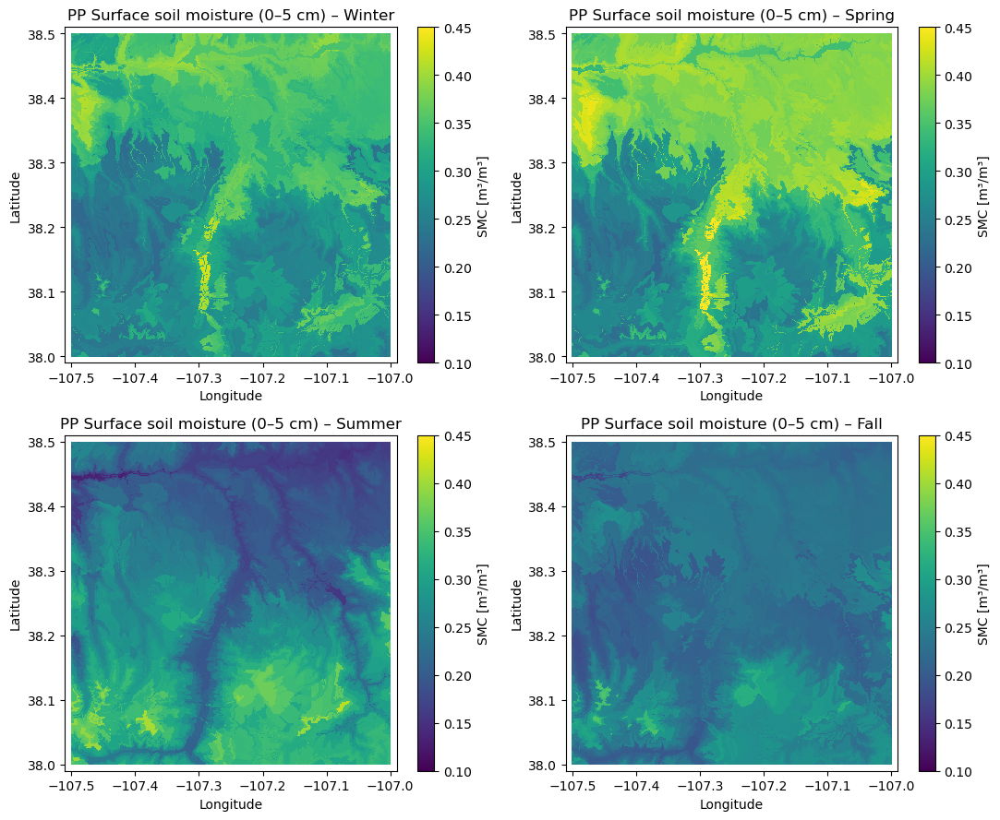

In [ ]:
# Soil moisture (smc) seasonal plots — TOP LAYER — PP — all CIDs

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/"
print(path)

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

buffer = 0

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:np.size(coord_xx0)-buffer]
coords_y = coord_yy0[buffer:np.size(coord_yy0)-buffer]

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

cid_list = [1, 2, 3, 4]

vmin = 0.10
vmax = 0.45

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        smc = np.array(fp.groups["data"].variables["smc"][:])
        fp.close()

        data = smc[:, :, 0]

        times_index = times.dt.month.isin(my_months)

        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        final_map = place_data(final_map, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_test025_old_zoomed_border.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_smc_surface_seasonal_PP_test025_unflipped_auto_scale.png


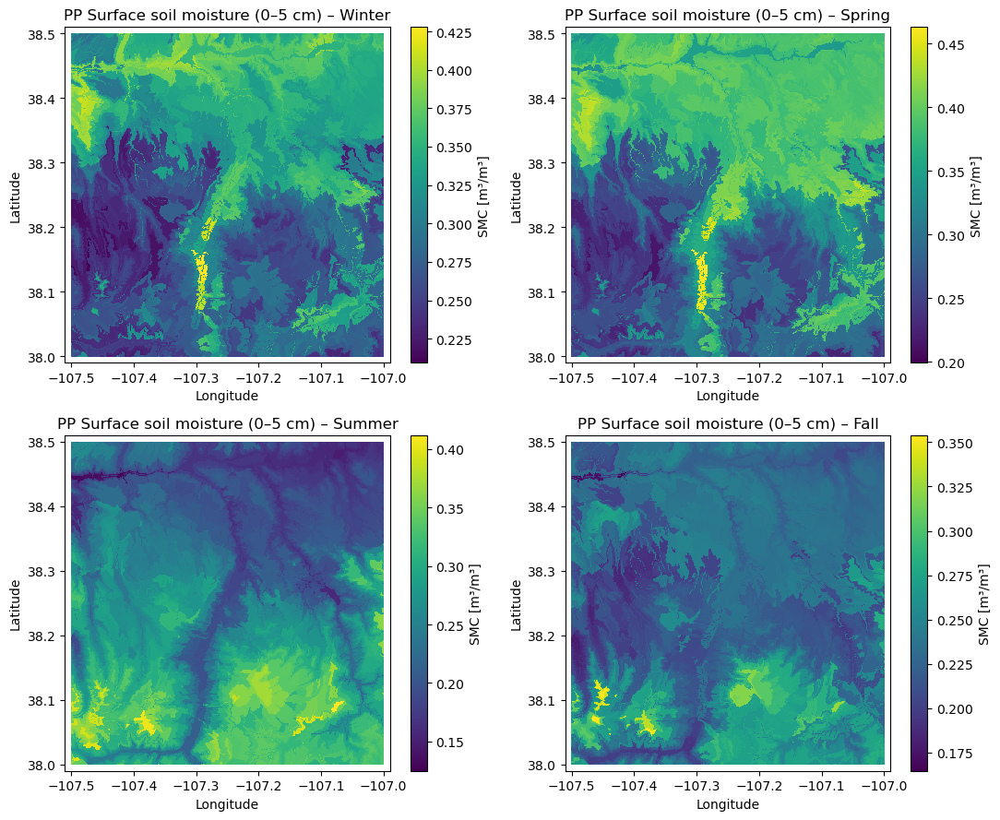

In [ ]:
# Soil moisture (smc) seasonal plots — TOP LAYER — PP — all CIDs
# Color scale is automatic for each season

import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/"
print(path)

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]
cid_list = [1, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        smc = np.array(fp.groups["data"].variables["smc"][:])
        fp.close()

        data = smc[:, :, 0]  # top soil layer: 0–5 cm

        times_index = times.dt.month.isin(my_months)
        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        final_map = place_data(final_map, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto"
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_test025_unflipped_auto_scale.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/
Plotting dem
Plotting slope
Plotting y_aspect
Plotting x_aspect
Plotting svf
Plotting tvf
Plotting hor_n
Plotting hor_w
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_terrain_test025_old_all_cids.png


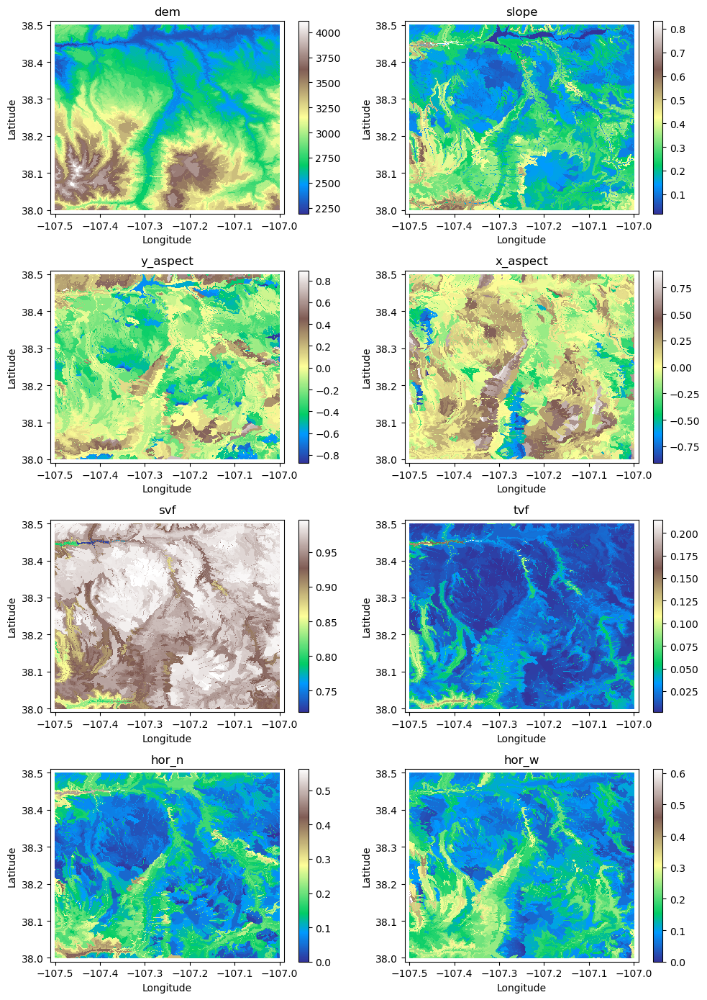

In [ ]:
# Output path
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

# Simulation path
path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/"

print(path)

# Read HRU and CID maps
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

# Coordinate axes
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0
coords_y = coord_yy0

# Function to place HRU data on raster grid
def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

# Variables to plot
var2plot = [
    "dem", "slope",
    "y_aspect", "x_aspect",
    "svf", "tvf",
    "hor_n", "hor_w"
]

cid_list = [1, 2, 3, 4]

# Plot
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"Plotting {var}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"{c}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)

        grp = fp.groups["parameters"]
        data = np.array(grp.variables[var][:])

        fp.close()

        final_map = place_data(final_map, data, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    # Valid-data extent with small no-data border
    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="terrain",
        shading="auto"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax)

plt.tight_layout()

outfile = os.path.join(outputdir, "res_terrain_test025_old_all_cids.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

Plotting Winter: swdown
Plotting Winter: lwdown
Plotting Winter: tair
Plotting Winter: precip
Plotting Winter: psurf
Plotting Winter: spfh
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_forcing_winter_test025__unflipped_all_cids.png


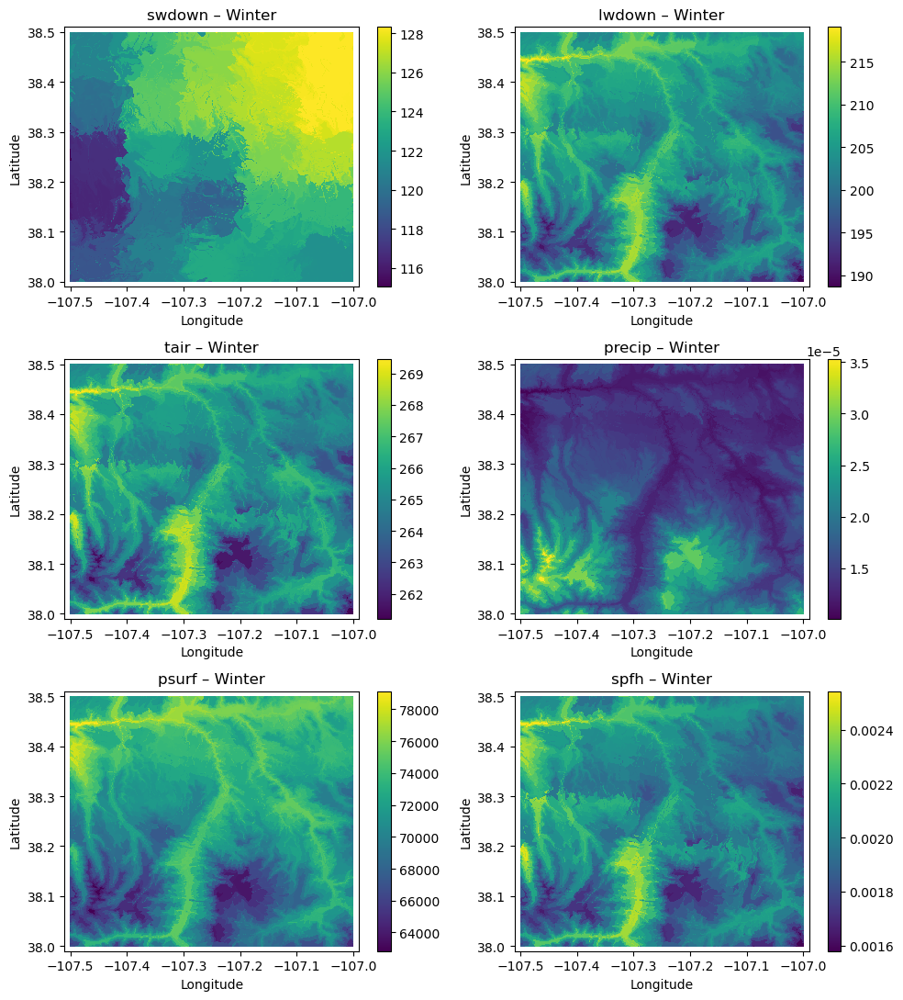

In [ ]:
# Plot meteorological forcing — seasonal average

var2plot = ["swdown", "lwdown", "tair", "precip", "psurf", "spfh"]

season_name = "Winter"
season_months = [12, 1, 2]

cid_list = [1, 2, 3, 4]

times_index = times.dt.month.isin(season_months)

fig, axes = plt.subplots(3, 2, figsize=(10, 11))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"Plotting {season_name}: {var}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"{c}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        data = np.array(fp.groups["meteorology"].variables[var][:])
        fp.close()

        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        final_map = place_data(final_map, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto"
    )

    ax.set_title(f"{var} – {season_name}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax)

plt.tight_layout()

outfile = os.path.join(outputdir, f"res_forcing_{season_name.lower()}_test025__unflipped_all_cids.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

In [ ]:
fp = nc.Dataset(path + "output_data/1/2014-01-01.nc")

print(fp.groups["data"].variables["smc"])

smc = np.array(fp.groups["data"].variables["smc"][:])

print("shape =", smc.shape)
print("min =", np.nanmin(smc))
print("max =", np.nanmax(smc))

fp.close()

<class 'netCDF4._netCDF4.Variable'>
float32 smc(time, hru, soil)
    _FillValue: 10000000000.0
    least_significant_digit: 3
    description: Soil water content
    units: m3/m3
path = /data
unlimited dimensions: 
current shape = (32120, 200, 10)
filling on
shape = (32120, 200, 10)
min = 0.04296875
max = 0.5546875


In [ ]:
import netCDF4 as nc
import os

path_pp = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped"

def list_nc_vars(path):
    print(f"\n{'='*80}")
    print(f"FILE: {path}")
    print(f"{'='*80}")

    if not os.path.exists(path):
        print("FILE NOT FOUND")
        return

    with nc.Dataset(path) as ds:

        if len(ds.variables) > 0:
            print("\nRoot variables:")
            for vname, var in ds.variables.items():
                print(f"  {vname:25s} shape={var.shape} dims={var.dimensions}")

        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(f"  {vname:25s} shape={var.shape} dims={var.dimensions}")

for cid in range(1, 5):

    input_file = os.path.join(path_pp, f"{cid}/input_file.nc")
    output_file = os.path.join(path_pp, f"output_data/{cid}/2014-01-01.nc")

    print(f"\n\n########## CID {cid} ##########")

    list_nc_vars(input_file)
    list_nc_vars(output_file)



########## CID 1 ##########

FILE: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/1/input_file.nc

[Group: meteorology]
  lwdown                    shape=(32120, 200) dims=('time', 'hru')
  swdown                    shape=(32120, 200) dims=('time', 'hru')
  tair                      shape=(32120, 200) dims=('time', 'hru')
  precip                    shape=(32120, 200) dims=('time', 'hru')
  psurf                     shape=(32120, 200) dims=('time', 'hru')
  wind                      shape=(32120, 200) dims=('time', 'hru')
  spfh                      shape=(32120, 200) dims=('time', 'hru')
  time                      shape=(32120,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                      shape=(4,) dims=('connections_columns',)
  indices                   shape=(4,) dims=('connections_columns',)
  indptr                    shape=(3,) dims=('co

Reading CID 1
Reading CID 2
Reading CID 3
Reading CID 4
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/scatter_tair_vs_elevation_seasonal.png


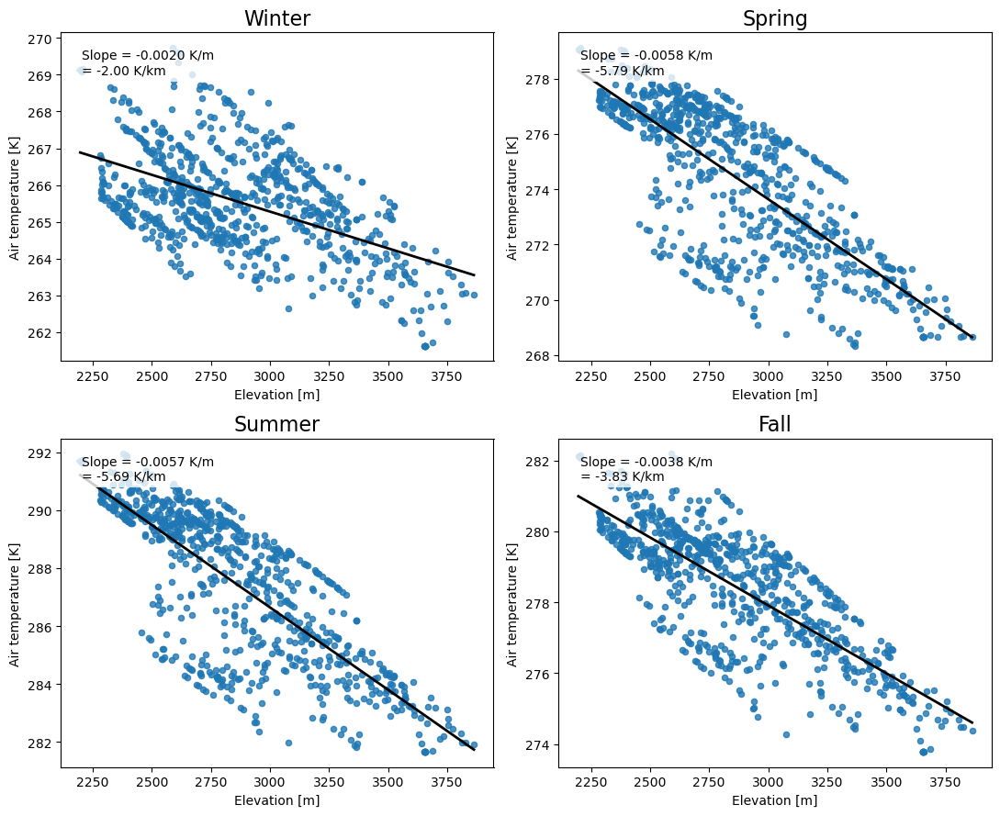

In [ ]:
# Scatter plot: Elevation vs Air Temperature — seasonal averages

import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/"

cid_list = [1, 2, 3, 4]

# --------------------------------------------------
# Time axis
# --------------------------------------------------
fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# --------------------------------------------------
# Seasons
# --------------------------------------------------
seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall": [9, 10, 11],
}

# --------------------------------------------------
# Read elevation and air temperature from all CIDs
# --------------------------------------------------
all_elev = []
all_tair = {s: [] for s in seasons}

for c in cid_list:

    print(f"Reading CID {c}")

    # Elevation from input file
    fp_in = nc.Dataset(path + f"{c}/input_file.nc")
    elev = np.array(fp_in.groups["parameters"].variables["dem"][:])
    tair = np.array(fp_in.groups["meteorology"].variables["tair"][:])  # time, hru
    fp_in.close()

    all_elev.append(elev)

    for s in seasons:
        idx = times.dt.month.isin(season_months[s])
        tair_season = np.nanmean(tair[idx, :], axis=0)
        all_tair[s].append(tair_season)

elev_all = np.concatenate(all_elev)

for s in seasons:
    all_tair[s] = np.concatenate(all_tair[s])

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for i, s in enumerate(seasons):

    ax = axes[i]
    y = all_tair[s]

    good = np.isfinite(elev_all) & np.isfinite(y)

    ax.scatter(
        elev_all[good],
        y[good],
        s=20,
        alpha=0.8
    )

    # Linear trend line
    if np.sum(good) > 2:
        m, b = np.polyfit(elev_all[good], y[good], 1)
        xfit = np.linspace(np.nanmin(elev_all[good]), np.nanmax(elev_all[good]), 100)
        yfit = m * xfit + b
        ax.plot(xfit, yfit, color="black", linewidth=2)

        ax.text(
            0.05, 0.95,
            f"Slope = {m:.4f} K/m\n= {m*1000:.2f} K/km",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
        )

    ax.set_title(s, fontsize=16)
    ax.set_xlabel("Elevation [m]")
    ax.set_ylabel("Air temperature [K]")

plt.tight_layout()

outfile = os.path.join(outputdir, "scatter_tair_vs_elevation_seasonal.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

In [ ]:
import os
import netCDF4 as nc
import numpy as np

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3months"

bad = []

for cid in range(1, 1601):
    fname = f"{base}/{cid}/input_file.nc"

    if not os.path.exists(fname):
        bad.append((cid, "missing input_file.nc"))
        continue

    f = nc.Dataset(fname)

    for g in f.groups:
        if "wmatrix_Basin" in g:
            idx = f.groups[g]["indices"][:]
            ptr = f.groups[g]["indptr"][:]

            max_index = int(np.max(idx))
            nrows = len(ptr) - 1

            if max_index + 1 != nrows:
                bad.append((cid, g, max_index, nrows))

    f.close()

print("Bad count:", len(bad))
for x in bad[:100]:
    print(x)

Bad count: 1
(1127, 'wmatrix_Basin2', 0, 2)


In [ ]:
import os
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3months"

bad = []

for cid in range(1,1601):
    f = f"{base}/{cid}/input_file.nc"
    if not os.path.exists(f):
        bad.append((cid, "missing"))
        continue

    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    ds.close()

    if nhru != 200:
        bad.append((cid, nhru))

print("CIDs not 200:", len(bad))
print(bad[:100])

CIDs not 200: 4
[(286, 189), (414, 190), (1087, 190), (1496, 186)]


In [ ]:
import os
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1year"

bad = []

for cid in range(1,1601):
    f = f"{base}/{cid}/input_file.nc"
    if not os.path.exists(f):
        bad.append((cid, "missing"))
        continue

    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    ds.close()

    if nhru != 200:
        bad.append((cid, nhru))

print("CIDs not 200:", len(bad))
print(bad[:100])

CIDs not 200: 4
[(286, 189), (414, 190), (1087, 190), (1496, 186)]


In [ ]:
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_3months"

for cid in [274,414,1087,1496]:
    f = f"{base}/{cid}/input_file.nc"
    ds = nc.Dataset(f)
    print(cid, len(ds.dimensions["hru"]), ds.groups["meteorology"].variables["lwdown"].shape)
    ds.close()

274 200 (696, 200)
414 190 (696, 190)
1087 190 (696, 190)
1496 186 (696, 186)


In [ ]:
import netCDF4 as nc
import os

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1year"

for cid in [274,414,1087,1496]:

    f = os.path.join(base, str(cid), "input_file.nc")

    ds = nc.Dataset(f)

    nhru = len(ds.dimensions["hru"])

    print(cid, "HRUs =", nhru)

    ds.close()

274 HRUs = 200
414 HRUs = 190
1087 HRUs = 190
1496 HRUs = 186


In [ ]:
import os
import rasterio
import numpy as np

rdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado"
cids = [274, 286, 414, 1087, 1496]

files = [
    "mask_latlon.tif",
    "dem_latlon.tif",
    "fdir_latlon.tif",
    "acc_latlon.tif",
    "lc_latlon.tif",
    "f11_latlon.tif",
    "clay/clay_latlon_2.5cm.tif",
    "sand/sand_latlon_2.5cm.tif",
]

for cid in cids:
    print("\n" + "="*60)
    print("CID", cid)
    folder = f"{rdir}/data/cids/{cid}"

    for fname in files:
        f = f"{folder}/{fname}"

        if not os.path.exists(f):
            print(fname, "MISSING")
            continue

        with rasterio.open(f) as src:
            arr = src.read(1)
            nodata = src.nodata

        if nodata is None:
            valid = np.isfinite(arr)
        else:
            valid = (arr != nodata) & np.isfinite(arr)

        print(
            fname,
            "shape=", arr.shape,
            "valid=", int(valid.sum()),
            "nan=", int(np.isnan(arr).sum()),
            "min=", np.nanmin(arr[valid]) if valid.any() else None,
            "max=", np.nanmax(arr[valid]) if valid.any() else None,
            "unique=", len(np.unique(arr[valid])) if valid.any() else 0
        )


CID 274
mask_latlon.tif shape= (901, 901) valid= 799007 nan= 0 min= 233.0 max= 355.0 unique= 12
dem_latlon.tif shape= (901, 901) valid= 811801 nan= 0 min= 1699.4 max= 3976.1 unique= 20840
fdir_latlon.tif shape= (901, 901) valid= 811801 nan= 0 min= 1.0 max= 128.0 unique= 8
acc_latlon.tif shape= (901, 901) valid= 811801 nan= 0 min= 0.006939337 max= 1798.1592 unique= 170728
lc_latlon.tif shape= (901, 901) valid= 811801 nan= 0 min= 2.0 max= 17.0 unique= 10
f11_latlon.tif shape= (901, 901) valid= 0 nan= 0 min= None max= None unique= 0
clay/clay_latlon_2.5cm.tif shape= (901, 901) valid= 811801 nan= 0 min= 2.728204 max= 62.65412 unique= 741962
sand/sand_latlon_2.5cm.tif shape= (901, 901) valid= 811801 nan= 0 min= 6.441897 max= 85.423065 unique= 736062

CID 286
mask_latlon.tif shape= (901, 901) valid= 807280 nan= 0 min= 245.0 max= 367.0 unique= 11
dem_latlon.tif shape= (901, 901) valid= 811801 nan= 0 min= 519.3 max= 2326.8 unique= 14540
fdir_latlon.tif shape= (901, 901) valid= 811801 nan= 0 m

In [ ]:
import os
import rasterio
import numpy as np

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1year"

for cid in [274, 286, 414, 1087, 1496]:
    print("\nCID", cid)

    for name in ["hru_mapping_latlon.tif", "hband_latlon.tif", "basins_latlon.tif", "basin_clusters_latlon.tif"]:
        f = f"{base}/{cid}/{name}"

        if not os.path.exists(f):
            print(name, "MISSING")
            continue

        with rasterio.open(f) as src:
            arr = src.read(1)
            nodata = src.nodata

        valid = arr[arr != nodata]
        valid = valid[valid != -9999]

        print(name, "unique valid =", len(np.unique(valid)), "min/max =", np.min(valid), np.max(valid))


CID 274
hru_mapping_latlon.tif unique valid = 200 min/max = 0.0 199.0
hband_latlon.tif unique valid = 20 min/max = 0.0 19.0
basins_latlon.tif unique valid = 287 min/max = 1.0 287.0
basin_clusters_latlon.tif unique valid = 10 min/max = 1.0 10.0

CID 286
hru_mapping_latlon.tif unique valid = 189 min/max = 0.0 188.0
hband_latlon.tif unique valid = 20 min/max = 0.0 19.0
basins_latlon.tif unique valid = 361 min/max = 1.0 361.0
basin_clusters_latlon.tif unique valid = 10 min/max = 1.0 10.0

CID 414
hru_mapping_latlon.tif unique valid = 190 min/max = 0.0 189.0
hband_latlon.tif unique valid = 20 min/max = 0.0 19.0
basins_latlon.tif unique valid = 304 min/max = 1.0 304.0
basin_clusters_latlon.tif unique valid = 10 min/max = 1.0 10.0

CID 1087
hru_mapping_latlon.tif unique valid = 190 min/max = 0.0 189.0
hband_latlon.tif unique valid = 19 min/max = 0.0 18.0
basins_latlon.tif unique valid = 271 min/max = 1.0 271.0
basin_clusters_latlon.tif unique valid = 10 min/max = 1.0 10.0

CID 1496
hru_mappi

In [ ]:
import netCDF4 as nc
import numpy as np

for cid in [274, 286, 414, 1087, 1496]:
    f = f"{base}/{cid}/input_file.nc"

    ds = nc.Dataset(f)

    hband = ds.groups["parameters"].variables["hband"][:]

    print(
        cid,
        "HRUs =", len(hband),
        "Bands =", len(np.unique(hband))
    )

    ds.close()

274 HRUs = 200 Bands = 20
286 HRUs = 189 Bands = 20
414 HRUs = 190 Bands = 20
1087 HRUs = 190 Bands = 19
1496 HRUs = 186 Bands = 20


In [ ]:
from collections import Counter

for cid in [274,286,414,1087,1496]:

    ds = nc.Dataset(f"{base}/{cid}/input_file.nc")

    hband = ds.groups["parameters"].variables["hband"][:]

    print("\nCID", cid)

    for band,count in sorted(Counter(hband).items()):
        print(band, count)

    ds.close()


CID 274
0.0 2
1.0 18
2.0 1
3.0 19
4.0 2
5.0 18
6.0 2
7.0 18
8.0 1
9.0 19
10.0 1
11.0 19
12.0 2
13.0 18
14.0 1
15.0 19
16.0 2
17.0 18
18.0 2
19.0 18

CID 286
0.0 2
1.0 18
2.0 3
3.0 6
4.0 3
5.0 17
6.0 2
7.0 18
8.0 2
9.0 18
10.0 2
11.0 18
12.0 2
13.0 18
14.0 2
15.0 18
16.0 2
17.0 18
18.0 2
19.0 18

CID 414
0.0 2
1.0 8
2.0 1
3.0 19
4.0 2
5.0 18
6.0 2
7.0 18
8.0 2
9.0 18
10.0 2
11.0 18
12.0 2
13.0 18
14.0 1
15.0 19
16.0 2
17.0 18
18.0 1
19.0 19

CID 1087
0.0 18
1.0 2
2.0 10
3.0 14
4.0 6
5.0 3
6.0 17
7.0 2
8.0 18
9.0 2
10.0 18
11.0 19
12.0 1
13.0 19
14.0 1
15.0 2
16.0 18
17.0 19
18.0 1

CID 1496
0.0 3
1.0 3
2.0 1
3.0 19
4.0 2
5.0 18
6.0 1
7.0 19
8.0 2
9.0 18
10.0 1
11.0 19
12.0 1
13.0 19
14.0 1
15.0 19
16.0 2
17.0 18
18.0 2
19.0 18


In [ ]:
import netCDF4 as nc
import numpy as np
from collections import Counter

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1year"

for cid in [274, 286, 414, 1087, 1496]:
    f = f"{base}/{cid}/input_file.nc"
    ds = nc.Dataset(f)

    hru = ds.groups["parameters"].variables["hru"][:]
    hband = ds.groups["parameters"].variables["hband"][:]

    print("\nCID", cid)
    print("Total HRUs:", len(hru))
    print("Unique hbands:", len(np.unique(hband)))
    print("HRUs per hband:")

    for band, count in sorted(Counter(hband).items()):
        print(f"  hband {band}: {count}")

    ds.close()


CID 274
Total HRUs: 200
Unique hbands: 20
HRUs per hband:
  hband 0.0: 2
  hband 1.0: 18
  hband 2.0: 1
  hband 3.0: 19
  hband 4.0: 2
  hband 5.0: 18
  hband 6.0: 2
  hband 7.0: 18
  hband 8.0: 1
  hband 9.0: 19
  hband 10.0: 1
  hband 11.0: 19
  hband 12.0: 2
  hband 13.0: 18
  hband 14.0: 1
  hband 15.0: 19
  hband 16.0: 2
  hband 17.0: 18
  hband 18.0: 2
  hband 19.0: 18

CID 286
Total HRUs: 189
Unique hbands: 20
HRUs per hband:
  hband 0.0: 2
  hband 1.0: 18
  hband 2.0: 3
  hband 3.0: 6
  hband 4.0: 3
  hband 5.0: 17
  hband 6.0: 2
  hband 7.0: 18
  hband 8.0: 2
  hband 9.0: 18
  hband 10.0: 2
  hband 11.0: 18
  hband 12.0: 2
  hband 13.0: 18
  hband 14.0: 2
  hband 15.0: 18
  hband 16.0: 2
  hband 17.0: 18
  hband 18.0: 2
  hband 19.0: 18

CID 414
Total HRUs: 190
Unique hbands: 20
HRUs per hband:
  hband 0.0: 2
  hband 1.0: 8
  hband 2.0: 1
  hband 3.0: 19
  hband 4.0: 2
  hband 5.0: 18
  hband 6.0: 2
  hband 7.0: 18
  hband 8.0: 2
  hband 9.0: 18
  hband 10.0: 2
  hband 11.0: 

In [ ]:
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1year"


for cid in [286, 414, 1087, 1496]:
    f = f"{base}/{cid}/input_file.nc"
    ds = nc.Dataset(f)
    print(
        cid,
        "hru_dim", len(ds.dimensions["hru"]),
        "lwdown", ds.groups["meteorology"].variables["lwdown"].shape,
        "swdown", ds.groups["meteorology"].variables["swdown"].shape
    )
    ds.close()

286 hru_dim 189 lwdown (2896, 189) swdown (2896, 189)
414 hru_dim 190 lwdown (2896, 190) swdown (2896, 190)
1087 hru_dim 190 lwdown (2896, 190) swdown (2896, 190)
1496 hru_dim 186 lwdown (2896, 186) swdown (2896, 186)


In [ ]:
import os
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_2hru_test"

bad = []

for cid in range(1,1601):
    f = f"{base}/{cid}/input_file.nc"
    if not os.path.exists(f):
        bad.append((cid, "missing"))
        continue

    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    ds.close()

    if nhru != 2:
        bad.append((cid, nhru))

print("CIDs not 2:", len(bad))
print(bad[:100])

CIDs not 200: 0
[]


In [ ]:
import os
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_100bh_test"

bad = []

for cid in range(1,1601):
    f = f"{base}/{cid}/input_file.nc"
    if not os.path.exists(f):
        bad.append((cid, "missing"))
        continue

    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    ds.close()

    if nhru != 200:
        bad.append((cid, nhru))

print("CIDs not 200:", len(bad))
print(bad[:100])

CIDs not 200: 4
[(286, 189), (414, 190), (1087, 190), (1496, 186)]


In [ ]:
import rasterio
import numpy as np
import os

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids"

for cid in [286, 414, 1087, 1496]:
    demfile = f"{base}/{cid}/dem_latlon.tif"

    if not os.path.exists(demfile):
        print(cid, "DEM not found")
        continue

    with rasterio.open(demfile) as src:
        dem = src.read(1)

    dem = dem[np.isfinite(dem)]

    print(
        f"CID {cid:4d} | "
        f"min={dem.min():7.1f} m | "
        f"max={dem.max():7.1f} m | "
        f"range={dem.max()-dem.min():7.1f} m"
    )

CID  286 | min=  519.3 m | max= 2326.8 m | range= 1807.5 m
CID  414 | min= 1314.2 m | max= 2488.4 m | range= 1174.2 m
CID 1087 | min= 1281.1 m | max= 3135.6 m | range= 1854.5 m
CID 1496 | min= 1942.4 m | max= 3648.6 m | range= 1706.2 m


In [ ]:
import rasterio
import numpy as np
import os
import netCDF4 as nc

base_dem = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids"
base_exp = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_100bh_test"

found = []

for cid in range(1,1601):

    f = f"{base_exp}/{cid}/input_file.nc"
    if not os.path.exists(f):
        continue

    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    ds.close()

    if nhru == 200:
        found.append(cid)

    if len(found) == 5:
        break

print(found)

[1, 2, 3, 4, 5]


In [ ]:
for cid in found:

    demfile = f"{base_dem}/{cid}/dem_latlon.tif"

    with rasterio.open(demfile) as src:
        dem = src.read(1)

    dem = dem[np.isfinite(dem)]

    print(
        f"CID {cid:4d} | "
        f"min={dem.min():7.1f} | "
        f"max={dem.max():7.1f} | "
        f"range={dem.max()-dem.min():7.1f}"
    )

CID    1 | min=  108.7 | max= 1548.1 | range= 1439.4
CID    2 | min=  166.8 | max= 1722.6 | range= 1555.8
CID    3 | min=  243.3 | max= 1722.6 | range= 1479.3
CID    4 | min=  358.9 | max= 1980.5 | range= 1621.6
CID    5 | min=  476.6 | max= 2158.5 | range= 1681.9


In [ ]:
for cid in [286,414,1087,1496]:
    ds = nc.Dataset(f"{base_exp}/{cid}/input_file.nc")
    print(cid, len(ds.groups))
    print(ds.groups.keys())
    ds.close()

286 15
dict_keys(['meteorology', 'water_use', 'metadata', 'wmatrix_Basin1', 'wmatrix_Basin2', 'wmatrix_Basin3', 'wmatrix_Basin4', 'wmatrix_Basin5', 'wmatrix_Basin6', 'wmatrix_Basin7', 'wmatrix_Basin8', 'wmatrix_Basin9', 'wmatrix_Basin10', 'parameters', 'stream_network'])
414 15
dict_keys(['meteorology', 'water_use', 'metadata', 'wmatrix_Basin1', 'wmatrix_Basin2', 'wmatrix_Basin3', 'wmatrix_Basin4', 'wmatrix_Basin5', 'wmatrix_Basin6', 'wmatrix_Basin7', 'wmatrix_Basin8', 'wmatrix_Basin9', 'wmatrix_Basin10', 'parameters', 'stream_network'])
1087 15
dict_keys(['meteorology', 'water_use', 'metadata', 'wmatrix_Basin1', 'wmatrix_Basin2', 'wmatrix_Basin3', 'wmatrix_Basin4', 'wmatrix_Basin5', 'wmatrix_Basin6', 'wmatrix_Basin7', 'wmatrix_Basin8', 'wmatrix_Basin9', 'wmatrix_Basin10', 'parameters', 'stream_network'])
1496 15
dict_keys(['meteorology', 'water_use', 'metadata', 'wmatrix_Basin1', 'wmatrix_Basin2', 'wmatrix_Basin3', 'wmatrix_Basin4', 'wmatrix_Basin5', 'wmatrix_Basin6', 'wmatrix_Basin7'

In [ ]:
import netCDF4 as nc
import numpy as np

base_exp = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_100bh_test"

for cid in [1,286]:

    print("\nCID", cid)

    ds = nc.Dataset(f"{base_exp}/{cid}/input_file.nc")

    for b in range(1,11):

        g = ds.groups[f"wmatrix_Basin{b}"]

        data    = g.variables["data"][:]
        indices = g.variables["indices"][:]
        indptr  = g.variables["indptr"][:]

        nrow_indptr  = len(indptr)-1
        nrow_indices = int(np.max(indices))+1 if len(indices)>0 else 0

        print(
            f"Basin{b:2d}: "
            f"data={len(data):4d} "
            f"indices={len(indices):4d} "
            f"indptr={len(indptr):4d} "
            f"rows(indptr)={nrow_indptr:4d} "
            f"rows(indices)={nrow_indices:4d}"
        )

    ds.close()


CID 1
Basin 1: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 2: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 3: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 4: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 5: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 6: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 7: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 8: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 9: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin10: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2

CID 286
Basin 1: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 2: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2
Basin 3: dat

In [ ]:
import netCDF4 as nc
import numpy as np

base_exp = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_100bh_test"

cid = 1127
ds = nc.Dataset(f"{base_exp}/{cid}/input_file.nc")

print("\nCID", cid)

for b in range(1, 11):
    g = ds.groups[f"wmatrix_Basin{b}"]

    data = g.variables["data"][:]
    indices = g.variables["indices"][:]
    indptr = g.variables["indptr"][:]

    nrow_indptr = len(indptr) - 1
    nrow_indices = int(np.max(indices)) + 1 if len(indices) > 0 else 0

    status = "OK" if nrow_indptr == nrow_indices else "BAD"

    print(
        f"Basin{b:2d}: "
        f"data={len(data):4d} "
        f"indices={len(indices):4d} "
        f"indptr={len(indptr):4d} "
        f"rows(indptr)={nrow_indptr:4d} "
        f"rows(indices)={nrow_indices:4d} "
        f"{status}"
    )

ds.close()


CID 1127
Basin 1: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 2: data=   1 indices=   1 indptr=   3 rows(indptr)=   2 rows(indices)=   1 BAD
Basin 3: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 4: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 5: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 6: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 7: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 8: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 9: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin10: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK


In [ ]:
import netCDF4 as nc
import numpy as np

base_exp = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_100bh_test"

for cid in [1, 1127]:
    f = f"{base_exp}/{cid}/input_file.nc"
    ds = nc.Dataset(f)

    hband = ds.groups["parameters"].variables["hband"][:]
    area = ds.groups["parameters"].variables["area"][:]
    hand = ds.groups["parameters"].variables["hand"][:]

    print("\nCID", cid)
    print("NHRU:", len(ds.dimensions["hru"]))
    print("unique hbands:", len(np.unique(hband)))

    for hb in np.unique(hband):
        m = hband == hb
        print(
            "hband", int(hb),
            "count", int(np.sum(m)),
            "area", float(np.sum(area[m])),
            "hand_min", float(np.min(hand[m])),
            "hand_max", float(np.max(hand[m]))
        )

    g = ds.groups["wmatrix_Basin2"]
    print("Basin2 data:", g.variables["data"][:])
    print("Basin2 indices:", g.variables["indices"][:])
    print("Basin2 indptr:", g.variables["indptr"][:])

    ds.close()


CID 1
NHRU: 200
unique hbands: 20
hband 0 count 2 area 574328.75 hand_min 0.0 hand_max 0.0
hband 1 count 18 area 15825595.0 hand_min 1.317192792892456 hand_max 1.3171932697296143
hband 2 count 2 area 138349.765625 hand_min 0.0 hand_max 0.0
hband 3 count 18 area 32732616.0 hand_min 0.4486262798309326 hand_max 0.44862642884254456
hband 4 count 2 area 160244.125 hand_min 0.0 hand_max 0.0
hband 5 count 18 area 51877160.0 hand_min 0.41110578179359436 hand_max 0.41110581159591675
hband 6 count 2 area 262498.4375 hand_min 0.0 hand_max 0.0
hband 7 count 18 area 67954360.0 hand_min 0.45052090287208557 hand_max 0.4505210220813751
hband 8 count 2 area 457554.5625 hand_min 0.0 hand_max 0.0
hband 9 count 18 area 74807144.0 hand_min 0.5157293081283569 hand_max 0.5157294273376465
hband 10 count 2 area 427781.5 hand_min 0.0 hand_max 0.0
hband 11 count 18 area 119435320.0 hand_min 0.4109768867492676 hand_max 0.41097700595855713
hband 12 count 5 area 412573.9375 hand_min 0.0 hand_max 0.0
hband 13 count

In [ ]:
import netCDF4 as nc
import numpy as np

base_exp = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_500bh_test"

cid = 1127
ds = nc.Dataset(f"{base_exp}/{cid}/input_file.nc")

print("\nCID", cid)

for b in range(1, 11):
    g = ds.groups[f"wmatrix_Basin{b}"]

    data = g.variables["data"][:]
    indices = g.variables["indices"][:]
    indptr = g.variables["indptr"][:]

    nrow_indptr = len(indptr) - 1
    nrow_indices = int(np.max(indices)) + 1 if len(indices) > 0 else 0

    status = "OK" if nrow_indptr == nrow_indices else "BAD"

    print(
        f"Basin{b:2d}: "
        f"data={len(data):4d} "
        f"indices={len(indices):4d} "
        f"indptr={len(indptr):4d} "
        f"rows(indptr)={nrow_indptr:4d} "
        f"rows(indices)={nrow_indices:4d} "
        f"{status}"
    )

ds.close()


CID 1127
Basin 1: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 2: data=   1 indices=   1 indptr=   3 rows(indptr)=   2 rows(indices)=   1 BAD
Basin 3: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 4: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 5: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 6: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 7: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 8: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 9: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin10: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK


In [ ]:
import os

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_500bh_test/1127"

for f in sorted(os.listdir(base)):
    if "basin" in f.lower() or "hband" in f.lower() or "hru" in f.lower():
        print(f)

basin_clusters_latlon.tif
basins_latlon.tif
hband_latlon.tif
hru_mapping_latlon.tif


In [ ]:
import rasterio
import numpy as np

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_500bh_test/1127"

with rasterio.open(f"{base}/basin_clusters_latlon.tif") as src:
    basin_clusters = src.read(1)

with rasterio.open(f"{base}/hband_latlon.tif") as src:
    hband = src.read(1)

with rasterio.open(f"{base}/hru_mapping_latlon.tif") as src:
    hru = src.read(1)

m = basin_clusters == 2

print("Basin cluster 2 pixels:", np.sum(m))

print("\nHeight bands inside Basin 2")
for hb in np.unique(hband[m]):
    if hb < 0:
        continue
    mm = m & (hband == hb)

    print(
        f"hband={int(hb):2d}",
        f"pixels={np.sum(mm):6d}",
        f"HRUs={len(np.unique(hru[mm])):4d}"
    )

Basin cluster 2 pixels: 15282

Height bands inside Basin 2
hband= 2 pixels= 15274 HRUs=  19
hband= 3 pixels=     8 HRUs=   1


In [ ]:
import os
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_1yr_200hru_500bh_test"


for cid in [286, 414, 1087, 1496]:
    f = f"{base}/{cid}/input_file.nc"
    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    meteo = ds.groups["meteorology"].variables["lwdown"].shape[1]
    print(cid, "hru_dim", nhru, "lwdown_dim", meteo)
    ds.close()

286 hru_dim 189 lwdown_dim 189
414 hru_dim 190 lwdown_dim 190
1087 hru_dim 190 lwdown_dim 190
1496 hru_dim 186 lwdown_dim 186


In [ ]:
import os
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_2hru_100bh_test"


for cid in [286, 414, 1087, 1496]:
    f = f"{base}/{cid}/input_file.nc"
    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    meteo = ds.groups["meteorology"].variables["lwdown"].shape[1]
    print(cid, "hru_dim", nhru, "lwdown_dim", meteo)
    ds.close()


286 hru_dim 2 lwdown_dim 2
414 hru_dim 2 lwdown_dim 2
1087 hru_dim 2 lwdown_dim 2
1496 hru_dim 2 lwdown_dim 2


In [ ]:
import os
import netCDF4 as nc
from collections import Counter

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_2hru_100bh_test"

counts = Counter()

for cid in range(1,1601):
    f = f"{base}/{cid}/input_file.nc"
    if not os.path.exists(f):
        continue

    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    counts[nhru] += 1
    ds.close()

print(counts)

Counter({2: 1600})


In [ ]:
import netCDF4 as nc
import numpy as np

base_exp = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"

cid = 1127
ds = nc.Dataset(f"{base_exp}/{cid}/input_file.nc")

print("\nCID", cid)

for b in range(1, 6):
    g = ds.groups[f"wmatrix_Basin{b}"]

    data = g.variables["data"][:]
    indices = g.variables["indices"][:]
    indptr = g.variables["indptr"][:]

    nrow_indptr = len(indptr) - 1
    nrow_indices = int(np.max(indices)) + 1 if len(indices) > 0 else 0

    status = "OK" if nrow_indptr == nrow_indices else "BAD"

    print(
        f"Basin{b:2d}: "
        f"data={len(data):4d} "
        f"indices={len(indices):4d} "
        f"indptr={len(indptr):4d} "
        f"rows(indptr)={nrow_indptr:4d} "
        f"rows(indices)={nrow_indices:4d} "
        f"{status}"
    )

ds.close()


CID 1127
Basin 1: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 2: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 3: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 4: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK
Basin 5: data=   4 indices=   4 indptr=   3 rows(indptr)=   2 rows(indices)=   2 OK


In [ ]:
import os
import netCDF4 as nc

base = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"


for cid in [286, 414, 1087, 1496]:
    f = f"{base}/{cid}/input_file.nc"
    ds = nc.Dataset(f)
    nhru = len(ds.dimensions["hru"])
    meteo = ds.groups["meteorology"].variables["lwdown"].shape[1]
    print(cid, "hru_dim", nhru, "lwdown_dim", meteo)
    ds.close()

286 hru_dim 100 lwdown_dim 100
414 hru_dim 100 lwdown_dim 100
1087 hru_dim 100 lwdown_dim 100
1496 hru_dim 100 lwdown_dim 100


In [ ]:
import sys
import numpy as np

print(sys.executable)
print(np.__version__)

/projects/battobrah@xsede.org/software/anaconda/envs/HB3/bin/python
1.21.6


In [ ]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]


# ============================================================
# READ RASTERS AND METADATA
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])


# ============================================================
# READ TIME
# ============================================================

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")


# ============================================================
# CREATE SEASON MASKS
# ============================================================

season_masks = []

for months in season_months:
    season_masks.append(times.dt.month.isin(months).values)


# ============================================================
# CREATE EMPTY MAPS FOR EACH SEASON
# ============================================================

season_maps = []

for _ in seasons:
    final_map = np.copy(hrus).astype(np.float64)
    final_map[:] = -9999.0
    season_maps.append(final_map)


# ============================================================
# READ EACH CID ONCE, COMPUTE ALL SEASONS, FILL MAPS
# ============================================================

global_min = np.inf
global_max = -np.inf

for c in cid_list:

    fp_path = path + f"output_data/{c}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}")
        continue

    fp = nc.Dataset(fp_path)

    # Read only top soil layer: 0–5 cm
    smc = np.array(fp.groups["data"].variables["smc"][:, :, 0])

    fp.close()

    for iss in range(len(seasons)):

        data_sel = smc[season_masks[iss], :]
        data_ave = np.nanmean(data_sel, axis=0).astype(np.float64)

        global_min = min(global_min, np.nanmin(data_ave))
        global_max = max(global_max, np.nanmax(data_ave))

        mask = (hrus != -9999) & (cids == int(c))
        season_maps[iss][mask] = data_ave[hrus[mask].astype(int)]

    if c % 100 == 0:
        print(f"Finished CID {c}")


print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max


# ============================================================
# PLOT SEASONAL MAPS WITH COMMON COLOR SCALE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]

    final_map = np.ma.masked_where(season_maps[iss] == -9999, season_maps[iss])

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "res_smc_surface_seasonal_PP_100hru_100bh_global_scale_fast_no_numba.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Finished CID 100
Finished CID 200
Finished CID 300
Finished CID 400
Finished CID 500
Finished CID 600
Finished CID 700
Finished CID 800
Finished CID 900
Finished CID 1000
Finished CID 1100
Finished CID 1200


: 

: 

In [ ]:
#Original

import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# Soil moisture (smc) seasonal plots — TOP LAYER — PP — all CIDs
# Publication version: common color scale calculated from the dataset

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

cid_list = range(1, 1601)

# ============================================================
# PASS 1: Calculate global min and max across all seasons/CIDs
# ============================================================

global_min = np.inf
global_max = -np.inf

for iss in range(len(seasons)):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Calculating range for {my_season}")

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        smc = np.array(fp.groups["data"].variables["smc"][:])
        fp.close()

        data = smc[:, :, 0]  # top soil layer: 0–5 cm

        times_index = times.dt.month.isin(my_months)
        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        global_min = min(global_min, np.nanmin(data_ave))
        global_max = max(global_max, np.nanmax(data_ave))

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# PASS 2: Plot seasonal maps using the common color scale
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        smc = np.array(fp.groups["data"].variables["smc"][:])
        fp.close()

        data = smc[:, :, 0]  # top soil layer: 0–5 cm

        times_index = times.dt.month.isin(my_months)
        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        #final_map = place_data(final_map, data_ave, hrus, cids, int(c))
        mask = (hrus != -9999) & (cids == int(c))
        final_map[mask] = data_ave[hrus[mask].astype(int)]
       
        if c % 100 == 0:
            print(f"  Finished CID {c}")

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "res_smc_surface_seasonal_PP_100hru_100bh_global_scale.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

In [ ]:
# ============================================================
# FSNO seasonal plots — PP — all CIDs
# Publication version: common color scale calculated from dataset
# ============================================================

# PASS 1: Calculate global min and max across all seasons/CIDs

global_min = np.inf
global_max = -np.inf

for iss in range(len(seasons)):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Calculating FSNO range for {my_season}")

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        fsno = np.array(fp.groups["data"].variables["fsno"][:])
        fp.close()

        data = fsno[:, :]

        times_index = times.dt.month.isin(my_months)
        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        global_min = min(global_min, np.nanmin(data_ave))
        global_max = max(global_max, np.nanmax(data_ave))

print("Global FSNO min:", global_min)
print("Global FSNO max:", global_max)

vmin = global_min
vmax = global_max

# PASS 2: Plot seasonal maps using common color scale

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating FSNO plot for {my_season}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        fsno = np.array(fp.groups["data"].variables["fsno"][:])
        fp.close()

        data = fsno[:, :]

        times_index = times.dt.month.isin(my_months)
        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        final_map = place_data(final_map, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="Blues",
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"PP Snow cover fraction – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="FSNO [-]")

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "res_fsno_seasonal_PP_100hru_100bh_global_scale.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

In [ ]:
import os
import time
import gc
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import rasterio

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# START DASK
# ============================================================

client = Client(
    n_workers=4,
    threads_per_worker=1,
    processes=True,
    memory_limit="7GB"
)
print(client)

# ============================================================
# READ STATIC MAPS
# ============================================================

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

with rasterio.open(hrus_file) as src:
    hrus = src.read(1).astype(np.float32)
    bounds = src.bounds
    nx = src.width
    ny = src.height

with rasterio.open(cids_file) as src:
    cids = src.read(1).astype(np.float32)

coords_x = np.linspace(bounds.left, bounds.right, nx)
coords_y = np.linspace(bounds.bottom, bounds.top, ny)

# ============================================================
# READ TIME
# ============================================================

with nc.Dataset(path + "1/input_file.nc") as fp:
    time_var = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

season_masks = {
    seasons[i]: times.dt.month.isin(season_months[i]).values
    for i in range(len(seasons))
}

# ============================================================
# DASK FUNCTION
# ============================================================

@delayed
def process_one_cid(c, path, season_masks):

    fp_path = path + f"output_data/{c}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        return c, None, np.inf, -np.inf

    with nc.Dataset(fp_path) as fp:
        smc_top = np.array(
            fp.groups["data"].variables["smc"][:, :, 0],
            dtype=np.float32
        )

    seasonal_means = {}
    cid_min = np.inf
    cid_max = -np.inf

    for season, smask in season_masks.items():
        data_ave = np.nanmean(smc_top[smask, :], axis=0).astype(np.float32)
        seasonal_means[season] = data_ave

        cid_min = min(cid_min, float(np.nanmin(data_ave)))
        cid_max = max(cid_max, float(np.nanmax(data_ave)))

    del smc_top

    return c, seasonal_means, cid_min, cid_max

# ============================================================
# RUN DASK
# ============================================================

tasks = [
    process_one_cid(c, path, season_masks)
    for c in cid_list
]

t0 = time.time()
results = compute(*tasks)

print(f"Dask compute took {(time.time() - t0) / 60:.2f} minutes")

# ============================================================
# CREATE SEASONAL MAPS
# ============================================================

season_maps = {
    season: np.full(hrus.shape, -9999.0, dtype=np.float32)
    for season in seasons
}

global_min = np.inf
global_max = -np.inf

for c, seasonal_means, cid_min, cid_max in results:

    if seasonal_means is None:
        print(f"Missing CID {c}")
        continue

    if c % 100 == 0:
        print(f"Mapping CID {c}")

    mask = (hrus != -9999) & (cids == int(c))

    if not np.any(mask):
        continue

    hru_idx = hrus[mask].astype(int)

    for season in seasons:
        season_maps[season][mask] = seasonal_means[season][hru_idx]

    global_min = min(global_min, cid_min)
    global_max = max(global_max, cid_max)

del results, tasks
gc.collect()
client.shutdown()

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# FIND VALID EXTENT
# ============================================================

valid_domain = (hrus != -9999) & np.isfinite(hrus)
rows_domain, cols_domain = np.where(valid_domain)

xmin = coords_x[cols_domain.min()]
xmax = coords_x[cols_domain.max()]
ymin = coords_y[rows_domain.min()]
ymax = coords_y[rows_domain.max()]

pad_x = 0.02 * (xmax - xmin)
pad_y = 0.02 * (ymax - ymin)

# ============================================================
# SAVE EACH SEASON SEPARATELY
# ============================================================

saved_files = []

for season in seasons:

    print(f"Plotting {season}")

    arr = season_maps[season].copy()
    arr[arr == -9999] = np.nan

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(
        np.flipud(arr),
        extent=[
            coords_x.min(),
            coords_x.max(),
            coords_y.min(),
            coords_y.max()
        ],
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax.set_title(f"PP Surface soil moisture 0–5 cm - {season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

    outfile = os.path.join(
        outputdir,
        f"res_smc_surface_PP_100hru_100bh_{season.lower()}_global_scale_fullres.png"
    )

    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    print("Saved:", outfile)

    saved_files.append(outfile)

    plt.close(fig)

    del arr, fig, ax, im
    gc.collect()

# ============================================================
# COMBINE SAVED PNGS INTO ONE 2x2 PANEL
# ============================================================

print("Creating combined 2x2 panel")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, season, pngfile in zip(axes, seasons, saved_files):

    img = plt.imread(pngfile)

    ax.imshow(img)
    ax.set_title(season)
    ax.axis("off")

plt.suptitle(
    "PP Surface soil moisture 0–5 cm - All Seasons",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

combined_file = os.path.join(
    outputdir,
    "res_smc_surface_PP_100hru_100bh_all_seasons_2x2_panel.png"
)

fig.savefig(combined_file, dpi=200, bbox_inches="tight")
print("Saved combined panel:", combined_file)

plt.close(fig)
gc.collect()

print("Done.")

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46075 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:43505' processes=4 threads=4, memory=26.08 GiB>


In [ ]:
import os
import time
import gc
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import rasterio

from dask import delayed, compute
from dask.distributed import Client

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

client = Client(
    n_workers=8,
    threads_per_worker=1,
    processes=True,
    memory_limit="8GB"
)
print(client)

# ============================================================
# READ STATIC RASTERS
# ============================================================

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

with rasterio.open(hrus_file) as src:
    hrus = src.read(1).astype(np.float32)
    bounds = src.bounds
    nx = src.width
    ny = src.height

with rasterio.open(cids_file) as src:
    cids = src.read(1).astype(np.float32)

coords_x = np.linspace(bounds.left, bounds.right, nx)
coords_y = np.linspace(bounds.bottom, bounds.top, ny)

valid_domain = (hrus != -9999) & np.isfinite(hrus)
rows_domain, cols_domain = np.where(valid_domain)

xmin = coords_x[cols_domain.min()]
xmax = coords_x[cols_domain.max()]
ymin = coords_y[rows_domain.min()]
ymax = coords_y[rows_domain.max()]

pad_x = 0.02 * (xmax - xmin)
pad_y = 0.02 * (ymax - ymin)

# ============================================================
# READ TIME
# ============================================================

with nc.Dataset(path + "1/input_file.nc") as fp:
    time_var = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# ============================================================
# DASK FUNCTION: ONE CID, ONE SEASON
# ============================================================

@delayed
def process_one_cid_one_season(c, path, season_mask):

    fp_path = path + f"output_data/{c}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        return c, None, np.inf, -np.inf

    with nc.Dataset(fp_path) as fp:
        smc_top = np.array(
            fp.groups["data"].variables["smc"][:, :, 0],
            dtype=np.float32
        )

    data_ave = np.nanmean(smc_top[season_mask, :], axis=0).astype(np.float32)

    cid_min = float(np.nanmin(data_ave))
    cid_max = float(np.nanmax(data_ave))

    return c, data_ave, cid_min, cid_max

# ============================================================
# LOOP SEASON BY SEASON
# ============================================================

all_mins = []
all_maxs = []
season_outputs = {}

for season, months in zip(seasons, season_months):

    print(f"\nProcessing {season}")

    season_mask = times.dt.month.isin(months).values

    tasks = [
        process_one_cid_one_season(c, path, season_mask)
        for c in cid_list
    ]

    t0 = time.time()
    results = compute(*tasks)
    print(f"{season} Dask compute took {(time.time() - t0) / 60:.2f} minutes")

    final_map = np.full(hrus.shape, -9999.0, dtype=np.float32)

    season_min = np.inf
    season_max = -np.inf

    for c, data_ave, cid_min, cid_max in results:

        if data_ave is None:
            print(f"Missing CID {c}")
            continue

        if c % 100 == 0:
            print(f"Mapping CID {c}")

        mask = (hrus != -9999) & (cids == int(c))

        if not np.any(mask):
            continue

        hru_idx = hrus[mask].astype(int)
        final_map[mask] = data_ave[hru_idx]

        season_min = min(season_min, cid_min)
        season_max = max(season_max, cid_max)

    season_outputs[season] = final_map
    all_mins.append(season_min)
    all_maxs.append(season_max)

    del results
    gc.collect()

global_min = min(all_mins)
global_max = max(all_maxs)

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

# ============================================================
# SAVE EACH SEASON WITH COMMON GLOBAL SCALE
# ============================================================

for season in seasons:

    print(f"Plotting {season}")

    arr = season_outputs[season]
    arr = np.where(arr == -9999, np.nan, arr)

    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(
        np.flipud(arr),
        extent=[
            coords_x.min(),
            coords_x.max(),
            coords_y.min(),
            coords_y.max()
        ],
        origin="lower",
        cmap="viridis",
        vmin=global_min,
        vmax=global_max,
        interpolation="nearest"
    )

    ax.set_title(f"PP Surface soil moisture 0–5 cm - {season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

    outfile = os.path.join(
        outputdir,
        f"res_smc_surface_PP_100hru_100bh_{season.lower()}_global_scale_fullres.png"
    )

    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    print("Saved:", outfile)

    plt.close(fig)
    gc.collect()

client.shutdown()

print("Done.")

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34375 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:39687' processes=8 threads=8, memory=59.60 GiB>


In [ ]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# READ RASTERS AND METADATA
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

# ============================================================
# READ TIME
# ============================================================

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# ============================================================
# CREATE SEASON MASKS
# ============================================================

season_masks = [times.dt.month.isin(months).values for months in season_months]

# ============================================================
# CREATE EMPTY MAPS FOR EACH SEASON
# ============================================================

season_maps = [np.full(hrus.shape, -9999.0, dtype=np.float64) for _ in seasons]

# ============================================================
# READ EACH CID ONCE, COMPUTE ALL SEASONS, FILL MAPS
# ============================================================

global_min = np.inf
global_max = -np.inf

for c in cid_list:
    try:
        fp_path = os.path.join(path, f"output_data/{c}/2014-01-01.nc")
        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        with nc.Dataset(fp_path) as fp:
            # Read only top soil layer: 0–5 cm
            smc = np.array(fp.groups["data"].variables["smc"][:, :, 0])

        for iss in range(len(seasons)):
            data_sel = smc[season_masks[iss], :]
            data_ave = np.nanmean(data_sel, axis=0).astype(np.float64)

            global_min = min(global_min, np.nanmin(data_ave))
            global_max = max(global_max, np.nanmax(data_ave))

            mask = (hrus != -9999) & (cids == int(c))
            season_maps[iss][mask] = data_ave[hrus[mask].astype(int)]

        if c % 100 == 0:
            print(f"Finished CID {c}")

    except Exception as e:
        print(f"Error processing CID {c}: {e}")

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# PLOT SEASONAL MAPS WITH COMMON COLOR SCALE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    final_map = np.ma.masked_where(season_maps[iss] == -9999, season_maps[iss])

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    if valid.any():  # Check if there are valid data points
        xmin = coords_x[cols.min()]
        xmax = coords_x[cols.max()]
        ymin = coords_y[rows.min()]
        ymax = coords_y[rows.max()]

        pad_x = 0.02 * (xmax - xmin)
        pad_y = 0.02 * (ymax - ymin)

        im = ax.pcolormesh(
            coords_x,
            coords_y,
            np.flipud(final_map),
            cmap="viridis",
            shading="auto",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)

        fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_100hru_100bh_global_scale_fast_no_numba.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

In [ ]:
import os
import gc
import time
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path, flush=True)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

checkpoint_every = 100


# ============================================================
# READ RASTERS AND METADATA
# ============================================================

print("Reading HRU and CID rasters...", flush=True)

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt").astype(np.int32)
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt").astype(np.int32)
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

print("Finished reading rasters.", flush=True)


# ============================================================
# READ TIME
# ============================================================

print("Reading time variable...", flush=True)

fp = nc.Dataset(path + "1/input_file.nc")
time_nc = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_nc, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

print("Finished reading time.", flush=True)


# ============================================================
# CREATE SEASON MASKS
# ============================================================

season_masks = []

for months in season_months:
    season_masks.append(times.dt.month.isin(months).values)

print("Season masks created.", flush=True)


# ============================================================
# CREATE EMPTY MAPS
# ============================================================

season_maps = []

for _ in seasons:
    final_map = np.copy(hrus).astype(np.float32)
    final_map[:] = -9999.0
    season_maps.append(final_map)

global_min = np.inf
global_max = -np.inf

print("Empty season maps created.", flush=True)


# ============================================================
# PROCESS CIDS
# ============================================================

total_start = time.time()

for c in cid_list:

    cid_start = time.time()
    print(f"Starting CID {c}", flush=True)

    fp_path = path + f"output_data/{c}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"Missing: {fp_path}", flush=True)
        continue

    try:
        fp = nc.Dataset(fp_path)

        # Read only top soil layer: 0–5 cm
        smc = np.array(
            fp.groups["data"].variables["smc"][:, :, 0],
            dtype=np.float32
        )

        fp.close()

        mask = (hrus != -9999) & (cids == int(c))
        hru_ids = hrus[mask].astype(np.int32)

        for iss in range(len(seasons)):

            data_sel = smc[season_masks[iss], :]
            data_ave = np.nanmean(data_sel, axis=0).astype(np.float32)

            global_min = min(global_min, np.nanmin(data_ave))
            global_max = max(global_max, np.nanmax(data_ave))

            season_maps[iss][mask] = data_ave[hru_ids]

            del data_sel, data_ave

        del smc, mask, hru_ids
        gc.collect()

    except Exception as e:
        print(f"ERROR at CID {c}: {e}", flush=True)
        continue

    cid_time = time.time() - cid_start
    elapsed = time.time() - total_start

    print(
        f"Finished CID {c} | CID time: {cid_time:.2f} s | Total elapsed: {elapsed/60:.2f} min",
        flush=True
    )

    if c % checkpoint_every == 0:
        print(f"Saving checkpoint at CID {c}", flush=True)

        for iss, season in enumerate(seasons):
            np.save(
                os.path.join(outputdir, f"checkpoint_smc_{season}_cid_{c}.npy"),
                season_maps[iss]
            )

        np.save(
            os.path.join(outputdir, f"checkpoint_global_minmax_cid_{c}.npy"),
            np.array([global_min, global_max], dtype=np.float32)
        )

        print(f"Checkpoint saved at CID {c}", flush=True)


print("Finished processing all CIDs.", flush=True)
print("Global SMC min:", global_min, flush=True)
print("Global SMC max:", global_max, flush=True)

vmin = global_min
vmax = global_max


# ============================================================
# SAVE FINAL ARRAYS
# ============================================================

print("Saving final seasonal arrays...", flush=True)

for iss, season in enumerate(seasons):
    np.save(
        os.path.join(outputdir, f"final_smc_{season}_PP_100hru_100bh.npy"),
        season_maps[iss]
    )

print("Finished saving final arrays.", flush=True)


# ============================================================
# PLOT
# ============================================================

print("Creating plot...", flush=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]

    final_map = np.ma.masked_where(season_maps[iss] == -9999, season_maps[iss])

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "res_smc_surface_seasonal_PP_100hru_100bh_global_scale_safe_debug.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile, flush=True)

plt.show()

print("All done.", flush=True)

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Reading HRU and CID rasters...


In [ ]:
import os
import dask.array as da
import dask.dataframe as dd
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools
from dask import delayed

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# READ RASTERS AND METADATA
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

# ============================================================
# READ TIME
# ============================================================

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# ============================================================
# CREATE SEASON MASKS
# ============================================================

season_masks = [times.dt.month.isin(months).values for months in season_months]

# ============================================================
# CREATE EMPTY MAPS FOR EACH SEASON
# ============================================================

season_maps = [da.full(hrus.shape, -9999.0, dtype=np.float64) for _ in seasons]

# ============================================================
# READ EACH CID ONCE, COMPUTE ALL SEASONS, FILL MAPS
# ============================================================

global_min = float('inf')
global_max = float('-inf')

@delayed
def process_cid(c):
    try:
        fp_path = os.path.join(path, f"output_data/{c}/2014-01-01.nc")
        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            return None

        with nc.Dataset(fp_path) as fp:
            # Read only top soil layer: 0–5 cm
            smc = np.array(fp.groups["data"].variables["smc"][:, :, 0])

        return smc

    except Exception as e:
        print(f"Error processing CID {c}: {e}")
        return None

# Process all CIDs in parallel
smc_results = [process_cid(c) for c in cid_list]
smc_arrays = da.compute(*smc_results)  # Compute all results

for iss in range(len(seasons)):
    for smc in smc_arrays:
        if smc is not None:
            data_sel = smc[season_masks[iss], :]
            data_ave = da.nanmean(data_sel, axis=0).astype(np.float64)

            global_min = min(global_min, da.nanmin(data_ave).compute())
            global_max = max(global_max, da.nanmax(data_ave).compute())

            mask = (hrus != -9999) & (cids == int(c))
            season_maps[iss][mask] = data_ave[hrus[mask].astype(int)]

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# PLOT SEASONAL MAPS WITH COMMON COLOR SCALE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    final_map = da.ma.masked_where(season_maps[iss] == -9999, season_maps[iss])

    valid = ~final_map.mask
    rows, cols = da.where(valid)

    if valid.any():  # Check if there are valid data points
        xmin = coords_x[cols.min().compute()]
        xmax = coords_x[cols.max().compute()]
        ymin = coords_y[rows.min().compute()]
        ymax = coords_y[rows.max().compute()]

        pad_x = 0.02 * (xmax - xmin)
        pad_y = 0.02 * (ymax - ymin)

        im = ax.pcolormesh(
            coords_x,
            coords_y,
            np.flipud(final_map.compute()),
            cmap="viridis",
            shading="auto",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)

        fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_100hru_100bh_global_scale_fast_no_numba.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

ModuleNotFoundError: No module named 'geospatialtools.gdal_tools'

In [ ]:
import os
import dask.array as da
import dask.dataframe as dd
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from dask import delayed

# ============================================================
# SETTINGS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path)

cid_list = range(1, 1601)

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

# ============================================================
# READ RASTERS AND METADATA
# ============================================================

with rasterio.open(path + "postprocess/hrus.vrt") as src:
    hrus = src.read(1)  # Read the first band

with rasterio.open(path + "postprocess/cids.vrt") as src:
    cids = src.read(1)  # Read the first band

# Metadata retrieval
metad = src.meta

coords_x = np.linspace(metad['transform'][2], metad['transform'][2] + metad['width'] * metad['transform'][0], metad['width'])
coords_y = np.linspace(metad['transform'][5] + metad['height'] * metad['transform'][4], metad['transform'][5], metad['height'])

# ============================================================
# READ TIME
# ============================================================

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

# ============================================================
# CREATE SEASON MASKS
# ============================================================

season_masks = [times.dt.month.isin(months).values for months in season_months]

# ============================================================
# CREATE EMPTY MAPS FOR EACH SEASON
# ============================================================

season_maps = [da.full(hrus.shape, -9999.0, dtype=np.float64) for _ in seasons]

# ============================================================
# READ EACH CID ONCE, COMPUTE ALL SEASONS, FILL MAPS
# ============================================================

global_min = float('inf')
global_max = float('-inf')

@delayed
def process_cid(c):
    try:
        fp_path = os.path.join(path, f"output_data/{c}/2014-01-01.nc")
        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            return None

        with nc.Dataset(fp_path) as fp:
            # Read only top soil layer: 0–5 cm
            smc = np.array(fp.groups["data"].variables["smc"][:, :, 0])

        return smc

    except Exception as e:
        print(f"Error processing CID {c}: {e}")
        return None

# Process all CIDs in parallel
smc_results = [process_cid(c) for c in cid_list]
smc_arrays = da.compute(*smc_results)  # Compute all results

for iss in range(len(seasons)):
    for smc in smc_arrays:
        if smc is not None:
            data_sel = smc[season_masks[iss], :]
            data_ave = da.nanmean(data_sel, axis=0).astype(np.float64)

            global_min = min(global_min, da.nanmin(data_ave).compute())
            global_max = max(global_max, da.nanmax(data_ave).compute())

            mask = (hrus != -9999) & (cids == int(c))
            season_maps[iss][mask] = data_ave[hrus[mask].astype(int)]

print("Global SMC min:", global_min)
print("Global SMC max:", global_max)

vmin = global_min
vmax = global_max

# ============================================================
# PLOT SEASONAL MAPS WITH COMMON COLOR SCALE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    final_map = da.ma.masked_where(season_maps[iss] == -9999, season_maps[iss])

    valid = ~final_map.mask
    rows, cols = da.where(valid)

    if valid.any():  # Check if there are valid data points
        xmin = coords_x[cols.min().compute()]
        xmax = coords_x[cols.max().compute()]
        ymin = coords_y[rows.min().compute()]
        ymax = coords_y[rows.max().compute()]

        pad_x = 0.02 * (xmax - xmin)
        pad_y = 0.02 * (ymax - ymin)

        im = ax.pcolormesh(
            coords_x,
            coords_y,
            np.flipud(final_map.compute()),
            cmap="viridis",
            shading="auto",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)

        fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_100hru_100bh_global_scale_fast_no_numba.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/


In [ ]:
import os
import sys
import gc
import time
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

sys.path.append(
    "/projects/battobrah@xsede.org/software/anaconda/envs/geo_preproc/lib/python3.11/site-packages"
)

import geospatialtools.gdal_tools as gdal_tools

# PATHS

script_start = time.time()

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"
print(path, flush=True)

# SETTINGS

cid_list = range(1, 1601)
n_cids = len(cid_list)

buffer = 0

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]

print("=" * 70, flush=True)
print("Starting PP seasonal surface soil moisture mapping", flush=True)
print(f"Experiment path: {path}", flush=True)
print(f"Output directory: {outputdir}", flush=True)
print(f"Number of CIDs: {n_cids}", flush=True)
print("=" * 70, flush=True)

# READ STATIC MAPS

print("Reading HRU and CID maps...", flush=True)

t0 = time.time()
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
print(f"HRU read in {(time.time() - t0) / 60:.2f} min", flush=True)

t0 = time.time()
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
print(f"CID read in {(time.time() - t0) / 60:.2f} min", flush=True)

metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]

print("Finished reading static maps.", flush=True)
print(f"HRU shape: {hrus.shape}", flush=True)
print(f"CID shape: {cids.shape}", flush=True)

# READ TIME

print("Reading time variable...", flush=True)

fp = nc.Dataset(path + "1/input_file.nc")
time_var = fp.groups["meteorology"]["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")

times = pd.Series(datetime_series, name="datetime")

print("Finished reading time.", flush=True)
print(f"Number of time steps: {len(times)}", flush=True)
print(f"Start time: {times.iloc[0]}", flush=True)
print(f"End time: {times.iloc[-1]}", flush=True)

# FUNCTION: READ TOP SMC

def get_top_smc(ncfile):
    with nc.Dataset(ncfile) as ds:
        smc_var = ds.groups["data"].variables["smc"]
        dims = smc_var.dimensions
        smc = np.array(smc_var[:], dtype=np.float32)

    if "soil" in dims:
        soil_axis = dims.index("soil")
    elif "nsoil" in dims:
        soil_axis = dims.index("nsoil")
    elif "soil_layers" in dims:
        soil_axis = dims.index("soil_layers")
    else:
        soil_axis = int(np.argmin(smc.shape[1:]) + 1)

    if soil_axis == 2:
        data = smc[:, :, 0]
    elif soil_axis == 1:
        data = smc[:, 0, :]
    else:
        raise ValueError(f"Unexpected smc dimensions: {dims}, shape={smc.shape}")

    return data

# FUNCTION: PLACE HRU VALUES INTO DOMAIN MAP
# ============================================================

def place_data_in_map(out_map, model_values, hrus, cids, cid):
    nvals = len(model_values)

    for h in range(1, nvals + 1):
        val = model_values[h - 1]

        if not np.isfinite(val):
            continue

        mask = (cids == cid) & (hrus == h)

        if np.any(mask):
            out_map[mask] = val

    return out_map

# FIRST PASS: COMPUTE GLOBAL MIN AND MAX

global_min = np.inf
global_max = -np.inf

print("=" * 70, flush=True)
print("FIRST PASS: Computing global SMC min/max", flush=True)
print("=" * 70, flush=True)

t0_global = time.time()

for cid in cid_list:
    if cid == 1:
        print("Beginning first pass...", flush=True)

    if cid % 50 == 0 or cid == n_cids:
        elapsed = (time.time() - t0_global) / 60
        print(
            f"First pass: CID {cid}/{n_cids} "
            f"({100 * cid / n_cids:.1f}%) "
            f"Elapsed: {elapsed:.1f} min",
            flush=True,
        )

    ncfile = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(ncfile):
        print(f"Missing file: {ncfile}", flush=True)
        continue

    try:
        data = get_top_smc(ncfile)

        for months in season_months:
            times_index = times.dt.month.isin(months).values

            data_sel = data[times_index, :]
            data_ave = np.nanmean(data_sel, axis=0)

            if np.any(np.isfinite(data_ave)):
                global_min = min(global_min, float(np.nanmin(data_ave)))
                global_max = max(global_max, float(np.nanmax(data_ave)))

        del data
        gc.collect()

    except Exception as e:
        print(f"ERROR in first pass for CID {cid}", flush=True)
        print(f"File: {ncfile}", flush=True)
        print(e, flush=True)
        continue

print("Finished first pass.", flush=True)
print(f"First pass runtime: {(time.time() - t0_global) / 60:.2f} min", flush=True)
print(f"Global SMC min: {global_min}", flush=True)
print(f"Global SMC max: {global_max}", flush=True)

# SECOND PASS: BUILD SEASONAL MAPS

print("=" * 70, flush=True)
print("SECOND PASS: Building seasonal maps", flush=True)
print("=" * 70, flush=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for iss, ax in enumerate(axes):
    my_season = seasons[iss]
    my_months = season_months[iss]

    season_start = time.time()

    print("", flush=True)
    print("=" * 70, flush=True)
    print(f"Building {my_season} map", flush=True)
    print("=" * 70, flush=True)

    final_map = np.full(hrus.shape, np.nan, dtype=np.float32)
    times_index = times.dt.month.isin(my_months).values

    for cid in cid_list:
        if cid % 50 == 0 or cid == n_cids:
            elapsed = (time.time() - season_start) / 60
            print(
                f"{my_season}: CID {cid}/{n_cids} "
                f"({100 * cid / n_cids:.1f}%) "
                f"Elapsed: {elapsed:.1f} min",
                flush=True,
            )

        ncfile = path + f"output_data/{cid}/2014-01-01.nc"

        if not os.path.exists(ncfile):
            print(f"Missing file: {ncfile}", flush=True)
            continue

        try:
            data = get_top_smc(ncfile)

            data_sel = data[times_index, :]
            data_ave = np.nanmean(data_sel, axis=0)

            final_map = place_data_in_map(
                final_map,
                data_ave,
                hrus,
                cids,
                cid
            )

            del data, data_sel, data_ave
            gc.collect()

        except Exception as e:
            print(f"ERROR while mapping CID {cid} for {my_season}", flush=True)
            print(f"File: {ncfile}", flush=True)
            print(e, flush=True)
            continue

    print(f"Finished mapping {my_season}", flush=True)
    print(f"{my_season} runtime: {(time.time() - season_start) / 60:.2f} min", flush=True)

    if buffer > 0:
        final_map = final_map[
            buffer:final_map.shape[0] - buffer + 1,
            buffer:final_map.shape[1] - buffer + 1
        ]

    print(f"Plotting {my_season}", flush=True)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto",
        vmin=global_min,
        vmax=global_max
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) - {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

print("Saving figure...", flush=True)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    "res_smc_surface_seasonal_PP_corrected_100hru_progress.png"
)

plt.savefig(outfile, dpi=300)
plt.close()

print("=" * 70, flush=True)
print("All seasonal plots completed successfully.", flush=True)
print(f"Saved: {outfile}", flush=True)
print(f"Total runtime: {(time.time() - script_start) / 60:.2f} min", flush=True)
print("=" * 70, flush=True)

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Starting PP seasonal surface soil moisture mapping
Experiment path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
Output directory: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots
Number of CIDs: 1600
Reading HRU and CID maps...
HRU read in 13.23 min
CID read in 11.27 min
Finished reading static maps.
HRU shape: (12601, 12601)
CID shape: (12601, 12601)
Reading time variable...
Finished reading time.
Number of time steps: 32120
Start time: 2013-12-31 17:00:00-07:00
End time: 2024-12-28 14:00:00-07:00
FIRST PASS: Computing global SMC min/max
Beginning first pass...
First pass: CID 50/1600 (3.1%) Elapsed: 1.8 min
First pass: CID 100/1600 (6.2%) Elapsed: 3.9 min
First pass: CID 1

In [ ]:
import numpy as np
import geospatialtools.gdal_tools as gdal_tools

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

for c in [1, 100, 500, 1000, 1600]:
    hru_file = path + f"postprocess/hrus/{c}.tif"

    h = gdal_tools.read_raster(hru_file).astype(np.int32)
    vals = np.unique(h)
    vals = vals[vals != -9999]

    print("CID", c)
    print("min HRU:", vals.min())
    print("max HRU:", vals.max())
    print("count:", len(vals))
    print("first 20:", vals[:20])
    print()

CID 1
min HRU: 0
max HRU: 99
count: 100
first 20: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

CID 100
min HRU: 0
max HRU: 99
count: 100
first 20: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

CID 500
min HRU: 0
max HRU: 99
count: 100
first 20: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

CID 1000
min HRU: 0
max HRU: 99
count: 100
first 20: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]

CID 1600
min HRU: 0
max HRU: 99
count: 100
first 20: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]



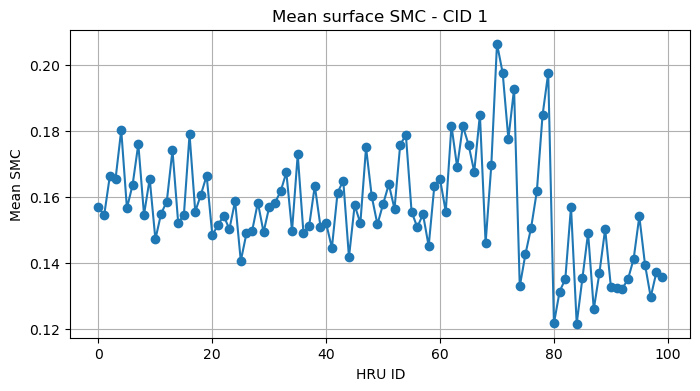

In [ ]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

cid = 1

fp = nc.Dataset(path + f"output_data/{cid}/2014-01-01.nc")

smc = fp.groups["data"].variables["smc"][:, :, 0]

fp.close()

smc_mean = np.nanmean(smc, axis=0)

plt.figure(figsize=(8,4))
plt.plot(np.arange(100), smc_mean, "o-")
plt.xlabel("HRU ID")
plt.ylabel("Mean SMC")
plt.title(f"Mean surface SMC - CID {cid}")
plt.grid(True)
plt.show()

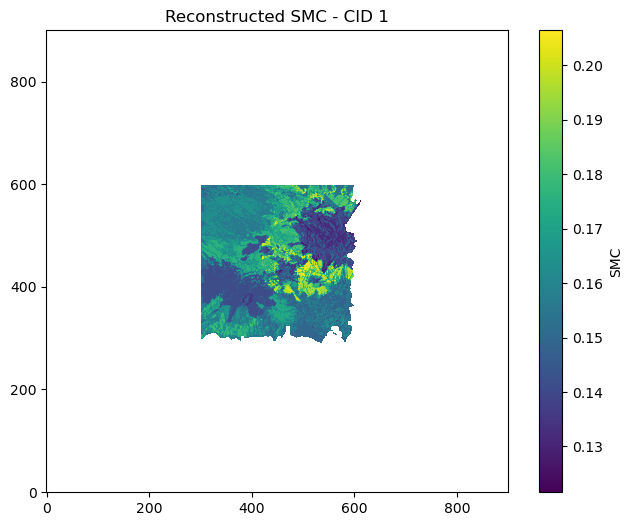

In [ ]:
tmp = np.full(hru.shape, np.nan)

valid = hru != -9999
tmp[valid] = smc_mean[hru[valid].astype(int)]

plt.figure(figsize=(8,6))
plt.imshow(tmp, origin="lower", cmap="viridis")
plt.colorbar(label="SMC")
plt.title(f"Reconstructed SMC - CID {cid}")
plt.show()

In [ ]:
import geospatialtools.gdal_tools as gdal_tools

meta = gdal_tools.retrieve_metadata(
    path + "postprocess/hrus.vrt"
)

for k, v in meta.items():
    print(k, ":", v)

proj4 : +proj=longlat +datum=WGS84 +no_defs
minx : -114.25041666666561
miny : 33.74958333333305
maxx : -103.74958333333265
maxy : 44.25041666666601
resx : 0.0008333333333333041
resy : -0.0008333333333333041
gt : (-114.25041666666561, 0.0008333333333333041, 0.0, 44.25041666666601, 0.0, -0.0008333333333333041)
nx : 12601
ny : 12601
projection : GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


Processing CID 1
Processing CID 2
Processing CID 3
Processing CID 4
Processing CID 5
Processing CID 6
Processing CID 7
Processing CID 8
Processing CID 9
Processing CID 10
Processing CID 11
Processing CID 12
Processing CID 13
Processing CID 14
Processing CID 15
Processing CID 16
Processing CID 17
Processing CID 18
Processing CID 19
Processing CID 20
Processing CID 21
Processing CID 22
Processing CID 23
Processing CID 24
Processing CID 25
Processing CID 26
Processing CID 27
Processing CID 28
Processing CID 29
Processing CID 30
Processing CID 31
Processing CID 32
Processing CID 33
Processing CID 34
Processing CID 35
Processing CID 36
Processing CID 37
Processing CID 38
Processing CID 39
Processing CID 40
Processing CID 41
Processing CID 42
Processing CID 43
Processing CID 44
Processing CID 45
Processing CID 46
Processing CID 47
Processing CID 48
Processing CID 49
Processing CID 50
Processing CID 51
Processing CID 52
Processing CID 53
Processing CID 54
Processing CID 55
Processing CID 56
P

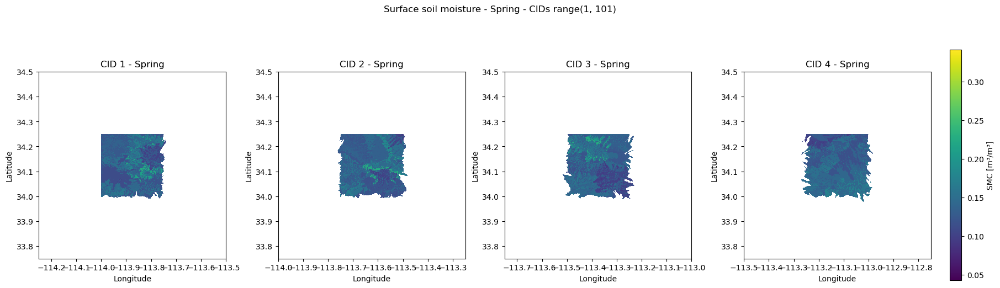

In [ ]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

#cids_to_plot = [100, 500, 1000, 1600]
cids_to_plot = range(1, 101)

season = "Spring"
season_months = (3, 4, 5)

fp = nc.Dataset(path + "1/input_file.nc")
time_var = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time_var, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

season_mask = times.dt.month.isin(season_months).values

all_maps = []
all_extents = []
global_min = np.inf
global_max = -np.inf

for cid in cids_to_plot:
    print(f"Processing CID {cid}", flush=True)

    hru = gdal_tools.read_raster(path + f"postprocess/hrus/{cid}.tif").astype(np.int32)
    meta = gdal_tools.retrieve_metadata(path + f"postprocess/hrus/{cid}.tif")

    fp = nc.Dataset(path + f"output_data/{cid}/2014-01-01.nc")
    smc = np.array(fp.groups["data"].variables["smc"][:, :, 0], dtype=np.float32)
    fp.close()

    data_ave = np.nanmean(smc[season_mask, :], axis=0).astype(np.float32)

    cid_map = np.full(hru.shape, np.nan, dtype=np.float32)
    valid = hru != -9999
    cid_map[valid] = data_ave[hru[valid].astype(np.int32)]

    extent = [meta["minx"], meta["maxx"], meta["miny"], meta["maxy"]]

    all_maps.append(cid_map)
    all_extents.append(extent)

    global_min = min(global_min, np.nanmin(cid_map))
    global_max = max(global_max, np.nanmax(cid_map))

fig, axes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)

for ax, cid, cid_map, extent in zip(axes, cids_to_plot, all_maps, all_extents):
    im = ax.imshow(
        cid_map,
        origin="lower",
        extent=extent,
        cmap="viridis",
        vmin=global_min,
        vmax=global_max,
        interpolation="nearest"
    )

    ax.set_title(f"CID {cid} - {season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes, label="SMC [m³/m³]", shrink=0.85, pad=0.02)

fig.suptitle(f"Surface soil moisture - {season} - CIDs {cids_to_plot}", y=1.08)

outfile = os.path.join(
    outputdir,
    f"test_4cid_smc_{season.lower()}_11yr_100hru_lonlat.png"
)

plt.savefig(outfile, dpi=200, bbox_inches="tight")
print("Saved:", outfile, flush=True)

plt.show()

In [ ]:
# MERGE TWO CIDS USING THEIR REAL LONGITUDE/LATITUDE

fig, ax = plt.subplots(figsize=(8, 6))

for cid, cid_map in zip(cids_to_plot, all_maps):

    meta = gdal_tools.retrieve_metadata(
        path + f"postprocess/hrus/{cid}.tif"
    )

    extent = [
        meta["minx"],
        meta["maxx"],
        meta["miny"],
        meta["maxy"],
    ]

    ax.imshow(
        cid_map,
        origin="lower",
        extent=extent,
        cmap="viridis",
        vmin=global_min,
        vmax=global_max,
        interpolation="nearest"
    )

ax.set_title(f"Surface soil moisture ({season}) - CIDs {cids_to_plot}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = plt.colorbar(ax.images[-1], ax=ax)
cbar.set_label("SMC [m³/m³]")

outfile = os.path.join(
    outputdir,
    f"merged_2cid_{season.lower()}_11yr_100hru.png"
)

#plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

NameError: name 'plt' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

plt.figure(figsize=(10,10))
plt.imshow(np.ma.masked_where(cids==-9999, cids), origin="lower", cmap="tab20")
plt.colorbar(label="CID")
plt.title("CID layout")
plt.show()

Saved: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots/merged_2cid_spring_11yr_100hru.png


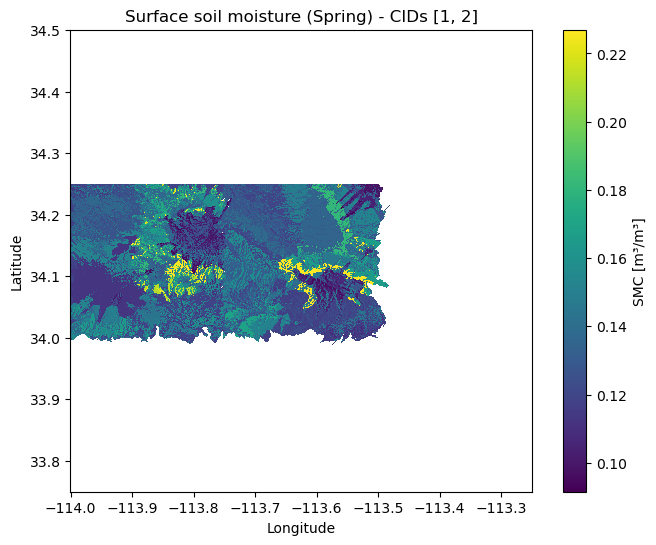

In [ ]:
# MERGE TWO CIDS USING THEIR REAL LONGITUDE/LATITUDE

fig, ax = plt.subplots(figsize=(8, 6))

for cid, cid_map in zip(cids_to_plot, all_maps):

    meta = gdal_tools.retrieve_metadata(
        path + f"postprocess/hrus/{cid}.tif"
    )

    extent = [
        meta["minx"],
        meta["maxx"],
        meta["miny"],
        meta["maxy"],
    ]

    ax.imshow(
        cid_map,
        origin="lower",
        extent=extent,
        cmap="viridis",
        vmin=global_min,
        vmax=global_max,
        interpolation="nearest"
    )

ax.set_title(f"Surface soil moisture ({season}) - CIDs {cids_to_plot}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = plt.colorbar(ax.images[-1], ax=ax)
cbar.set_label("SMC [m³/m³]")

outfile = os.path.join(
    outputdir,
    f"merged_2cid_{season.lower()}_11yr_100hru.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

In [ ]:
import os
import numpy as np
import geospatialtools.gdal_tools as gdal_tools

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

# Metadata

vrt_meta = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

print("VRT metadata")
for k in ["minx", "maxx", "miny", "maxy", "nx", "ny", "resx", "resy"]:
    if k in vrt_meta:
        print(k, vrt_meta[k])

# Read full VRTs once

print("Reading full hrus.vrt...", flush=True)
hrus_vrt = gdal_tools.read_raster(path + "postprocess/hrus.vrt")

print("Reading full cids.vrt...", flush=True)
cids_vrt = gdal_tools.read_raster(path + "postprocess/cids.vrt")

print("Done reading VRTs.", flush=True)


# Helper: convert lon/lat extent to row/col indices in VRT

def extent_to_window(meta, minx, maxx, miny, maxy):
    dx = (meta["maxx"] - meta["minx"]) / (meta["nx"] - 1)
    dy = (meta["maxy"] - meta["miny"]) / (meta["ny"] - 1)

    col0 = int(round((minx - meta["minx"]) / dx))
    col1 = int(round((maxx - meta["minx"]) / dx)) + 1

    row0 = int(round((miny - meta["miny"]) / dy))
    row1 = int(round((maxy - meta["miny"]) / dy)) + 1

    return row0, row1, col0, col1


# Compare selected individual TIFFs to VRT window

for cid in [1, 2, 3, 4, 100, 500, 1000, 1600]:

    print("\n" + "=" * 60)
    print("CID", cid)

    hru_tif_path = path + f"postprocess/hrus/{cid}.tif"
    cid_tif_path = path + f"postprocess/cids/{cid}.tif"

    hru_tif = gdal_tools.read_raster(hru_tif_path).astype(np.int32)
    cid_tif = gdal_tools.read_raster(cid_tif_path).astype(np.int32)

    tif_meta = gdal_tools.retrieve_metadata(hru_tif_path)

    row0, row1, col0, col1 = extent_to_window(
        vrt_meta,
        tif_meta["minx"],
        tif_meta["maxx"],
        tif_meta["miny"],
        tif_meta["maxy"]
    )

    print("TIFF shape:", hru_tif.shape)
    print("VRT window:", row0, row1, col0, col1)

    hru_win = hrus_vrt[row0:row1, col0:col1]
    cid_win = cids_vrt[row0:row1, col0:col1]

    print("VRT window shape:", hru_win.shape)

    # Make shapes match if off by one
    nr = min(hru_tif.shape[0], hru_win.shape[0])
    nc = min(hru_tif.shape[1], hru_win.shape[1])

    hru_tif2 = hru_tif[:nr, :nc]
    cid_tif2 = cid_tif[:nr, :nc]
    hru_win2 = hru_win[:nr, :nc]
    cid_win2 = cid_win[:nr, :nc]

    valid = hru_tif2 != -9999

    print("Valid pixels in TIFF:", np.sum(valid))
    print("Valid pixels in VRT window:", np.sum(hru_win2 != -9999))

    hru_match = np.all(hru_tif2[valid] == hru_win2[valid])
    cid_match = np.all(cid_tif2[valid] == cid_win2[valid])

    print("HRU values match VRT?", hru_match)
    print("CID values match VRT?", cid_match)

    print("TIFF HRU min/max:", hru_tif2[valid].min(), hru_tif2[valid].max())
    print("VRT  HRU min/max:", hru_win2[valid].min(), hru_win2[valid].max())

    print("TIFF CID unique:", np.unique(cid_tif2[valid])[:10])
    print("VRT  CID unique:", np.unique(cid_win2[valid])[:10])

VRT metadata
minx -114.25041666666561
maxx -103.74958333333265
miny 33.74958333333305
maxy 44.25041666666601
nx 12601
ny 12601
resx 0.0008333333333333041
resy -0.0008333333333333041
Reading full hrus.vrt...


Reading from: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir
Number of daily files: 4015
First file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/20140101.nc
Last file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/postprocess/output_dir/20241228.nc
Winter 2014 files: 90
First selected: 20140101.nc
Last selected : 20141231.nc
Dimensions: dict_keys(['lon', 'lat', 't'])
Variables: dict_keys(['lon', 'lat', 't', 'trad', 'smc', 'swe', 'snowh', 'fsno'])
Longitude: -114.23375 to -103.75042
Latitude : 33.75042 to 44.23375
Processing 1/90: 20140101.nc


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_334438/3865432277.py:102: RuntimeWarning: Mean of empty slice
  daily_mean = np.nanmean(data, axis=0)


Processing 11/90: 20140111.nc
Processing 21/90: 20140121.nc
Processing 31/90: 20140131.nc
Processing 41/90: 20140210.nc
Processing 51/90: 20140220.nc
Processing 61/90: 20141202.nc
Processing 71/90: 20141212.nc
Processing 81/90: 20141222.nc


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_334438/3865432277.py:114: RuntimeWarning: invalid value encountered in true_divide
  season_mean = sum_map / count_map


Valid cells: 361201
Min: 0.07821134100280082
Max: 0.5422225934763749
Saved: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots/PP_smc_Winter_2014_seasonal_mean_flipped.png


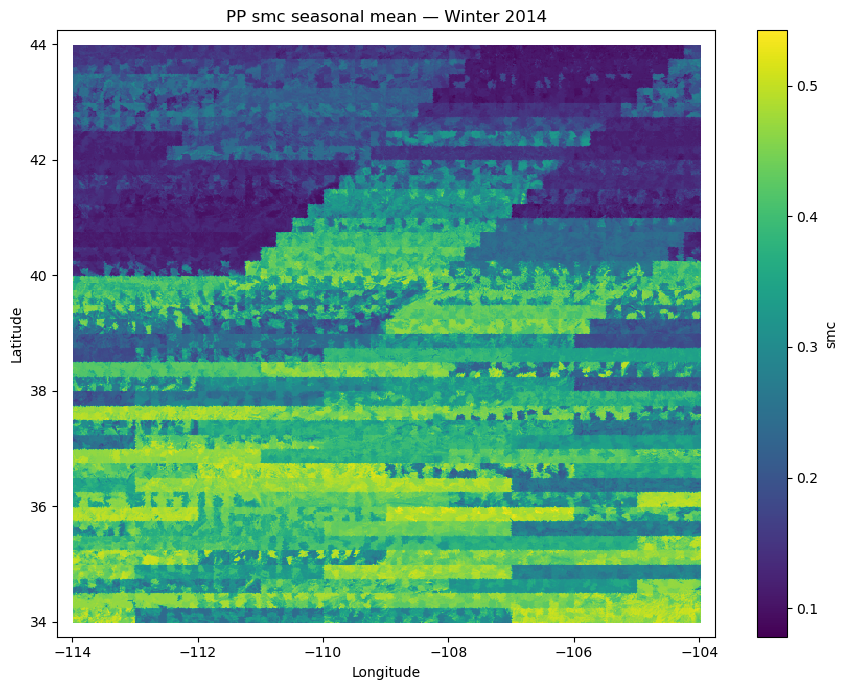

In [ ]:
# ONE-YEAR TEST: Plot one variable, one season, from postprocessed daily files
# With no-data mask + vertical flip test

import os
import glob
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt


experiment_dir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"

post_dir = f"{experiment_dir}/postprocess/output_dir"

outputdir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/output_plots"
os.makedirs(outputdir, exist_ok=True)

varname = "smc"          # options: "smc", "swe", "snowh", "fsno", "trad"

test_year = 2014

season_name = "Winter"
season_months = (12, 1, 2)

print("Reading from:", post_dir)

# GET DAILY FILES
files = sorted(glob.glob(f"{post_dir}/*.nc"))

print("Number of daily files:", len(files))
print("First file:", files[0])
print("Last file:", files[-1])

# SELECT ONE YEAR + ONE SEASON

season_files = []

for f in files:
    fname = os.path.basename(f).replace(".nc", "")
    date = pd.to_datetime(fname, format="%Y%m%d")

    if (date.year == test_year) and (date.month in season_months):
        season_files.append(f)

print(f"{season_name} {test_year} files:", len(season_files))

if len(season_files) == 0:
    raise RuntimeError("No files selected. Check test_year and season_months.")

print("First selected:", os.path.basename(season_files[0]))
print("Last selected :", os.path.basename(season_files[-1]))

# ============================================================
# READ COORDINATES
# ============================================================

fp = nc.Dataset(season_files[0])

print("Dimensions:", fp.dimensions.keys())
print("Variables:", fp.variables.keys())

lon = fp.variables["lon"][:]
lat = fp.variables["lat"][:]

fp.close()

print(f"Longitude: {lon[0]:.5f} to {lon[-1]:.5f}")
print(f"Latitude : {lat[0]:.5f} to {lat[-1]:.5f}")

# ============================================================
# ACCUMULATE SEASONAL MEAN
# ============================================================

sum_map = None
count_map = None

for i, f in enumerate(season_files):

    if i % 10 == 0:
        print(f"Processing {i+1}/{len(season_files)}: {os.path.basename(f)}", flush=True)

    fp = nc.Dataset(f)

    data = np.array(fp.variables[varname][:], dtype=float)

    fp.close()

    # Convert fill values to NaN
    data[data <= -9990] = np.nan

    # Average 8 three-hourly timesteps into daily mean
    with np.errstate(all="ignore"):
        daily_mean = np.nanmean(data, axis=0)

    if sum_map is None:
        sum_map = np.zeros_like(daily_mean, dtype=float)
        count_map = np.zeros_like(daily_mean, dtype=float)

    valid = np.isfinite(daily_mean)

    sum_map[valid] += daily_mean[valid]
    count_map[valid] += 1

# Final seasonal mean
season_mean = sum_map / count_map

# Mask cells with no valid model data
season_mean = np.ma.masked_where(
    (count_map == 0) | (~np.isfinite(season_mean)),
    season_mean
)

print("Valid cells:", np.sum(~season_mean.mask))
print("Min:", np.nanmin(season_mean))
print("Max:", np.nanmax(season_mean))

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

# Flip vertically because lat is south-to-north but array may be stored north-to-south
plot_data = np.flipud(season_mean)

im = ax.pcolormesh(
    lon,
    lat,
    plot_data,
    cmap="viridis",
    shading="auto"
)

ax.set_title(f"PP {varname} seasonal mean — {season_name} {test_year}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label=varname)

plt.tight_layout()

outfile = os.path.join(
    outputdir,
    f"PP_{varname}_{season_name}_{test_year}_seasonal_mean_flipped.png"
)

plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

========== HRUs ==========
Shape: (12601, 12601)
Min: 0.0
Max: 99.0
Unique HRUs: 100
First 20 HRUs: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]

========== CIDs ==========
Shape: (12601, 12601)
Min: 1.0
Max: 1600.0
Unique CIDs: 1600
First 20 CIDs: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]


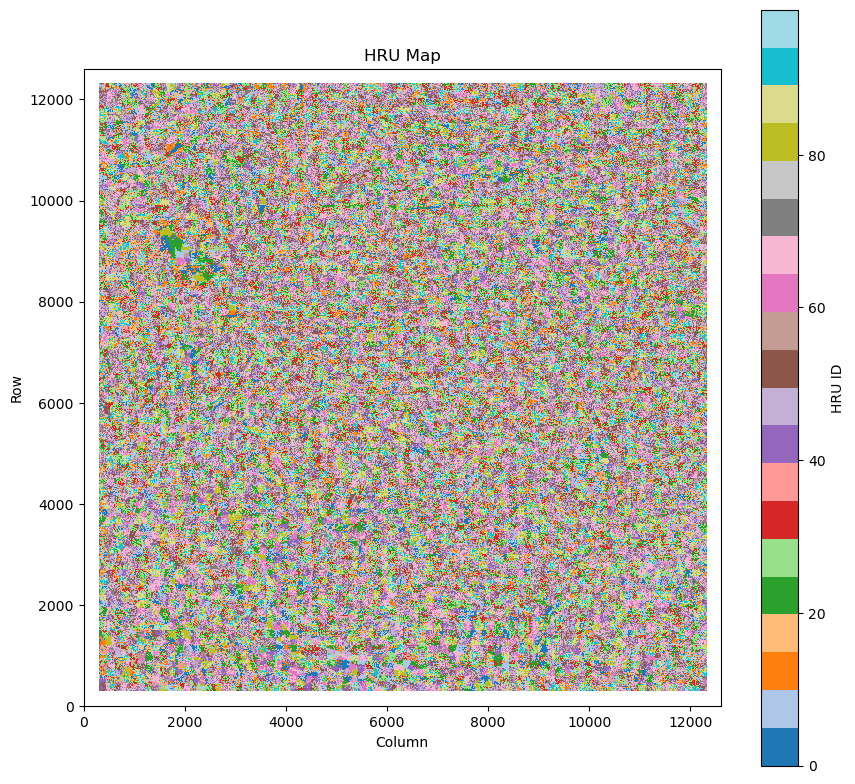

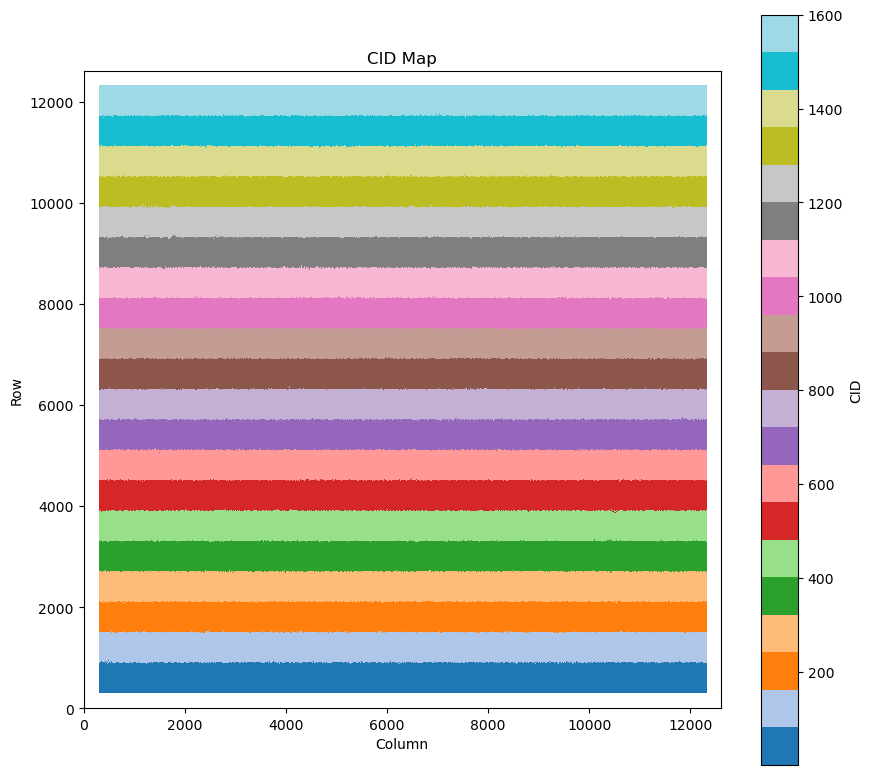

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# Path
# ============================================================

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

# ============================================================
# Read rasters
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

# ============================================================
# Print statistics
# ============================================================

valid_hrus = hrus[hrus != -9999]
valid_cids = cids[cids != -9999]

print("========== HRUs ==========")
print("Shape:", hrus.shape)
print("Min:", valid_hrus.min())
print("Max:", valid_hrus.max())
print("Unique HRUs:", len(np.unique(valid_hrus)))
print("First 20 HRUs:", np.unique(valid_hrus)[:20])

print()

print("========== CIDs ==========")
print("Shape:", cids.shape)
print("Min:", valid_cids.min())
print("Max:", valid_cids.max())
print("Unique CIDs:", len(np.unique(valid_cids)))
print("First 20 CIDs:", np.unique(valid_cids)[:20])

# ============================================================
# Mask background
# ============================================================

hrus_plot = np.ma.masked_where(hrus == -9999, hrus)
cids_plot = np.ma.masked_where(cids == -9999, cids)

# ============================================================
# Plot HRUs
# ============================================================

plt.figure(figsize=(9,8))

plt.imshow(
    np.flipud(hrus_plot),
    origin="lower",
    interpolation="nearest",
    cmap="tab20"
)

plt.title("HRU Map")
plt.xlabel("Column")
plt.ylabel("Row")
plt.colorbar(label="HRU ID")

plt.tight_layout()
plt.show()

# ============================================================
# Plot CIDs
# ============================================================

plt.figure(figsize=(9,8))

plt.imshow(
    np.flipud(cids_plot),
    origin="lower",
    interpolation="nearest",
    cmap="tab20"
)

plt.title("CID Map")
plt.xlabel("Column")
plt.ylabel("Row")
plt.colorbar(label="CID")

plt.tight_layout()
plt.show()

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test_new_test_domain/
Plotting dem
Plotting slope
Plotting y_aspect
Plotting x_aspect
Plotting svf
Plotting tvf
Plotting hor_n
Plotting hor_w
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_terrain_test025_old_all_cids_new.png


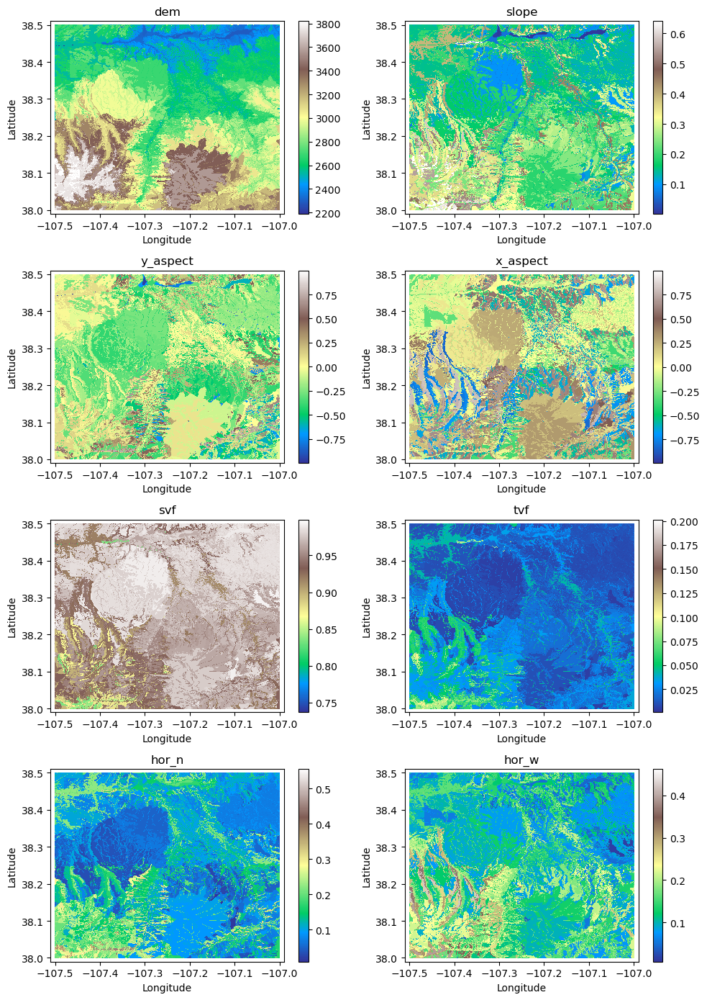

In [ ]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools
# Output path
outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

# Simulation path
path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test_new_test_domain/"

print(path)

# Read HRU and CID maps
hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

# Coordinate axes
coord_xx0 = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coord_yy0 = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

coords_x = coord_xx0
coords_y = coord_yy0

# Function to place HRU data on raster grid
def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

# Variables to plot
var2plot = [
    "dem", "slope",
    "y_aspect", "x_aspect",
    "svf", "tvf",
    "hor_n", "hor_w"
]

cid_list = [1, 2, 3, 4]

# Plot
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()

for j, ax in enumerate(axes):

    var = var2plot[j]
    print(f"Plotting {var}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"{c}/input_file.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)

        grp = fp.groups["parameters"]
        data = np.array(grp.variables[var][:])

        fp.close()

        final_map = place_data(final_map, data, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    # Valid-data extent with small no-data border
    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="terrain",
        shading="auto"
    )

    ax.set_title(var)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax)

plt.tight_layout()

outfile = os.path.join(outputdir, "res_terrain_test025_old_all_cids_new.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test_new_test_domain/
Creating plot for Winter
Creating plot for Spring
Creating plot for Summer
Creating plot for Fall
Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/res_smc_surface_seasonal_PP_test025_unflipped_auto_scale_new.png


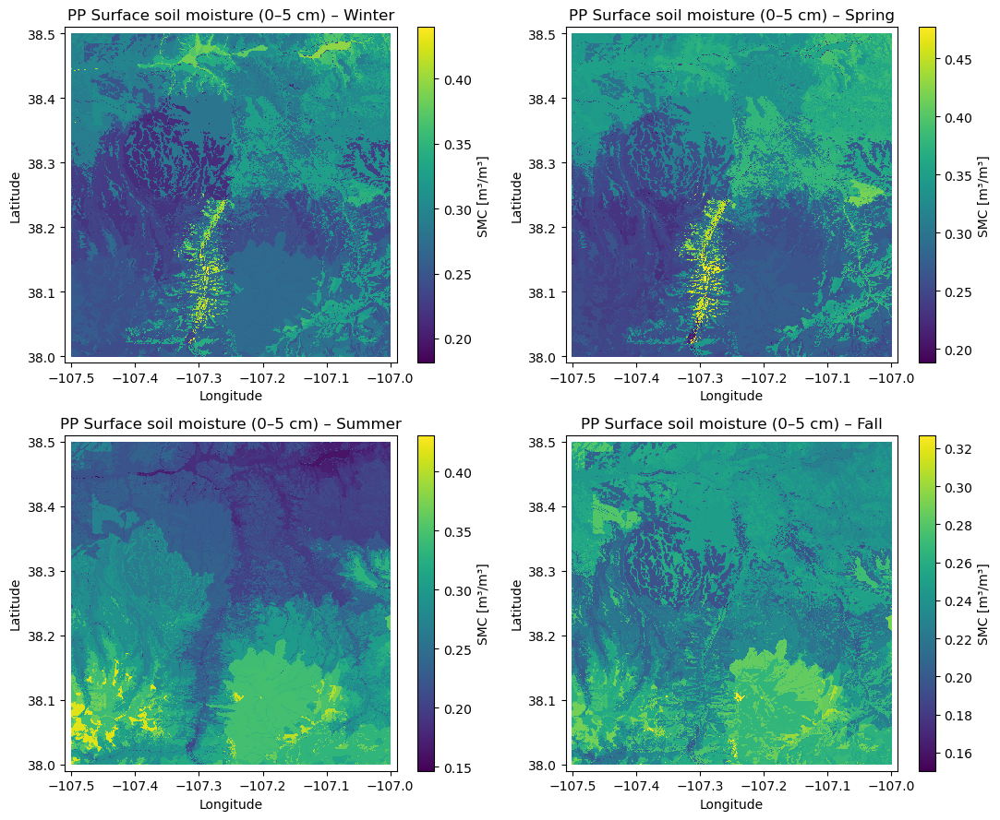

In [ ]:
# Soil moisture (smc) seasonal plots — TOP LAYER — PP — all CIDs
# Color scale is automatic for each season

import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test_new_test_domain/"
print(path)

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")
metad = gdal_tools.retrieve_metadata(path + "postprocess/hrus.vrt")

coords_x = np.linspace(metad["minx"], metad["maxx"], metad["nx"])
coords_y = np.linspace(metad["miny"], metad["maxy"], metad["ny"])

fp = nc.Dataset(path + "1/input_file.nc")
time = fp.groups["meteorology"].variables["time"][:]
fp.close()

start = pd.Timestamp("2014-01-01 00:00")
datetime_series = start + pd.to_timedelta(time, unit="h")
datetime_series = datetime_series.tz_localize("UTC").tz_convert("America/Denver")
times = pd.Series(datetime_series, name="datetime")

def place_data(final_map, model, hrus, cids, val):
    for i in range(final_map.shape[0]):
        for j in range(final_map.shape[1]):
            hru = int(hrus[i, j])
            ucid = int(cids[i, j])

            if (hru != -9999) and (ucid == val):
                final_map[i, j] = model[hru]

    return final_map

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = [(12, 1, 2), (3, 4, 5), (6, 7, 8), (9, 10, 11)]
cid_list = [1, 2, 3, 4]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for iss, ax in enumerate(axes):

    my_season = seasons[iss]
    my_months = season_months[iss]

    print(f"Creating plot for {my_season}")

    final_map = np.copy(hrus).astype(float)
    final_map[:] = -9999.0

    for c in cid_list:

        fp_path = path + f"output_data/{c}/2014-01-01.nc"

        if not os.path.exists(fp_path):
            print(f"Missing: {fp_path}")
            continue

        fp = nc.Dataset(fp_path)
        smc = np.array(fp.groups["data"].variables["smc"][:])
        fp.close()

        data = smc[:, :, 0]  # top soil layer: 0–5 cm

        times_index = times.dt.month.isin(my_months)
        data_sel = data[times_index, :]
        data_ave = np.nanmean(data_sel, axis=0)

        final_map = place_data(final_map, data_ave, hrus, cids, int(c))

    final_map = np.ma.masked_where(final_map == -9999, final_map)

    valid = ~final_map.mask
    rows, cols = np.where(valid)

    xmin = coords_x[cols.min()]
    xmax = coords_x[cols.max()]
    ymin = coords_y[rows.min()]
    ymax = coords_y[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    im = ax.pcolormesh(
        coords_x,
        coords_y,
        np.flipud(final_map),
        cmap="viridis",
        shading="auto"
    )

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {my_season}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.colorbar(im, ax=ax, label="SMC [m³/m³]")

plt.tight_layout()

outfile = os.path.join(outputdir, "res_smc_surface_seasonal_PP_test025_unflipped_auto_scale_new.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")

print("Saved:", outfile)

plt.show()

In [ ]:
import netCDF4 as nc
import numpy as np
import os

paths = {
    "old": "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_unflipped/",
    "new": "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test_new_test_domain/"
}

for name, path in paths.items():

    fp = nc.Dataset(os.path.join(path, "1", "input_file.nc"))

    hru = fp.groups["parameters"].variables["hru"][:]

    print(f"\n{name}")
    print("Number of HRUs:", len(hru))
    print("Min HRU ID:", np.min(hru))
    print("Max HRU ID:", np.max(hru))
    print("Unique HRUs:", len(np.unique(hru)))

    fp.close()


old
Number of HRUs: 200
Min HRU ID: 0.0
Max HRU ID: 199.0
Unique HRUs: 200

new
Number of HRUs: 100
Min HRU ID: 0.0
Max HRU ID: 99.0
Unique HRUs: 100


In [ ]:
import numpy as np
import netCDF4 as nc
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATH
# ============================================================

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

# ============================================================
# READ HRU/CID MAPS
# ============================================================

hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt").astype(np.int32)
cids = gdal_tools.read_raster(path + "postprocess/cids.vrt").astype(np.int32)

print("Raster shape:", hrus.shape)

# ============================================================
# CHECK A FEW CIDs
# ============================================================

for cid in [1, 2, 100, 800, 1600]:

    print("\n" + "=" * 70)
    print(f"CID {cid}")

    mask = (cids == cid) & (hrus != -9999)

    hru_ids = hrus[mask]

    print("Pixels in CID:", len(hru_ids))
    print("Unique HRUs:", len(np.unique(hru_ids)))

    print("Minimum HRU ID:", hru_ids.min())
    print("Maximum HRU ID:", hru_ids.max())

    print("First 20 unique HRU IDs:")
    print(np.unique(hru_ids)[:20])

    # --------------------------------------------------------
    # Read the corresponding input file
    # --------------------------------------------------------

    fp = nc.Dataset(path + f"{cid}/input_file.nc")

    dem = fp.groups["parameters"].variables["dem"][:]

    fp.close()

    print("Length of DEM vector:", len(dem))

    # --------------------------------------------------------
    # Check indexing
    # --------------------------------------------------------

    if hru_ids.min() == 0 and hru_ids.max() == len(dem) - 1:
        print("✓ HRUs are ZERO-based (0 ... N-1)")
        print("✓ Mapping with data[hru_ids] is correct.")

    elif hru_ids.min() == 1 and hru_ids.max() == len(dem):
        print("✓ HRUs are ONE-based (1 ... N)")
        print("⚠ You should use data[hru_ids - 1] instead.")

    else:
        print("⚠ Unexpected HRU numbering!")
        print("This needs investigation.")

print("\nFinished.")

Raster shape: (12601, 12601)

CID 1
Pixels in CID: 89510
Unique HRUs: 100
Minimum HRU ID: 0
Maximum HRU ID: 99
First 20 unique HRU IDs:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Length of DEM vector: 100
✓ HRUs are ZERO-based (0 ... N-1)
✓ Mapping with data[hru_ids] is correct.

CID 2
Pixels in CID: 91042
Unique HRUs: 100
Minimum HRU ID: 0
Maximum HRU ID: 99
First 20 unique HRU IDs:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Length of DEM vector: 100
✓ HRUs are ZERO-based (0 ... N-1)
✓ Mapping with data[hru_ids] is correct.

CID 100
Pixels in CID: 91283
Unique HRUs: 100
Minimum HRU ID: 0
Maximum HRU ID: 99
First 20 unique HRU IDs:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Length of DEM vector: 100
✓ HRUs are ZERO-based (0 ... N-1)
✓ Mapping with data[hru_ids] is correct.

CID 800
Pixels in CID: 88848
Unique HRUs: 100
Minimum HRU ID: 0
Maximum HRU ID: 99
First 20 unique HRU IDs:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 1

Simulation path: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/
HRU map shape: (12601, 12601)
CID map shape: (12601, 12601)
HRU min/max: -9999 99
CID min/max: -9999 1600
Total timesteps: 32120
First time: 2014-01-01 00:00:00
Last time : 2024-12-28 21:00:00
Winter 2014 timesteps: 720
Processing CID 1
  smc shape: (32120, 100)
  selected shape: (720, 100)
  hru_values length: 100
  hru_values min: 0.120418295
  hru_values max: 0.19870335
Processing CID 2
Processing CID 3
Processing CID 4
Processing CID 5
Processing CID 6
Processing CID 7
Processing CID 8
Processing CID 9
Processing CID 10
Processing CID 11
Processing CID 12
Processing CID 13
Processing CID 14
Processing CID 15
Processing CID 16
Processing CID 17
Processing CID 18
Processing CID 19
Processing CID 20
Processing CID 21
Processing CID 22
Processing CID 23
Processing CID 24
Processing CID 25
Processing CID 26
Processing 

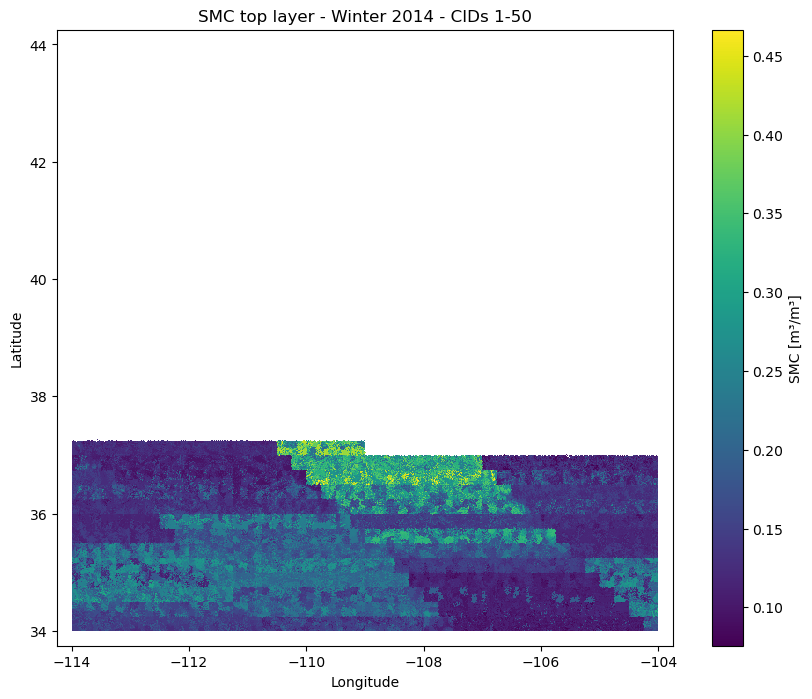

In [ ]:
import os
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import geospatialtools.gdal_tools as gdal_tools

# ============================================================
# PATHS
# ============================================================

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/"

print("Simulation path:", path, flush=True)

# ============================================================
# READ HRU AND CID MAPS
# ============================================================

hrus_file = path + "postprocess/hrus.vrt"
cids_file = path + "postprocess/cids.vrt"

hrus = gdal_tools.read_raster(hrus_file).astype(np.int32)
cids = gdal_tools.read_raster(cids_file).astype(np.int32)
metad = gdal_tools.retrieve_metadata(hrus_file)

extent = [metad["minx"], metad["maxx"], metad["miny"], metad["maxy"]]

print("HRU map shape:", hrus.shape, flush=True)
print("CID map shape:", cids.shape, flush=True)
print("HRU min/max:", np.nanmin(hrus), np.nanmax(hrus), flush=True)
print("CID min/max:", np.nanmin(cids), np.nanmax(cids), flush=True)

# ============================================================
# SETTINGS
# ============================================================

var = "smc"
season_name = "Winter"
season_months = (12, 1, 2)

# Only first 50 CIDs
cid_list = range(1, 501)

year_to_plot = 2014
soil_layer = 0   # top soil layer

# ============================================================
# READ TIME FROM INPUT FILE
# ============================================================

time_file = path + "1/input_file.nc"

with nc.Dataset(time_file) as fp:
    time = fp.groups["meteorology"].variables["time"][:]

start = pd.Timestamp("2014-01-01 00:00:00")

times = pd.Series(
    start + pd.to_timedelta(time, unit="h"),
    name="datetime"
)

season_index = (
    (times.dt.year == year_to_plot) &
    (times.dt.month.isin(season_months))
).values

print("Total timesteps:", len(times), flush=True)
print("First time:", times.iloc[0], flush=True)
print("Last time :", times.iloc[-1], flush=True)
print(f"{season_name} {year_to_plot} timesteps:", season_index.sum(), flush=True)

if season_index.sum() == 0:
    raise RuntimeError("No timesteps selected. Check year_to_plot and season_months.")

# ============================================================
# FUNCTION: MAP HRU VALUES TO GRID
# ============================================================

def map_hru_values_to_grid(final_map, hrus, cids, cid, hru_values):
    """
    Map one CID's HRU values back to grid pixels.

    final_map : 2D output raster
    hrus      : 2D HRU ID raster
    cids      : 2D CID ID raster
    cid       : current catchment/tile ID
    hru_values: 1D array, one value per HRU
    """

    mask = (cids == cid) & (hrus != -9999)

    if not np.any(mask):
        return final_map

    rows, cols = np.where(mask)
    hru_ids = hrus[rows, cols].astype(np.int32)

    # Assumes HRU IDs are 0-based: 0, 1, 2, ..., nhru-1
    valid = (hru_ids >= 0) & (hru_ids < len(hru_values))

    final_map[rows[valid], cols[valid]] = hru_values[hru_ids[valid]]

    return final_map

# ============================================================
# MAP SMC VALUES TO RASTER FOR 50 CIDS
# ============================================================

final_map = np.full(hrus.shape, np.nan, dtype=np.float32)

for cid in cid_list:

    print(f"Processing CID {cid}", flush=True)

    fp_path = path + f"output_data/{cid}/2014-01-01.nc"

    if not os.path.exists(fp_path):
        print(f"  Missing file: {fp_path}", flush=True)
        continue

    with nc.Dataset(fp_path) as fp:
        grp = fp.groups["data"]

        if var not in grp.variables:
            print(f"  {var} missing in CID {cid}", flush=True)
            continue

        # smc(time, hru, soil)
        smc = np.array(grp.variables[var][:, :, soil_layer], dtype=np.float32)

    smc[smc <= -9990] = np.nan

    hru_values = np.nanmean(smc[season_index, :], axis=0)

    if cid == 1:
        print("  smc shape:", smc.shape, flush=True)
        print("  selected shape:", smc[season_index, :].shape, flush=True)
        print("  hru_values length:", len(hru_values), flush=True)
        print("  hru_values min:", np.nanmin(hru_values), flush=True)
        print("  hru_values max:", np.nanmax(hru_values), flush=True)

    final_map = map_hru_values_to_grid(
        final_map,
        hrus,
        cids,
        cid,
        hru_values
    )

print("Final valid pixels:", np.sum(np.isfinite(final_map)), flush=True)
print("Final min:", np.nanmin(final_map), flush=True)
print("Final max:", np.nanmax(final_map), flush=True)

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    final_map,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)

ax.set_title(f"SMC top layer - {season_name} {year_to_plot} - CIDs 1-50")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.colorbar(im, ax=ax, label="SMC [m³/m³]")

outfile = os.path.join(
    outputdir,
    f"smc_top_layer_{season_name}_{year_to_plot}_100hru_cids_1_50.png"
)

plt.savefig(outfile, dpi=250, bbox_inches="tight")

print("Saved:", outfile, flush=True)

plt.show()

Processing CID 1
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (32120, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 100
  HRU value min/max: 0.08180573 0.21285546
  HRU raster shape: (901, 901)
  Valid raster pixels: 89510
  Wrote: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/winter2014_smc_cids_1_50_tiles/1.tif
Processing CID 2
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (32120, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 100
  HRU value min/max: 0.08180573 0.21285546
  HRU raster shape: (901, 901)
  Valid raster pixels: 91042
  Wrote: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/winter2014_smc_cids_1_50_tiles/2.tif
Processing CID 3
  Variable dimensions: ('time', 'hru', 'soil')
  Variable shape: (32120, 100, 10)
  Timesteps selected: 472
  Selected data shape: (472, 100)
  Number of HRU values: 1

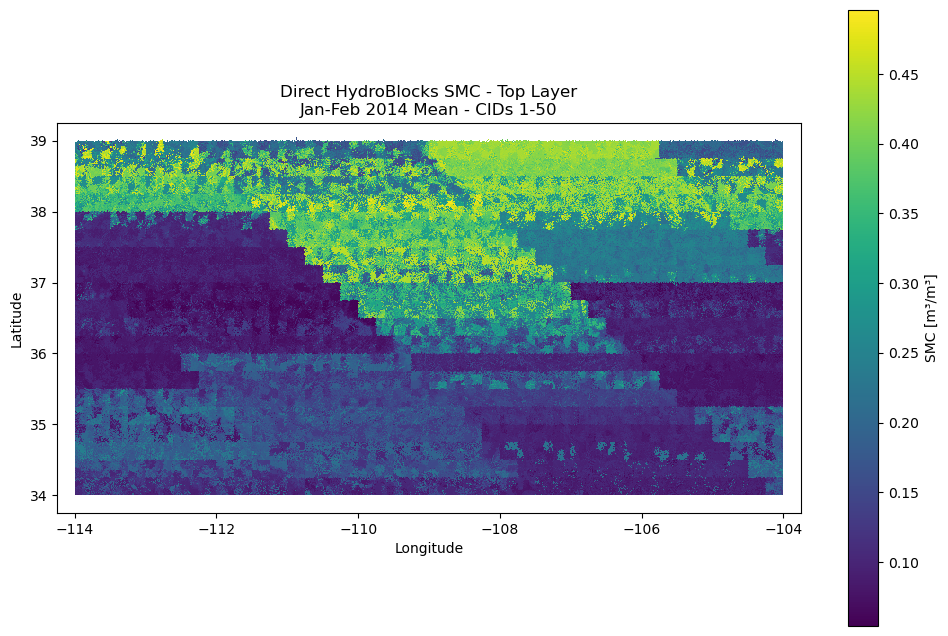

In [ ]:
#!/usr/bin/env python3

import os
import subprocess
import numpy as np
import netCDF4 as nc
import rasterio
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

edir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "Rice_NMT_Snow/upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"
)

output_data = os.path.join(edir, "output_data")
hru_dir = os.path.join(edir, "postprocess", "hrus")

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/output_plots"
)

os.makedirs(outputdir, exist_ok=True)


# ============================================================
# SETTINGS
# ============================================================

var = "smc"

# Top soil layer
layer = 0

# Direct HydroBlocks output file
stem = "2014-01-01"

# Time window
start_date = "2014-01-01"
end_date = "2014-02-28"

# First few CIDs
cid_list = range(1, 801)

# Aggregation
agg = "mean"


# ============================================================
# OUTPUT FILES
# ============================================================

tile_output_dir = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50_tiles"
)

os.makedirs(tile_output_dir, exist_ok=True)

vrt_file = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.vrt"
)

merged_tif = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.tif"
)

plot_file = os.path.join(
    outputdir,
    "winter2014_smc_cids_1_50.png"
)


# ============================================================
# FUNCTION: GET TIME INDICES
# ============================================================

def window_indices(fp, start, end):

    """
    Select timesteps using the HydroBlocks metadata/date variable.

    date is in hours since 1900-01-01.
    """

    import datetime as dt

    dvar = fp.groups["metadata"].variables["date"]

    hours = np.asarray(
        dvar[:],
        dtype=np.float64
    )

    epoch = dt.datetime(1900, 1, 1)

    t0 = (
        dt.datetime.strptime(start, "%Y-%m-%d") - epoch
    ).total_seconds() / 3600.0

    # Inclusive end date
    t1 = (
        dt.datetime.strptime(end, "%Y-%m-%d")
        + dt.timedelta(days=1)
        - epoch
    ).total_seconds() / 3600.0

    idx = np.where(
        (hours >= t0) &
        (hours < t1)
    )[0]

    return idx


# ============================================================
# FUNCTION: PROCESS ONE CID
# ============================================================

def render_one(cid):

    print("=" * 60)
    print(f"Processing CID {cid}", flush=True)

    # --------------------------------------------------------
    # Files
    # --------------------------------------------------------

    ncpath = os.path.join(
        output_data,
        str(cid),
        stem + ".nc"
    )

    hrupath = os.path.join(
        hru_dir,
        f"{cid}.tif"
    )

    if not os.path.exists(ncpath):

        print(
            f"  Missing model file: {ncpath}",
            flush=True
        )

        return None

    if not os.path.exists(hrupath):

        print(
            f"  Missing HRU raster: {hrupath}",
            flush=True
        )

        return None


    # --------------------------------------------------------
    # Read model output
    # --------------------------------------------------------

    fp = nc.Dataset(ncpath, "r")

    try:

        fp.set_auto_mask(False)

        idx = window_indices(
            fp,
            start_date,
            end_date
        )

        if idx.size == 0:

            print(
                f"  No timesteps between "
                f"{start_date} and {end_date}",
                flush=True
            )

            return None


        # ----------------------------------------------------
        # Read variable
        # ----------------------------------------------------

        v = fp.groups["data"].variables[var]

        print(
            "  Variable dimensions:",
            v.dimensions,
            flush=True
        )

        print(
            "  Variable shape:",
            v.shape,
            flush=True
        )


        # ----------------------------------------------------
        # Read selected time window
        # ----------------------------------------------------

        raw = v[
            idx[0]:idx[-1] + 1,
            ...
        ]

        sub = np.asarray(
            raw,
            dtype=np.float32
        )


        # ----------------------------------------------------
        # Make sure selected indices match
        # ----------------------------------------------------

        if idx.size != sub.shape[0]:

            sub = sub[
                idx - idx[0]
            ]


        # ----------------------------------------------------
        # Select soil layer
        # ----------------------------------------------------

        if layer is not None:

            if sub.ndim != 3:

                print(
                    f"  ERROR: {var} is {sub.ndim}-D "
                    f"but layer was requested",
                    flush=True
                )

                return None

            # smc(time, hru, soil)
            sub = sub[:, :, layer]

        elif sub.ndim != 2:

            print(
                f"  ERROR: {var} is {sub.ndim}-D. "
                f"A layer must be specified.",
                flush=True
            )

            return None


        nt_used = sub.shape[0]

        print(
            f"  Timesteps selected: {nt_used}",
            flush=True
        )

        print(
            "  Selected data shape:",
            sub.shape,
            flush=True
        )


    finally:

        fp.close()


    # --------------------------------------------------------
    # Aggregate over time
    # --------------------------------------------------------

    with np.errstate(
        invalid="ignore",
        divide="ignore"
    ):

        if agg == "mean":

            vals = np.nanmean(
                sub,
                axis=0
            )

        elif agg == "max":

            vals = np.nanmax(
                sub,
                axis=0
            )

        elif agg == "min":

            vals = np.nanmin(
                sub,
                axis=0
            )

        elif agg == "sum":

            vals = np.nansum(
                sub,
                axis=0
            )

        else:

            raise ValueError(
                f"Unknown aggregation: {agg}"
            )


    vals = np.asarray(
        vals,
        dtype=np.float32
    )


    print(
        "  Number of HRU values:",
        vals.size,
        flush=True
    )

    print(
        "  HRU value min/max:",
        np.nanmin(vals),
        np.nanmax(vals),
        flush=True
    )


    # ========================================================
    # READ THIS CID'S OWN HRU RASTER
    # ========================================================

    with rasterio.open(hrupath) as src:

        hru = np.ascontiguousarray(
            src.read(
                1,
                masked=False
            )
        )

        profile = src.profile.copy()


    print(
        "  HRU raster shape:",
        hru.shape,
        flush=True
    )


    nodata = profile.get("nodata")

    if nodata is None:

        nodata = -9999.0


    # ========================================================
    # MAP HRU VALUES DIRECTLY TO TILE
    # ========================================================

    ids = hru.astype(
        np.int64
    )

    valid = (
        (hru != nodata)
        &
        (ids >= 0)
        &
        (ids < vals.size)
    )


    print(
        "  Valid raster pixels:",
        np.sum(valid),
        flush=True
    )


    if not valid.any():

        print(
            f"  CID {cid}: no valid HRU pixels",
            flush=True
        )

        return None


    # --------------------------------------------------------
    # Output tile
    # --------------------------------------------------------

    out = np.full(
        hru.shape,
        -9999.0,
        dtype=np.float32
    )


    # Critical mapping:
    #
    # raster HRU ID -> model HRU value
    #
    out[valid] = vals[
        ids[valid]
    ]


    # ========================================================
    # WRITE THIS CID'S GEOTIFF
    # ========================================================

    profile.update(
        dtype="float32",
        count=1,
        nodata=-9999.0,
        compress="deflate",
        tiled=True
    )


    tile_path = os.path.join(
        tile_output_dir,
        f"{cid}.tif"
    )


    with rasterio.open(
        tile_path,
        "w",
        **profile
    ) as dst:

        dst.write(
            out,
            1
        )


    print(
        f"  Wrote: {tile_path}",
        flush=True
    )


    return {
        "cid": cid,
        "file": tile_path,
        "nt": nt_used,
        "min": float(np.nanmin(vals)),
        "max": float(np.nanmax(vals))
    }


# ============================================================
# PROCESS ALL SELECTED CIDS
# ============================================================

results = []

for cid in cid_list:

    result = render_one(cid)

    if result is not None:

        results.append(result)


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print(
    "Requested CIDs:",
    len(list(cid_list))
)

print(
    "Successfully processed:",
    len(results)
)


if len(results) == 0:

    raise RuntimeError(
        "No CIDs were successfully processed."
    )


# ------------------------------------------------------------
# Check timestep count
# ------------------------------------------------------------

nt_seen = sorted(
    set(
        r["nt"]
        for r in results
    )
)


print(
    "Timesteps used per tile:",
    nt_seen
)


if len(nt_seen) > 1:

    print(
        "WARNING: timestep count is NOT uniform across tiles!"
    )


# ------------------------------------------------------------
# Value range
# ------------------------------------------------------------

global_min = min(
    r["min"]
    for r in results
)

global_max = max(
    r["max"]
    for r in results
)


print(
    "Value range across tiles:",
    global_min,
    "to",
    global_max
)


# ============================================================
# CREATE FILE LIST FOR GDAL
# ============================================================

list_file = os.path.join(
    tile_output_dir,
    "files.txt"
)


with open(
    list_file,
    "w"
) as fh:

    for result in sorted(
        results,
        key=lambda x: x["cid"]
    ):

        fh.write(
            result["file"] + "\n"
        )


# ============================================================
# BUILD VRT
# ============================================================

print("\nBuilding VRT...", flush=True)


subprocess.run(
    [
        "gdalbuildvrt",

        "-srcnodata",
        "-9999",

        "-vrtnodata",
        "-9999",

        "-input_file_list",
        list_file,

        vrt_file
    ],
    check=True
)


print(
    "Created VRT:",
    vrt_file,
    flush=True
)


# ============================================================
# CREATE MERGED GEOTIFF
# ============================================================

print(
    "\nCreating merged GeoTIFF...",
    flush=True
)


subprocess.run(
    [
        "gdal_translate",

        "-co",
        "COMPRESS=DEFLATE",

        "-co",
        "TILED=YES",

        "-co",
        "BIGTIFF=IF_SAFER",

        vrt_file,
        merged_tif
    ],
    check=True
)


print(
    "Created merged GeoTIFF:",
    merged_tif,
    flush=True
)


# ============================================================
# READ MERGED TIFF
# ============================================================

with rasterio.open(
    merged_tif
) as src:

    merged = src.read(
        1
    ).astype(
        np.float32
    )

    bounds = src.bounds


# Convert nodata to NaN only for plotting
merged[
    merged <= -9990
] = np.nan


print(
    "Merged raster shape:",
    merged.shape,
    flush=True
)

print(
    "Merged valid pixels:",
    np.sum(
        np.isfinite(
            merged
        )
    ),
    flush=True
)

print(
    "Merged min:",
    np.nanmin(
        merged
    ),
    flush=True
)

print(
    "Merged max:",
    np.nanmax(
        merged
    ),
    flush=True
)


# ============================================================
# PLOT
# ============================================================

extent = [
    bounds.left,
    bounds.right,
    bounds.bottom,
    bounds.top
]


fig, ax = plt.subplots(
    figsize=(12, 8)
)


im = ax.imshow(
    merged,
    origin="upper",
    extent=extent,
    cmap="viridis",
    interpolation="nearest"
)


ax.set_title(
    "Direct HydroBlocks SMC - Top Layer\n"
    "Jan-Feb 2014 Mean - CIDs 1-50"
)


ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)


cbar = plt.colorbar(
    im,
    ax=ax,
    label="SMC [m³/m³]"
)


plt.savefig(
    plot_file,
    dpi=300,
    bbox_inches="tight"
)


print(
    "Saved plot:",
    plot_file,
    flush=True
)


plt.show()

In [ ]:
import netCDF4 as nc

forcing_file = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/data/cids/1/tair.nc"

with nc.Dataset(forcing_file) as fp:
    print("Variables:", list(fp.variables))

    for name in ["lat", "latitude", "y"]:
        if name in fp.variables:
            lat = fp.variables[name][:]
            print("Latitude variable:", name)
            print("First five:", lat[:5])
            print("Last five:", lat[-5:])
            print("First latitude:", lat[0])
            print("Last latitude:", lat[-1])

Variables: ['lon', 'lat', 't', 'tair']
Latitude variable: lat
First five: [33.80000114 33.90000343 34.00000572 34.10000801 34.2000103 ]
Last five: [34.10000801 34.2000103  34.30001259 34.40001488 34.50001717]
First latitude: 33.80000114440918
Last latitude: 34.500017166137695


In [ ]:
python - <<'PY'
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import rasterio

exp = (
    "/scratch/alpine/battobrah@xsede.org/"
    "Rice_NMT_Snow/upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"
)

cids_file = f"{exp}/postprocess/cids.vrt"
output_file = (
    "/home/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/cid_map_labeled.png"
)

with rasterio.open(cids_file) as src:
    cids = src.read(1)
    bounds = src.bounds
    transform = src.transform

valid_cids = np.unique(cids[cids > 0]).astype(int)

fig, ax = plt.subplots(figsize=(24, 22))

image = ax.imshow(
    np.ma.masked_where(cids <= 0, cids),
    extent=[
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top
    ],
    origin="upper",
    cmap="terrain",
    interpolation="nearest"
)

# Add one label at the center of every CID
for cid in valid_cids:
    rows, cols = np.where(cids == cid)

    if rows.size == 0:
        continue

    row = int(np.mean(rows))
    col = int(np.mean(cols))

    x, y = rasterio.transform.xy(
        transform,
        row,
        col,
        offset="center"
    )

    ax.text(
        x,
        y,
        str(cid),
        ha="center",
        va="center",
        fontsize=3,
        color="black"
    )

fig.colorbar(image, ax=ax, label="CID", shrink=0.75)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("HydroBlocks full-domain CID map")
ax.set_aspect("equal")

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print(f"Saved: {output_file}")
print(f"Number of CIDs plotted: {len(valid_cids)}")
print(f"Minimum CID: {valid_cids.min()}")
print(f"Maximum CID: {valid_cids.max()}")
PY

SyntaxError: invalid syntax (2072240051.py, line 1)


##############################################################################
BRIGHT BAND
##############################################################################

CID 1
  Number of files:    1
  Total timesteps:    32120
  Total size:         380.11 MB
  SMC1 minimum:       0.035349
  SMC1 maximum:       0.463434
  SMC1 mean:          0.159779
  SMC1 standard dev.: 0.110023

  File: 2014-01-01.nc
    Timesteps:     32120
    File size:     380.11 MB
    Modified:      2026-06-20 10:23:18
    Original SMC:  data/smc (32120, 100, 10)
    Number HRUs:   100
    Time source:   metadata/time
    Weight source: metadata/area

CID 2
  Number of files:    1
  Total timesteps:    32120
  Total size:         380.11 MB
  SMC1 minimum:       0.038216
  SMC1 maximum:       0.453926
  SMC1 mean:          0.160068
  SMC1 standard dev.: 0.104850

  File: 2014-01-01.nc
    Timesteps:     32120
    File size:     380.11 MB
    Modified:      2026-06-20 10:23:31
    Original SMC:  data/smc (3212

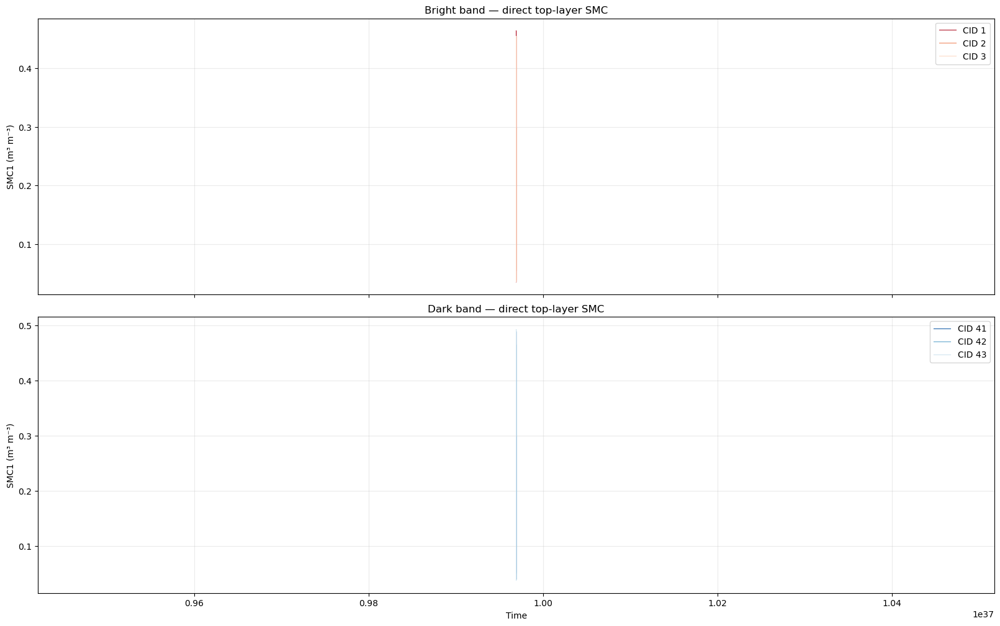

Saved plot: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/direct_cid_comparison/direct_smc1_six_cids.png

------------------------------------------------------------------------------
PAIR: bright CID 1 vs dark CID 41
Compared timesteps:          32120
Bright mean SMC1:            0.159779
Dark mean SMC1:              0.186827
Mean difference:             -0.027049
Mean absolute difference:    0.033505
Maximum absolute difference: 0.248919
Series correlation:          0.940690

------------------------------------------------------------------------------
PAIR: bright CID 2 vs dark CID 42
Compared timesteps:          32120
Bright mean SMC1:            0.160068
Dark mean SMC1:              0.190847
Mean difference:             -0.030779
Mean absolute difference:    0.039006
Maximum absolute difference: 0.261856
Series correlation:          0.894972

-------------------------------

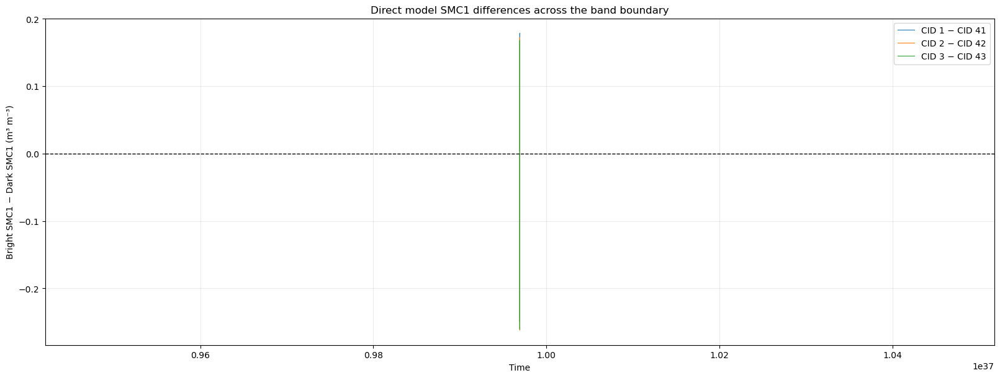

Saved pair summary: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/direct_cid_comparison/direct_cid_pair_summary.csv
Saved difference plot: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/direct_cid_comparison/direct_smc1_boundary_differences.png

FILE AND TIMESTEP CONSISTENCY
Timestep counts:
  CID 1: 32120
  CID 2: 32120
  CID 3: 32120
  CID 41: 32120
  CID 42: 32120
  CID 43: 32120

NetCDF file counts:
  CID 1: 1
  CID 2: 1
  CID 3: 1
  CID 41: 1
  CID 42: 1
  CID 43: 1

PASS: All selected CIDs have the same timestep count.
PASS: All selected CIDs have the same file count.

Comparison complete.


In [6]:
#!/usr/bin/env python3

import os
import glob
from datetime import datetime

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt


# =====================================================================
# CONFIGURATION
# =====================================================================

experiment = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/"
    "experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"
)

output_root = os.path.join(experiment, "output_data")

# ---------------------------------------------------------
# REPLACE THESE WITH THE CIDs FROM YOUR ACTUAL BAND BOUNDARY
#
# Pairing is positional:
# bright_cids[0] is compared with dark_cids[0], etc.
# ---------------------------------------------------------

bright_cids = [1, 2, 3]
dark_cids   = [41, 42, 43]

output_directory = os.path.join(experiment, "direct_cid_comparison")
os.makedirs(output_directory, exist_ok=True)


# =====================================================================
# FIND VARIABLES AND GROUPS
# =====================================================================

def find_variable(dataset, variable_name):
    """
    Search the root group and all immediate NetCDF groups for a variable.

    Returns
    -------
    variable : netCDF4.Variable
    location : str
    """

    if variable_name in dataset.variables:
        return dataset.variables[variable_name], variable_name

    for group_name, group in dataset.groups.items():
        if variable_name in group.variables:
            location = f"{group_name}/{variable_name}"
            return group.variables[variable_name], location

    raise KeyError(
        f"Variable '{variable_name}' was not found in "
        f"{dataset.filepath()}"
    )


def find_optional_variable(dataset, variable_names):
    """
    Search for the first available variable in a list.
    """

    for variable_name in variable_names:
        try:
            return find_variable(dataset, variable_name)
        except KeyError:
            continue

    return None, None


# =====================================================================
# TIME EXTRACTION
# =====================================================================

def read_time(dataset, expected_length):
    """
    Read and decode the time coordinate.

    If no usable coordinate is found, return timestep indices.
    """

    time_variable, time_location = find_optional_variable(
        dataset,
        ["time", "date", "t"]
    )

    if time_variable is None:
        return np.arange(expected_length), "timestep index"

    raw_time = np.asarray(time_variable[:]).squeeze()

    if raw_time.ndim == 0:
        raw_time = np.asarray([raw_time])

    if len(raw_time) != expected_length:
        print(
            f"WARNING: Time length {len(raw_time)} does not match "
            f"SMC length {expected_length} in {dataset.filepath()}."
        )
        return np.arange(expected_length), "timestep index"

    units = getattr(time_variable, "units", None)
    calendar = getattr(time_variable, "calendar", "standard")

    if units is not None:
        try:
            decoded_time = nc.num2date(
                raw_time,
                units=units,
                calendar=calendar,
                only_use_cftime_datetimes=False,
                only_use_python_datetimes=True
            )

            return np.asarray(decoded_time), time_location

        except Exception as error:
            print(
                f"WARNING: Could not decode time in "
                f"{dataset.filepath()}: {error}"
            )

    return raw_time, time_location


# =====================================================================
# SMC EXTRACTION
# =====================================================================

def identify_axes(variable):
    """
    Identify the time, HRU and soil-layer axes from dimension names.
    """

    dimensions = [name.lower() for name in variable.dimensions]

    time_axis = None
    hru_axis = None
    soil_axis = None

    for axis, dimension in enumerate(dimensions):

        if dimension in ("time", "t", "date"):
            time_axis = axis

        if "hru" in dimension:
            hru_axis = axis

        if any(
            word in dimension
            for word in ("soil", "layer", "nsoil", "soil_layer")
        ):
            soil_axis = axis

    # HydroBlocks normally stores time as the first dimension.
    if time_axis is None:
        time_axis = 0

    return time_axis, hru_axis, soil_axis


def read_hru_weights(dataset, number_of_hrus):
    """
    Read HRU area weights, if available.

    HydroBlocks normally stores either area_pct or area in parameters.
    """

    for variable_name in ["area_pct", "area"]:

        variable, location = find_optional_variable(
            dataset,
            [variable_name]
        )

        if variable is None:
            continue

        weights = np.ma.filled(variable[:], np.nan).astype(float)
        weights = np.squeeze(weights).reshape(-1)

        valid = (
            np.isfinite(weights)
            & (weights > 0)
        )

        if (
            len(weights) == number_of_hrus
            and np.any(valid)
        ):
            weights[~valid] = 0.0
            weights = weights / np.sum(weights)

            return weights, location

    # Equal weighting if no HRU-area variable is available.
    weights = np.ones(number_of_hrus, dtype=float)
    weights /= number_of_hrus

    return weights, "equal HRU weights"


def extract_smc1(dataset):
    """
    Extract top-layer soil moisture.

    Returns
    -------
    smc1_all_hrus : ndarray, shape (time, hru)
    smc1_mean     : ndarray, shape (time,)
    smc_location  : str
    weight_source : str
    original_shape: tuple
    """

    smc_variable, smc_location = find_variable(dataset, "smc")

    original_shape = smc_variable.shape
    data = np.ma.filled(smc_variable[:], np.nan).astype(float)

    time_axis, hru_axis, soil_axis = identify_axes(smc_variable)

    # Put time first.
    data = np.moveaxis(data, time_axis, 0)

    # Update the HRU and soil axes after moving time.
    dimensions = list(smc_variable.dimensions)
    time_dimension = dimensions.pop(time_axis)
    dimensions.insert(0, time_dimension)

    dimensions_lower = [name.lower() for name in dimensions]

    hru_axis = next(
        (
            axis for axis, name in enumerate(dimensions_lower)
            if "hru" in name
        ),
        None
    )

    soil_axis = next(
        (
            axis for axis, name in enumerate(dimensions_lower)
            if any(
                word in name
                for word in ("soil", "layer", "nsoil", "soil_layer")
            )
        ),
        None
    )

    # Select soil layer 0: top-layer soil moisture.
    if soil_axis is not None:
        data = np.take(data, indices=0, axis=soil_axis)

        # Remove the soil dimension name.
        dimensions.pop(soil_axis)
        dimensions_lower.pop(soil_axis)

    # Find HRU axis again after removing the soil dimension.
    hru_axis = next(
        (
            axis for axis, name in enumerate(dimensions_lower)
            if "hru" in name
        ),
        None
    )

    if data.ndim == 1:
        smc1_all_hrus = data[:, np.newaxis]

    elif hru_axis is not None:
        data = np.moveaxis(data, hru_axis, 1)

        # Flatten any unexpected remaining dimensions.
        smc1_all_hrus = data.reshape(data.shape[0], -1)

    else:
        # Common HydroBlocks fallback:
        # after choosing the top soil layer, assume axis 1 is HRU.
        smc1_all_hrus = data.reshape(data.shape[0], -1)

    number_of_hrus = smc1_all_hrus.shape[1]

    weights, weight_source = read_hru_weights(
        dataset,
        number_of_hrus
    )

    # Weighted mean that handles missing values separately per timestep.
    valid = np.isfinite(smc1_all_hrus)

    weighted_values = np.where(
        valid,
        smc1_all_hrus * weights[np.newaxis, :],
        0.0
    )

    valid_weights = np.where(
        valid,
        weights[np.newaxis, :],
        0.0
    )

    numerator = np.sum(weighted_values, axis=1)
    denominator = np.sum(valid_weights, axis=1)

    smc1_mean = np.full(
        smc1_all_hrus.shape[0],
        np.nan,
        dtype=float
    )

    good = denominator > 0

    smc1_mean[good] = numerator[good] / denominator[good]

    return (
        smc1_all_hrus,
        smc1_mean,
        smc_location,
        weight_source,
        original_shape
    )


# =====================================================================
# READ ONE CID
# =====================================================================

def inspect_cid(cid):
    """
    Read all direct model-output NetCDF files for one CID.
    """

    cid_directory = os.path.join(output_root, str(cid))
    file_pattern = os.path.join(cid_directory, "*.nc")
    files = sorted(glob.glob(file_pattern))

    if not files:
        raise FileNotFoundError(
            f"No NetCDF files found for CID {cid}:\n"
            f"{file_pattern}"
        )

    all_time = []
    all_smc1_mean = []
    file_information = []

    for filepath in files:

        file_stat = os.stat(filepath)

        with nc.Dataset(filepath, "r") as dataset:

            (
                smc1_all_hrus,
                smc1_mean,
                smc_location,
                weight_source,
                original_shape
            ) = extract_smc1(dataset)

            time_values, time_source = read_time(
                dataset,
                len(smc1_mean)
            )

            all_time.extend(time_values)
            all_smc1_mean.extend(smc1_mean)

            file_information.append({
                "name": os.path.basename(filepath),
                "path": filepath,
                "bytes": file_stat.st_size,
                "size_mb": file_stat.st_size / 1024**2,
                "mtime": datetime.fromtimestamp(file_stat.st_mtime),
                "timesteps": len(smc1_mean),
                "number_of_hrus": smc1_all_hrus.shape[1],
                "smc_shape": original_shape,
                "smc_location": smc_location,
                "time_source": time_source,
                "weight_source": weight_source
            })

    return {
        "cid": cid,
        "files": file_information,
        "time": np.asarray(all_time),
        "smc1": np.asarray(all_smc1_mean, dtype=float)
    }


# =====================================================================
# READ THE SIX CIDs
# =====================================================================

cid_groups = {
    "BRIGHT": bright_cids,
    "DARK": dark_cids
}

results = {}

summary_lines = []

for band_name, cids in cid_groups.items():

    print("\n" + "#" * 78)
    print(f"{band_name} BAND")
    print("#" * 78)

    for cid in cids:

        try:
            result = inspect_cid(cid)
            results[cid] = result

            total_bytes = sum(
                record["bytes"]
                for record in result["files"]
            )

            smc1 = result["smc1"]

            valid_smc = smc1[np.isfinite(smc1)]

            if len(valid_smc) > 0:
                smc_min = np.min(valid_smc)
                smc_max = np.max(valid_smc)
                smc_mean = np.mean(valid_smc)
                smc_std = np.std(valid_smc)
            else:
                smc_min = np.nan
                smc_max = np.nan
                smc_mean = np.nan
                smc_std = np.nan

            print(f"\nCID {cid}")
            print(f"  Number of files:    {len(result['files'])}")
            print(f"  Total timesteps:    {len(smc1)}")
            print(f"  Total size:         {total_bytes / 1024**2:.2f} MB")
            print(f"  SMC1 minimum:       {smc_min:.6f}")
            print(f"  SMC1 maximum:       {smc_max:.6f}")
            print(f"  SMC1 mean:          {smc_mean:.6f}")
            print(f"  SMC1 standard dev.: {smc_std:.6f}")

            summary_lines.append(
                f"{band_name},"
                f"{cid},"
                f"{len(result['files'])},"
                f"{len(smc1)},"
                f"{total_bytes / 1024**2:.6f},"
                f"{smc_min:.8f},"
                f"{smc_max:.8f},"
                f"{smc_mean:.8f},"
                f"{smc_std:.8f}"
            )

            for record in result["files"]:

                print(f"\n  File: {record['name']}")
                print(
                    f"    Timesteps:     {record['timesteps']}"
                )
                print(
                    f"    File size:     {record['size_mb']:.2f} MB"
                )
                print(
                    f"    Modified:      "
                    f"{record['mtime'].strftime('%Y-%m-%d %H:%M:%S')}"
                )
                print(
                    f"    Original SMC:  "
                    f"{record['smc_location']} "
                    f"{record['smc_shape']}"
                )
                print(
                    f"    Number HRUs:   "
                    f"{record['number_of_hrus']}"
                )
                print(
                    f"    Time source:   "
                    f"{record['time_source']}"
                )
                print(
                    f"    Weight source: "
                    f"{record['weight_source']}"
                )

        except Exception as error:
            print(f"\nCID {cid} FAILED")
            print(f"  {type(error).__name__}: {error}")


# =====================================================================
# SAVE NUMERICAL SUMMARY
# =====================================================================

summary_path = os.path.join(
    output_directory,
    "direct_cid_summary.csv"
)

with open(summary_path, "w") as summary_file:

    summary_file.write(
        "band,cid,number_of_files,total_timesteps,total_size_mb,"
        "smc1_min,smc1_max,smc1_mean,smc1_std\n"
    )

    for line in summary_lines:
        summary_file.write(line + "\n")

print("\n" + "=" * 78)
print(f"Saved summary: {summary_path}")


# =====================================================================
# PLOT THE SIX DIRECT SMC1 SERIES
# =====================================================================

colors = {
    "BRIGHT": ["#b2182b", "#ef8a62", "#fddbc7"],
    "DARK": ["#2166ac", "#67a9cf", "#d1e5f0"]
}

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 10),
    sharex=True,
    constrained_layout=True
)

for axis, (band_name, cids) in zip(
    axes,
    cid_groups.items()
):

    plotted = False

    for index, cid in enumerate(cids):

        if cid not in results:
            continue

        result = results[cid]

        axis.plot(
            result["time"],
            result["smc1"],
            color=colors[band_name][index],
            linewidth=0.8,
            label=f"CID {cid}"
        )

        plotted = True

    axis.set_title(
        f"{band_name.capitalize()} band — direct top-layer SMC"
    )
    axis.set_ylabel("SMC1 (m³ m⁻³)")
    axis.grid(alpha=0.25)

    if plotted:
        axis.legend()

axes[-1].set_xlabel("Time")

series_plot_path = os.path.join(
    output_directory,
    "direct_smc1_six_cids.png"
)

fig.savefig(
    series_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Saved plot: {series_plot_path}")


# =====================================================================
# COMPARE THE THREE PAIRED NEIGHBORS
# =====================================================================

pair_summary_path = os.path.join(
    output_directory,
    "direct_cid_pair_summary.csv"
)

pair_summary_lines = []

fig, axis = plt.subplots(
    figsize=(16, 6),
    constrained_layout=True
)

for bright_cid, dark_cid in zip(
    bright_cids,
    dark_cids
):

    if (
        bright_cid not in results
        or dark_cid not in results
    ):
        print(
            f"Skipping pair {bright_cid} and {dark_cid}: "
            f"one or both CIDs failed."
        )
        continue

    bright = results[bright_cid]
    dark = results[dark_cid]

    n = min(
        len(bright["smc1"]),
        len(dark["smc1"])
    )

    bright_smc = bright["smc1"][:n]
    dark_smc = dark["smc1"][:n]

    difference = bright_smc - dark_smc

    mean_difference = np.nanmean(difference)
    mean_absolute_difference = np.nanmean(
        np.abs(difference)
    )
    maximum_absolute_difference = np.nanmax(
        np.abs(difference)
    )

    correlation_mask = (
        np.isfinite(bright_smc)
        & np.isfinite(dark_smc)
    )

    if np.sum(correlation_mask) > 1:
        correlation = np.corrcoef(
            bright_smc[correlation_mask],
            dark_smc[correlation_mask]
        )[0, 1]
    else:
        correlation = np.nan

    print("\n" + "-" * 78)
    print(f"PAIR: bright CID {bright_cid} vs dark CID {dark_cid}")
    print(f"Compared timesteps:          {n}")
    print(f"Bright mean SMC1:            {np.nanmean(bright_smc):.6f}")
    print(f"Dark mean SMC1:              {np.nanmean(dark_smc):.6f}")
    print(f"Mean difference:             {mean_difference:.6f}")
    print(
        f"Mean absolute difference:    "
        f"{mean_absolute_difference:.6f}"
    )
    print(
        f"Maximum absolute difference: "
        f"{maximum_absolute_difference:.6f}"
    )
    print(f"Series correlation:          {correlation:.6f}")

    pair_summary_lines.append(
        f"{bright_cid},"
        f"{dark_cid},"
        f"{n},"
        f"{np.nanmean(bright_smc):.8f},"
        f"{np.nanmean(dark_smc):.8f},"
        f"{mean_difference:.8f},"
        f"{mean_absolute_difference:.8f},"
        f"{maximum_absolute_difference:.8f},"
        f"{correlation:.8f}"
    )

    axis.plot(
        bright["time"][:n],
        difference,
        linewidth=0.8,
        label=f"CID {bright_cid} − CID {dark_cid}"
    )

axis.axhline(
    0,
    color="black",
    linewidth=1.0,
    linestyle="--"
)

axis.set_title(
    "Direct model SMC1 differences across the band boundary"
)
axis.set_xlabel("Time")
axis.set_ylabel("Bright SMC1 − Dark SMC1 (m³ m⁻³)")
axis.grid(alpha=0.25)

if pair_summary_lines:
    axis.legend()

difference_plot_path = os.path.join(
    output_directory,
    "direct_smc1_boundary_differences.png"
)

fig.savefig(
    difference_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

with open(pair_summary_path, "w") as pair_file:

    pair_file.write(
        "bright_cid,dark_cid,compared_timesteps,"
        "bright_mean_smc1,dark_mean_smc1,"
        "mean_difference,mean_absolute_difference,"
        "maximum_absolute_difference,correlation\n"
    )

    for line in pair_summary_lines:
        pair_file.write(line + "\n")

print(f"Saved pair summary: {pair_summary_path}")
print(f"Saved difference plot: {difference_plot_path}")


# =====================================================================
# FINAL BASIC CONSISTENCY CHECK
# =====================================================================

print("\n" + "=" * 78)
print("FILE AND TIMESTEP CONSISTENCY")
print("=" * 78)

available_results = list(results.values())

if available_results:

    timestep_counts = {
        result["cid"]: len(result["smc1"])
        for result in available_results
    }

    file_counts = {
        result["cid"]: len(result["files"])
        for result in available_results
    }

    print("Timestep counts:")
    for cid, count in timestep_counts.items():
        print(f"  CID {cid}: {count}")

    print("\nNetCDF file counts:")
    for cid, count in file_counts.items():
        print(f"  CID {cid}: {count}")

    if len(set(timestep_counts.values())) == 1:
        print("\nPASS: All selected CIDs have the same timestep count.")
    else:
        print(
            "\nCONCERN: The selected CIDs do not have the same "
            "timestep count."
        )

    if len(set(file_counts.values())) == 1:
        print("PASS: All selected CIDs have the same file count.")
    else:
        print(
            "CONCERN: The selected CIDs do not have the same "
            "file count."
        )

print("\nComparison complete.")

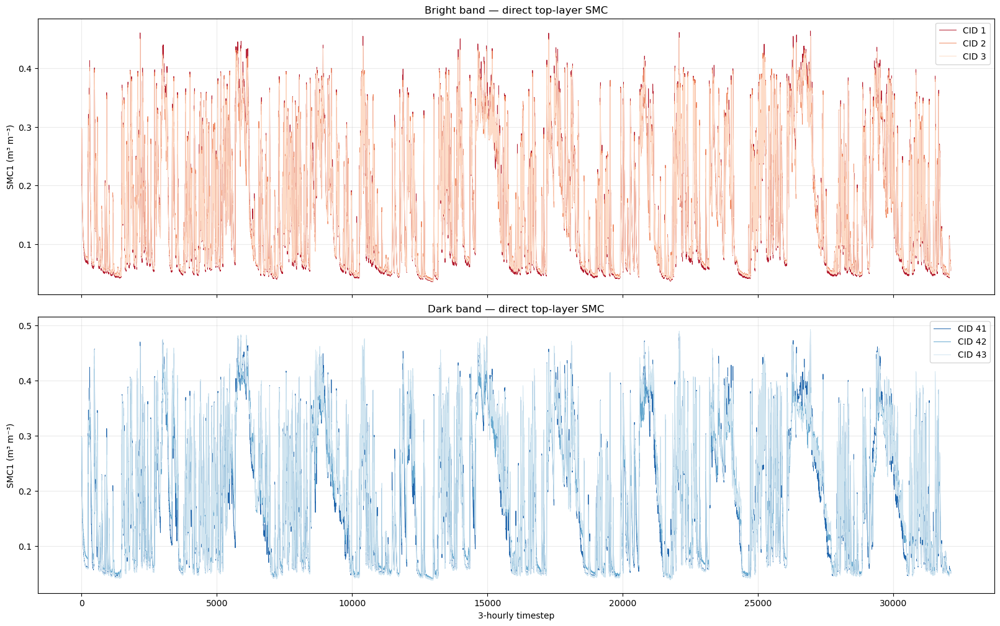

Saved corrected plot: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/direct_cid_comparison/direct_smc1_six_cids_corrected.png


In [7]:
# =====================================================================
# PLOT THE SIX DIRECT SMC1 SERIES USING TIMESTEP INDEX
# =====================================================================

colors = {
    "BRIGHT": ["#b2182b", "#ef8a62", "#fddbc7"],
    "DARK": ["#2166ac", "#67a9cf", "#d1e5f0"]
}

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 10),
    sharex=True,
    constrained_layout=True
)

for axis, (band_name, cids) in zip(axes, cid_groups.items()):

    for index, cid in enumerate(cids):

        if cid not in results:
            continue

        smc1 = results[cid]["smc1"]
        timestep = np.arange(len(smc1))

        axis.plot(
            timestep,
            smc1,
            color=colors[band_name][index],
            linewidth=0.7,
            label=f"CID {cid}"
        )

    axis.set_title(
        f"{band_name.capitalize()} band — direct top-layer SMC"
    )
    axis.set_ylabel("SMC1 (m³ m⁻³)")
    axis.grid(alpha=0.25)
    axis.legend()

axes[-1].set_xlabel("3-hourly timestep")

series_plot_path = os.path.join(
    output_directory,
    "direct_smc1_six_cids_corrected.png"
)

fig.savefig(
    series_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Saved corrected plot: {series_plot_path}")

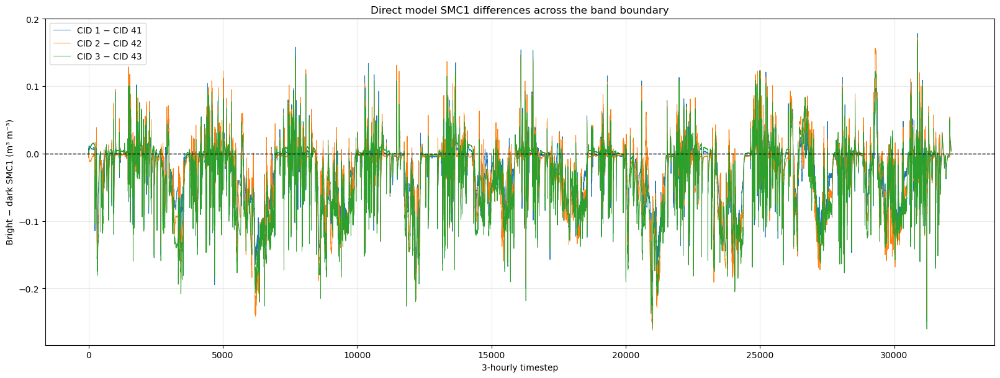

Saved corrected plot: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/direct_cid_comparison/direct_smc1_boundary_differences_corrected.png


In [8]:
# =====================================================================
# PLOT PAIRED DIFFERENCES USING TIMESTEP INDEX
# =====================================================================

fig, axis = plt.subplots(
    figsize=(16, 6),
    constrained_layout=True
)

for bright_cid, dark_cid in zip(bright_cids, dark_cids):

    bright_smc = results[bright_cid]["smc1"]
    dark_smc = results[dark_cid]["smc1"]

    n = min(len(bright_smc), len(dark_smc))

    difference = (
        bright_smc[:n] -
        dark_smc[:n]
    )

    timestep = np.arange(n)

    axis.plot(
        timestep,
        difference,
        linewidth=0.7,
        label=f"CID {bright_cid} − CID {dark_cid}"
    )

axis.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--"
)

axis.set_title(
    "Direct model SMC1 differences across the band boundary"
)
axis.set_xlabel("3-hourly timestep")
axis.set_ylabel("Bright − dark SMC1 (m³ m⁻³)")
axis.grid(alpha=0.25)
axis.legend()

difference_plot_path = os.path.join(
    output_directory,
    "direct_smc1_boundary_differences_corrected.png"
)

fig.savefig(
    difference_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Saved corrected plot: {difference_plot_path}")


CID COORDINATES AND FORCING

CID 1
  HRUs:                   100
  Latitude location:      parameters/lats
  Longitude location:     parameters/lons
  Area-weight location:   parameters/area
  Weighted mean latitude: 34.123381
  Latitude range:         33.992500 to 34.242500
  Weighted mean longitude:-113.875205
  Longitude range:        -113.999168 to -113.764168
  precip  : shape=(32120, 100), mean=4.9579914e-06, min=0, max=0.0016465901
  tair    : shape=(32120, 100), mean=296.05295, min=270.99546, max=319.49675
  swdown  : shape=(32120, 100), mean=242.82825, min=0, max=1007.4082
  lwdown  : shape=(32120, 100), mean=327.18759, min=206.86054, max=472.7882
  psurf   : shape=(32120, 100), mean=95919.998, min=94394.425, max=97794.874
  wind    : shape=(32120, 100), mean=2.6382834, min=0.32393158, max=10.491682
  spfh    : shape=(32120, 100), mean=0.0052469505, min=0.00030495379, max=0.019716122

CID 2
  HRUs:                   100
  Latitude location:      parameters/lats
  Longitude lo

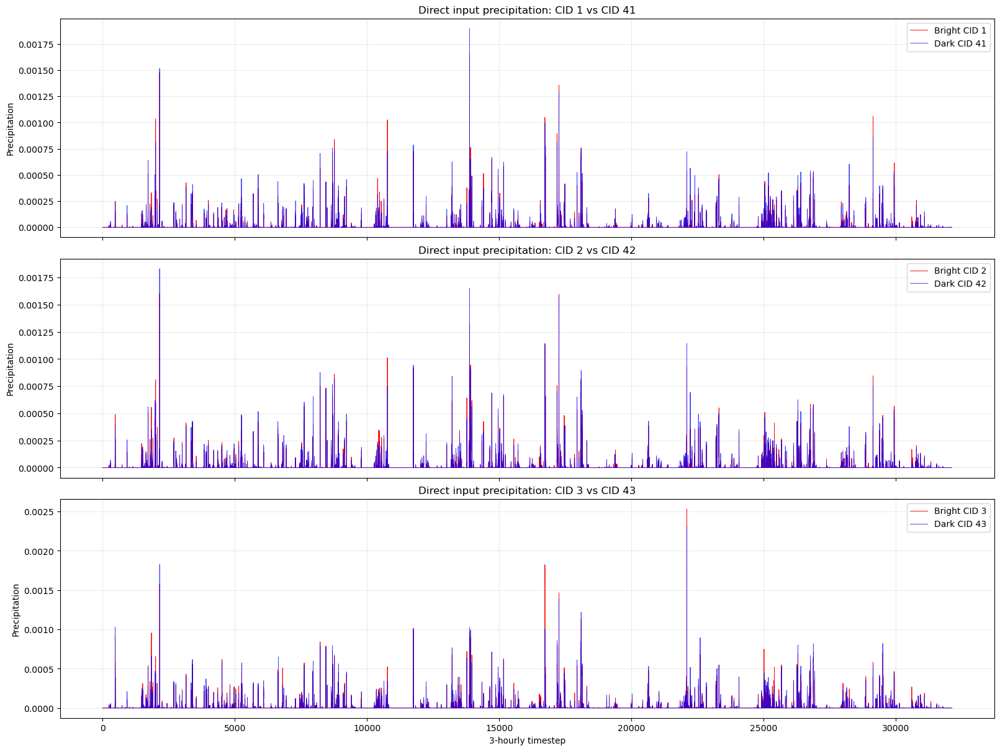


Saved: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/forcing_latitude_check/forcing_precip_pair_comparison.png


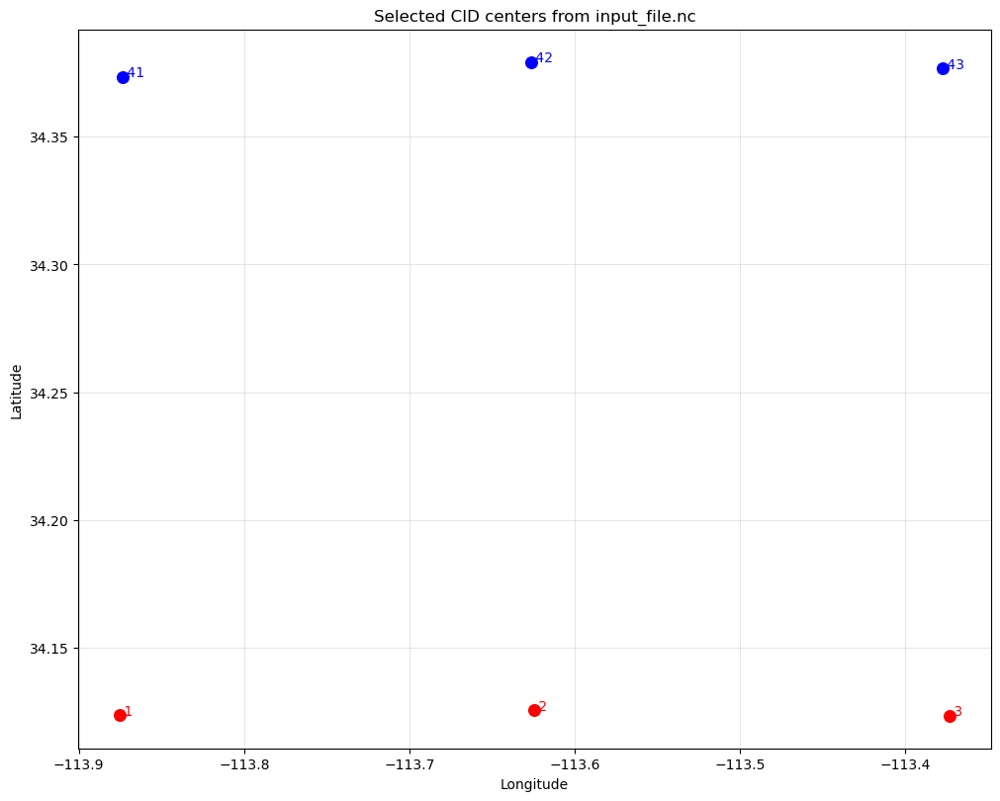

Saved: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/forcing_latitude_check/selected_cid_centers.png


In [1]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt


# =====================================================================
# PATHS AND SELECTED CIDs
# =====================================================================

experiment = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/"
    "experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"
)

bright_cids = [1, 2, 3]
dark_cids = [41, 42, 43]

all_cids = bright_cids + dark_cids

output_directory = os.path.join(
    experiment,
    "forcing_latitude_check"
)

os.makedirs(output_directory, exist_ok=True)


# =====================================================================
# HELPERS
# =====================================================================

def find_variable(ds, name):
    """Search the root and all groups for a variable."""

    if name in ds.variables:
        return ds.variables[name], name

    for group_name, group in ds.groups.items():
        if name in group.variables:
            return group.variables[name], f"{group_name}/{name}"

    return None, None


def clean_array(variable):
    """Convert NetCDF variable to float and replace fill values with NaN."""

    data = np.ma.filled(variable[:], np.nan).astype(float)

    data[~np.isfinite(data)] = np.nan
    data[data <= -9990] = np.nan
    data[data >= 1.0e30] = np.nan

    return data


def time_hru_array(data, nhrus):
    """
    Convert a meteorological variable into shape (time, hru).

    Handles:
        (time, hru)
        (hru, time)
        (time,)
    """

    data = np.squeeze(data)

    if data.ndim == 1:
        return data[:, None]

    if data.ndim != 2:
        raise ValueError(f"Unexpected forcing shape: {data.shape}")

    if data.shape[1] == nhrus:
        return data

    if data.shape[0] == nhrus:
        return data.T

    raise ValueError(
        f"Could not identify HRU axis in shape {data.shape}; "
        f"expected {nhrus} HRUs."
    )


def weighted_mean_series(data, weights):
    """Calculate the HRU-area-weighted mean for every timestep."""

    valid = np.isfinite(data)

    numerator = np.sum(
        np.where(valid, data * weights[None, :], 0.0),
        axis=1
    )

    denominator = np.sum(
        np.where(valid, weights[None, :], 0.0),
        axis=1
    )

    result = np.full(data.shape[0], np.nan)

    good = denominator > 0
    result[good] = numerator[good] / denominator[good]

    return result


# =====================================================================
# READ ONE CID
# =====================================================================

def inspect_input_file(cid):

    filepath = os.path.join(
        experiment,
        str(cid),
        "input_file.nc"
    )

    if not os.path.exists(filepath):
        raise FileNotFoundError(filepath)

    with nc.Dataset(filepath) as ds:

        lat_var, lat_location = find_variable(ds, "lats")
        lon_var, lon_location = find_variable(ds, "lons")

        if lat_var is None or lon_var is None:
            raise KeyError(
                f"Could not find lats/lons in CID {cid}"
            )

        lats = clean_array(lat_var).reshape(-1)
        lons = clean_array(lon_var).reshape(-1)

        nhrus = len(lats)

        area_var, area_location = find_variable(ds, "area")

        if area_var is None:
            area_var, area_location = find_variable(ds, "area_pct")

        if area_var is not None:
            weights = clean_array(area_var).reshape(-1)

            if len(weights) != nhrus:
                weights = np.ones(nhrus)

            weights[~np.isfinite(weights)] = 0.0
            weights[weights < 0] = 0.0

            if np.sum(weights) == 0:
                weights = np.ones(nhrus)

        else:
            weights = np.ones(nhrus)
            area_location = "equal weights"

        weights = weights / np.sum(weights)

        result = {
            "cid": cid,
            "file": filepath,
            "nhrus": nhrus,
            "lats": lats,
            "lons": lons,
            "weights": weights,
            "lat_location": lat_location,
            "lon_location": lon_location,
            "area_location": area_location,
            "mean_lat": np.sum(lats * weights),
            "mean_lon": np.sum(lons * weights),
            "min_lat": np.nanmin(lats),
            "max_lat": np.nanmax(lats),
            "min_lon": np.nanmin(lons),
            "max_lon": np.nanmax(lons),
            "forcing": {}
        }

        forcing_names = [
            "precip",
            "tair",
            "swdown",
            "lwdown",
            "psurf",
            "wind",
            "spfh"
        ]

        for name in forcing_names:

            variable, location = find_variable(ds, name)

            if variable is None:
                print(f"CID {cid}: {name} was not found")
                continue

            raw_data = clean_array(variable)

            try:
                data = time_hru_array(raw_data, nhrus)
            except ValueError as error:
                print(
                    f"CID {cid}: could not process {name}: {error}"
                )
                continue

            mean_series = weighted_mean_series(
                data,
                weights
            )

            result["forcing"][name] = {
                "location": location,
                "shape": variable.shape,
                "data": data,
                "mean_series": mean_series,
                "overall_mean": np.nanmean(mean_series),
                "minimum": np.nanmin(mean_series),
                "maximum": np.nanmax(mean_series)
            }

    return result


# =====================================================================
# READ ALL SIX CIDs
# =====================================================================

results = {}

print("\n" + "=" * 80)
print("CID COORDINATES AND FORCING")
print("=" * 80)

for cid in all_cids:

    try:
        result = inspect_input_file(cid)
        results[cid] = result

        print(f"\nCID {cid}")
        print(f"  HRUs:                   {result['nhrus']}")
        print(f"  Latitude location:      {result['lat_location']}")
        print(f"  Longitude location:     {result['lon_location']}")
        print(f"  Area-weight location:   {result['area_location']}")
        print(f"  Weighted mean latitude: {result['mean_lat']:.6f}")
        print(
            f"  Latitude range:         "
            f"{result['min_lat']:.6f} to "
            f"{result['max_lat']:.6f}"
        )
        print(f"  Weighted mean longitude:{result['mean_lon']:.6f}")
        print(
            f"  Longitude range:        "
            f"{result['min_lon']:.6f} to "
            f"{result['max_lon']:.6f}"
        )

        for name, forcing in result["forcing"].items():
            print(
                f"  {name:8s}: "
                f"shape={forcing['shape']}, "
                f"mean={forcing['overall_mean']:.8g}, "
                f"min={forcing['minimum']:.8g}, "
                f"max={forcing['maximum']:.8g}"
            )

    except Exception as error:
        print(f"\nCID {cid} FAILED: {error}")


# =====================================================================
# CHECK THE SPATIAL RELATIONSHIP BETWEEN PAIRS
# =====================================================================

print("\n" + "=" * 80)
print("COORDINATE DIFFERENCES ACROSS THE BAND")
print("=" * 80)

for bright_cid, dark_cid in zip(bright_cids, dark_cids):

    if bright_cid not in results or dark_cid not in results:
        continue

    bright = results[bright_cid]
    dark = results[dark_cid]

    latitude_difference = (
        dark["mean_lat"] - bright["mean_lat"]
    )

    longitude_difference = (
        dark["mean_lon"] - bright["mean_lon"]
    )

    print(
        f"\nCID {bright_cid} → CID {dark_cid}"
    )
    print(
        f"  Latitude difference:  "
        f"{latitude_difference:+.6f} degrees"
    )
    print(
        f"  Longitude difference: "
        f"{longitude_difference:+.6f} degrees"
    )

    if abs(abs(latitude_difference) - 0.25) < 0.05:
        print(
            "  PASS: The pair is approximately one "
            "0.25-degree latitude row apart."
        )
    else:
        print(
            "  CONCERN: The pair is not approximately "
            "one latitude row apart."
        )

    if abs(longitude_difference) < 0.05:
        print(
            "  PASS: The pair is approximately aligned "
            "in longitude."
        )
    else:
        print(
            "  CONCERN: The pair is not aligned in longitude."
        )


# =====================================================================
# CHECK LATITUDE ORDER WITHIN EACH CID
# =====================================================================

print("\n" + "=" * 80)
print("LATITUDE ORDER INSIDE EACH CID")
print("=" * 80)

for cid, result in results.items():

    lats = result["lats"]

    difference = np.diff(lats)

    increasing_fraction = np.mean(difference > 0)
    decreasing_fraction = np.mean(difference < 0)

    print(f"\nCID {cid}")
    print(f"  First 10 HRU latitudes: {lats[:10]}")
    print(f"  Last 10 HRU latitudes:  {lats[-10:]}")
    print(
        f"  Increasing fraction:    "
        f"{increasing_fraction:.3f}"
    )
    print(
        f"  Decreasing fraction:    "
        f"{decreasing_fraction:.3f}"
    )

    # HRUs are clusters, so strict monotonic ordering is not required.
    # The important check is whether every CID uses the same convention.


# =====================================================================
# COMPARE FORCING ACROSS EACH PAIR
# =====================================================================

print("\n" + "=" * 80)
print("FORCING DIFFERENCES ACROSS THE BAND")
print("=" * 80)

forcing_names = [
    "precip",
    "tair",
    "swdown",
    "lwdown",
    "psurf",
    "wind",
    "spfh"
]

pair_statistics = {}

for bright_cid, dark_cid in zip(bright_cids, dark_cids):

    if bright_cid not in results or dark_cid not in results:
        continue

    bright = results[bright_cid]
    dark = results[dark_cid]

    pair_statistics[(bright_cid, dark_cid)] = {}

    print(
        f"\nPAIR: CID {bright_cid} vs CID {dark_cid}"
    )

    for name in forcing_names:

        if (
            name not in bright["forcing"]
            or name not in dark["forcing"]
        ):
            continue

        bright_series = bright["forcing"][name]["mean_series"]
        dark_series = dark["forcing"][name]["mean_series"]

        n = min(len(bright_series), len(dark_series))

        bright_series = bright_series[:n]
        dark_series = dark_series[:n]

        difference = bright_series - dark_series

        valid = (
            np.isfinite(bright_series)
            & np.isfinite(dark_series)
        )

        if np.sum(valid) > 1:
            correlation = np.corrcoef(
                bright_series[valid],
                dark_series[valid]
            )[0, 1]
        else:
            correlation = np.nan

        mean_bright = np.nanmean(bright_series)
        mean_dark = np.nanmean(dark_series)
        mean_difference = np.nanmean(difference)
        mean_absolute_difference = np.nanmean(
            np.abs(difference)
        )

        pair_statistics[
            (bright_cid, dark_cid)
        ][name] = {
            "bright": bright_series,
            "dark": dark_series,
            "difference": difference
        }

        print(
            f"  {name:8s}: "
            f"bright={mean_bright:.8g}, "
            f"dark={mean_dark:.8g}, "
            f"difference={mean_difference:+.8g}, "
            f"MAE={mean_absolute_difference:.8g}, "
            f"correlation={correlation:.6f}"
        )


# =====================================================================
# TEST FOR EXACTLY REPEATED FORCING
# =====================================================================

print("\n" + "=" * 80)
print("EXACT/NEAR-EXACT FORCING MATCHES")
print("=" * 80)

for name in forcing_names:

    print(f"\n{name.upper()}")

    for i, cid_a in enumerate(all_cids):

        if (
            cid_a not in results
            or name not in results[cid_a]["forcing"]
        ):
            continue

        series_a = results[cid_a]["forcing"][name]["mean_series"]

        for cid_b in all_cids[i + 1:]:

            if (
                cid_b not in results
                or name not in results[cid_b]["forcing"]
            ):
                continue

            series_b = results[cid_b]["forcing"][name]["mean_series"]

            n = min(len(series_a), len(series_b))

            a = series_a[:n]
            b = series_b[:n]

            valid = np.isfinite(a) & np.isfinite(b)

            if not np.any(valid):
                continue

            maximum_difference = np.max(
                np.abs(a[valid] - b[valid])
            )

            if maximum_difference == 0:
                message = "EXACT MATCH"
            elif maximum_difference < 1.0e-10:
                message = "NEAR-EXACT MATCH"
            else:
                message = ""

            if message:
                print(
                    f"  CID {cid_a} and CID {cid_b}: "
                    f"{message}; max difference="
                    f"{maximum_difference:.3e}"
                )


# =====================================================================
# PLOT PRECIPITATION ACROSS THE THREE PAIRS
# =====================================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 12),
    sharex=True,
    constrained_layout=True
)

for axis, (bright_cid, dark_cid) in zip(
    axes,
    zip(bright_cids, dark_cids)
):

    pair = pair_statistics.get(
        (bright_cid, dark_cid),
        {}
    )

    if "precip" not in pair:
        axis.set_title(
            f"Precipitation unavailable for "
            f"CID {bright_cid} and CID {dark_cid}"
        )
        continue

    bright = pair["precip"]["bright"]
    dark = pair["precip"]["dark"]

    n = min(len(bright), len(dark))
    timestep = np.arange(n)

    axis.plot(
        timestep,
        bright[:n],
        color="red",
        linewidth=0.65,
        label=f"Bright CID {bright_cid}"
    )

    axis.plot(
        timestep,
        dark[:n],
        color="blue",
        linewidth=0.65,
        alpha=0.75,
        label=f"Dark CID {dark_cid}"
    )

    axis.set_title(
        f"Direct input precipitation: "
        f"CID {bright_cid} vs CID {dark_cid}"
    )

    axis.set_ylabel("Precipitation")
    axis.grid(alpha=0.25)
    axis.legend()

axes[-1].set_xlabel("3-hourly timestep")

precip_plot = os.path.join(
    output_directory,
    "forcing_precip_pair_comparison.png"
)

fig.savefig(
    precip_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved: {precip_plot}")


# =====================================================================
# PLOT CID CENTERS
# =====================================================================

fig, axis = plt.subplots(
    figsize=(10, 8),
    constrained_layout=True
)

for cid in bright_cids:

    if cid not in results:
        continue

    axis.scatter(
        results[cid]["mean_lon"],
        results[cid]["mean_lat"],
        color="red",
        s=70
    )

    axis.text(
        results[cid]["mean_lon"],
        results[cid]["mean_lat"],
        f" {cid}",
        color="red"
    )

for cid in dark_cids:

    if cid not in results:
        continue

    axis.scatter(
        results[cid]["mean_lon"],
        results[cid]["mean_lat"],
        color="blue",
        s=70
    )

    axis.text(
        results[cid]["mean_lon"],
        results[cid]["mean_lat"],
        f" {cid}",
        color="blue"
    )

axis.set_title("Selected CID centers from input_file.nc")
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
axis.grid(alpha=0.3)

cid_plot = os.path.join(
    output_directory,
    "selected_cid_centers.png"
)

fig.savefig(
    cid_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {cid_plot}")

COMPARING PREPROCESSING AND INPUT_FILE PRECIPITATION
CID    1: pre=4.90515067e-06, input=4.95799138e-06, diff=+5.284e-08, percent=+1.08%, r=0.983974
CID  100: pre=8.64285794e-06, input=7.83888588e-06, diff=-8.040e-07, percent=-9.30%, r=0.957403
CID  200: pre=1.07553483e-05, input=1.07809923e-05, diff=+2.564e-08, percent=+0.24%, r=0.972766
CID  300: pre=9.41696648e-06, input=1.02061674e-05, diff=+7.892e-07, percent=+8.38%, r=0.979038
CID  400: pre=1.22223935e-05, input=1.20022512e-05, diff=-2.201e-07, percent=-1.80%, r=0.977839
CID  500: pre=7.31966383e-06, input=6.82096172e-06, diff=-4.987e-07, percent=-6.81%, r=0.977619
CID  600: pre=1.05112133e-05, input=1.05085976e-05, diff=-2.616e-09, percent=-0.02%, r=0.973815
CID  700: pre=1.01260564e-05, input=1.12865667e-05, diff=+1.161e-06, percent=+11.46%, r=0.984530
CID  800: pre=1.12117931e-05, input=1.12548844e-05, diff=+4.309e-08, percent=+0.38%, r=0.975990
CID  900: pre=9.13486362e-06, input=1.01212622e-05, diff=+9.864e-07, percent=+10.8

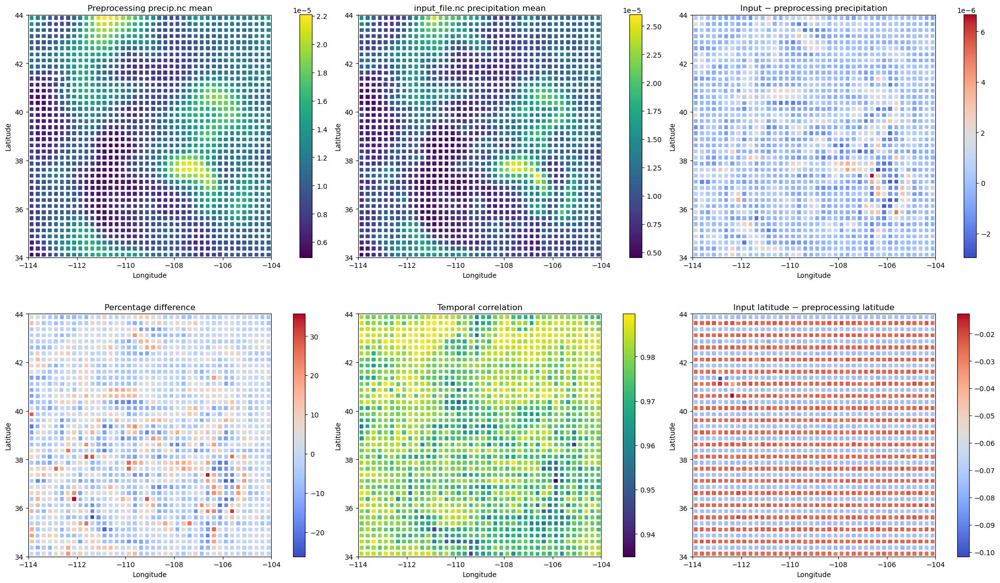

Saved: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test/all_cid_precip_stage_comparison/all_cid_precip_stage_comparison.png

SUMMARY
Successful CIDs: 1600
Failed CIDs:     0
Timestep mismatches: 0
Median temporal correlation: 0.9780825912917532
Minimum temporal correlation: 0.9348719755344452
Median percentage difference: -0.7251397125863746
Maximum absolute percentage difference: 35.738469849002826
Maximum absolute latitude difference: 0.10168338409781796
Maximum absolute longitude difference: 0.0955887576055261

Comparison complete.


In [2]:
import os
import csv
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt


# =====================================================================
# PATHS
# =====================================================================

rdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "Rice_NMT_Snow/upper_colorado"
)

experiment = (
    rdir
    + "/experiments/simulations/"
    + "MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"
)

preprocess_root = os.path.join(rdir, "data", "cids")

output_directory = os.path.join(
    experiment,
    "all_cid_precip_stage_comparison"
)

os.makedirs(output_directory, exist_ok=True)

csv_path = os.path.join(
    output_directory,
    "all_cid_precip_comparison.csv"
)


# =====================================================================
# HELPERS
# =====================================================================

def clean(variable):
    """Read a NetCDF variable and convert fill values to NaN."""

    data = np.ma.filled(variable[:], np.nan).astype(np.float64)

    data[~np.isfinite(data)] = np.nan
    data[data <= -9990] = np.nan
    data[data >= 1.0e30] = np.nan

    return data


def find_variable(dataset, variable_name):
    """Search the root and every first-level group."""

    if variable_name in dataset.variables:
        return dataset.variables[variable_name], variable_name

    for group_name, group in dataset.groups.items():
        if variable_name in group.variables:
            return (
                group.variables[variable_name],
                f"{group_name}/{variable_name}"
            )

    raise KeyError(
        f"Could not find '{variable_name}' in {dataset.filepath()}"
    )


def weighted_time_series(data, weights):
    """
    Calculate an area-weighted mean across HRUs.

    data shape: (time, hru)
    weights shape: (hru,)
    """

    valid = np.isfinite(data)

    numerator = np.sum(
        np.where(
            valid,
            data * weights[np.newaxis, :],
            0.0
        ),
        axis=1
    )

    denominator = np.sum(
        np.where(
            valid,
            weights[np.newaxis, :],
            0.0
        ),
        axis=1
    )

    result = np.full(data.shape[0], np.nan)

    good = denominator > 0

    result[good] = numerator[good] / denominator[good]

    return result


def correlation(a, b):
    """Correlation using only matching finite values."""

    valid = np.isfinite(a) & np.isfinite(b)

    if np.sum(valid) < 2:
        return np.nan

    if (
        np.nanstd(a[valid]) == 0
        or np.nanstd(b[valid]) == 0
    ):
        return np.nan

    return np.corrcoef(
        a[valid],
        b[valid]
    )[0, 1]


# =====================================================================
# READ PREPROCESSING PRECIPITATION
# =====================================================================

def read_preprocess_precip(cid):

    filepath = os.path.join(
        preprocess_root,
        str(cid),
        "precip.nc"
    )

    with nc.Dataset(filepath, "r") as dataset:

        precip = clean(dataset.variables["precip"])
        lat = clean(dataset.variables["lat"]).reshape(-1)
        lon = clean(dataset.variables["lon"]).reshape(-1)
        time = clean(dataset.variables["t"]).reshape(-1)

        # precip should be (time, lat, lon)
        if precip.ndim != 3:
            raise ValueError(
                f"CID {cid}: unexpected preprocessing "
                f"precip shape {precip.shape}"
            )

        # Spatial mean over the 8 × 8 preprocessing grid.
        mean_series = np.nanmean(
            precip,
            axis=(1, 2)
        )

        return {
            "file": filepath,
            "shape": precip.shape,
            "timesteps": precip.shape[0],
            "time": time,
            "series": mean_series,
            "mean_precip": np.nanmean(mean_series),
            "total_precip": np.nansum(mean_series),
            "mean_lat": np.nanmean(lat),
            "mean_lon": np.nanmean(lon),
            "min_lat": np.nanmin(lat),
            "max_lat": np.nanmax(lat),
            "min_lon": np.nanmin(lon),
            "max_lon": np.nanmax(lon)
        }


# =====================================================================
# READ CLUSTERED INPUT_FILE PRECIPITATION
# =====================================================================

def read_clustered_precip(cid):

    filepath = os.path.join(
        experiment,
        str(cid),
        "input_file.nc"
    )

    with nc.Dataset(filepath, "r") as dataset:

        precip_variable, precip_location = find_variable(
            dataset,
            "precip"
        )

        precip = clean(precip_variable)

        lat_variable, lat_location = find_variable(
            dataset,
            "lats"
        )

        lon_variable, lon_location = find_variable(
            dataset,
            "lons"
        )

        lats = clean(lat_variable).reshape(-1)
        lons = clean(lon_variable).reshape(-1)

        number_of_hrus = len(lats)

        # Convert precipitation to (time, HRU).
        precip = np.squeeze(precip)

        if precip.ndim == 1:
            precip = precip[:, np.newaxis]

        elif (
            precip.ndim == 2
            and precip.shape[0] == number_of_hrus
            and precip.shape[1] != number_of_hrus
        ):
            precip = precip.T

        if (
            precip.ndim != 2
            or precip.shape[1] != number_of_hrus
        ):
            raise ValueError(
                f"CID {cid}: unexpected input_file precipitation "
                f"shape {precip.shape}; HRUs={number_of_hrus}"
            )

        # Read HRU area weights.
        try:
            area_variable, area_location = find_variable(
                dataset,
                "area"
            )

        except KeyError:
            area_variable, area_location = find_variable(
                dataset,
                "area_pct"
            )

        weights = clean(area_variable).reshape(-1)

        if len(weights) != number_of_hrus:
            raise ValueError(
                f"CID {cid}: area length {len(weights)} does not "
                f"match HRUs {number_of_hrus}"
            )

        weights[~np.isfinite(weights)] = 0.0
        weights[weights < 0] = 0.0

        if np.sum(weights) <= 0:
            raise ValueError(
                f"CID {cid}: invalid HRU area weights"
            )

        weights = weights / np.sum(weights)

        mean_series = weighted_time_series(
            precip,
            weights
        )

        mean_lat = np.sum(lats * weights)
        mean_lon = np.sum(lons * weights)

        return {
            "file": filepath,
            "shape": precip.shape,
            "timesteps": precip.shape[0],
            "series": mean_series,
            "mean_precip": np.nanmean(mean_series),
            "total_precip": np.nansum(mean_series),
            "mean_lat": mean_lat,
            "mean_lon": mean_lon,
            "min_lat": np.nanmin(lats),
            "max_lat": np.nanmax(lats),
            "min_lon": np.nanmin(lons),
            "max_lon": np.nanmax(lons),
            "precip_location": precip_location,
            "lat_location": lat_location,
            "lon_location": lon_location,
            "area_location": area_location
        }


# =====================================================================
# PROCESS ALL 1,600 CIDs
# =====================================================================

records = []
failed = []

print("=" * 90)
print("COMPARING PREPROCESSING AND INPUT_FILE PRECIPITATION")
print("=" * 90)

for cid in range(1, 1601):

    try:
        pre = read_preprocess_precip(cid)
        clustered = read_clustered_precip(cid)

        n = min(
            pre["timesteps"],
            clustered["timesteps"]
        )

        pre_series = pre["series"][:n]
        clustered_series = clustered["series"][:n]

        difference_series = (
            clustered_series - pre_series
        )

        mean_pre = np.nanmean(pre_series)
        mean_clustered = np.nanmean(clustered_series)

        mean_difference = (
            mean_clustered - mean_pre
        )

        if np.isfinite(mean_pre) and mean_pre != 0:
            percent_difference = (
                100.0 * mean_difference / mean_pre
            )
        else:
            percent_difference = np.nan

        corr = correlation(
            pre_series,
            clustered_series
        )

        mean_absolute_difference = np.nanmean(
            np.abs(difference_series)
        )

        maximum_absolute_difference = np.nanmax(
            np.abs(difference_series)
        )

        latitude_difference = (
            clustered["mean_lat"] - pre["mean_lat"]
        )

        longitude_difference = (
            clustered["mean_lon"] - pre["mean_lon"]
        )

        records.append({
            "cid": cid,
            "pre_timesteps": pre["timesteps"],
            "input_timesteps": clustered["timesteps"],
            "compared_timesteps": n,
            "pre_mean_lat": pre["mean_lat"],
            "pre_mean_lon": pre["mean_lon"],
            "input_mean_lat": clustered["mean_lat"],
            "input_mean_lon": clustered["mean_lon"],
            "latitude_difference": latitude_difference,
            "longitude_difference": longitude_difference,
            "pre_mean_precip": mean_pre,
            "input_mean_precip": mean_clustered,
            "mean_difference": mean_difference,
            "percent_difference": percent_difference,
            "mean_absolute_difference": mean_absolute_difference,
            "maximum_absolute_difference": maximum_absolute_difference,
            "correlation": corr
        })

        if (
            cid == 1
            or cid % 100 == 0
        ):
            print(
                f"CID {cid:4d}: "
                f"pre={mean_pre:.8e}, "
                f"input={mean_clustered:.8e}, "
                f"diff={mean_difference:+.3e}, "
                f"percent={percent_difference:+.2f}%, "
                f"r={corr:.6f}"
            )

    except Exception as error:

        failed.append({
            "cid": cid,
            "error": f"{type(error).__name__}: {error}"
        })

        print(
            f"CID {cid:4d} FAILED: "
            f"{type(error).__name__}: {error}"
        )


# =====================================================================
# SAVE CSV
# =====================================================================

fieldnames = [
    "cid",
    "pre_timesteps",
    "input_timesteps",
    "compared_timesteps",
    "pre_mean_lat",
    "pre_mean_lon",
    "input_mean_lat",
    "input_mean_lon",
    "latitude_difference",
    "longitude_difference",
    "pre_mean_precip",
    "input_mean_precip",
    "mean_difference",
    "percent_difference",
    "mean_absolute_difference",
    "maximum_absolute_difference",
    "correlation"
]

with open(csv_path, "w", newline="") as csv_file:

    writer = csv.DictWriter(
        csv_file,
        fieldnames=fieldnames
    )

    writer.writeheader()
    writer.writerows(records)

print("\nSaved:", csv_path)


failed_path = os.path.join(
    output_directory,
    "failed_cids.csv"
)

with open(failed_path, "w", newline="") as failed_file:

    writer = csv.DictWriter(
        failed_file,
        fieldnames=["cid", "error"]
    )

    writer.writeheader()
    writer.writerows(failed)

print("Saved:", failed_path)


# =====================================================================
# CONVERT RESULTS TO ARRAYS
# =====================================================================

cid_array = np.asarray(
    [record["cid"] for record in records]
)

lat_array = np.asarray(
    [record["input_mean_lat"] for record in records]
)

lon_array = np.asarray(
    [record["input_mean_lon"] for record in records]
)

pre_mean_array = np.asarray(
    [record["pre_mean_precip"] for record in records]
)

input_mean_array = np.asarray(
    [record["input_mean_precip"] for record in records]
)

difference_array = np.asarray(
    [record["mean_difference"] for record in records]
)

percent_array = np.asarray(
    [record["percent_difference"] for record in records]
)

correlation_array = np.asarray(
    [record["correlation"] for record in records]
)

latitude_error_array = np.asarray(
    [record["latitude_difference"] for record in records]
)

longitude_error_array = np.asarray(
    [record["longitude_difference"] for record in records]
)


# =====================================================================
# PLOT SPATIAL MAPS
# =====================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 12),
    constrained_layout=True
)

plots = [
    (
        pre_mean_array,
        "Preprocessing precip.nc mean",
        "viridis"
    ),
    (
        input_mean_array,
        "input_file.nc precipitation mean",
        "viridis"
    ),
    (
        difference_array,
        "Input − preprocessing precipitation",
        "coolwarm"
    ),
    (
        percent_array,
        "Percentage difference",
        "coolwarm"
    ),
    (
        correlation_array,
        "Temporal correlation",
        "viridis"
    ),
    (
        latitude_error_array,
        "Input latitude − preprocessing latitude",
        "coolwarm"
    )
]

for axis, (values, title, cmap) in zip(
    axes.ravel(),
    plots
):

    scatter = axis.scatter(
        lon_array,
        lat_array,
        c=values,
        s=22,
        marker="s",
        cmap=cmap
    )

    axis.set_title(title)
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.set_xlim(-114, -104)
    axis.set_ylim(34, 44)
    axis.set_aspect("equal", adjustable="box")

    plt.colorbar(
        scatter,
        ax=axis,
        shrink=0.85
    )

diagnostic_map_path = os.path.join(
    output_directory,
    "all_cid_precip_stage_comparison.png"
)

fig.savefig(
    diagnostic_map_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", diagnostic_map_path)


# =====================================================================
# SUMMARY
# =====================================================================

print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)

print(f"Successful CIDs: {len(records)}")
print(f"Failed CIDs:     {len(failed)}")

if records:

    print(
        "Timestep mismatches:",
        np.sum(
            np.asarray(
                [r["pre_timesteps"] for r in records]
            )
            !=
            np.asarray(
                [r["input_timesteps"] for r in records]
            )
        )
    )

    print(
        "Median temporal correlation:",
        np.nanmedian(correlation_array)
    )

    print(
        "Minimum temporal correlation:",
        np.nanmin(correlation_array)
    )

    print(
        "Median percentage difference:",
        np.nanmedian(percent_array)
    )

    print(
        "Maximum absolute percentage difference:",
        np.nanmax(np.abs(percent_array))
    )

    print(
        "Maximum absolute latitude difference:",
        np.nanmax(np.abs(latitude_error_array))
    )

    print(
        "Maximum absolute longitude difference:",
        np.nanmax(np.abs(longitude_error_array))
    )

print("\nComparison complete.")

In [3]:
import os
import csv
from datetime import datetime, timedelta

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt


# =====================================================================
# PATHS
# =====================================================================

rdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "Rice_NMT_Snow/upper_colorado"
)

experiment = os.path.join(
    rdir,
    "experiments",
    "simulations",
    "MSWX_3h_Snow_Project3_pp_upper_colorado_11yrs_100hru_100bh_test"
)

output_directory = os.path.join(
    experiment,
    "winter2014_cid_forcing_smc_comparison"
)

os.makedirs(output_directory, exist_ok=True)

dt_seconds = 10800.0  # 3 hours


# =====================================================================
# BASIC HELPERS
# =====================================================================

def find_variable(dataset, name):
    """Search the root and all first-level NetCDF groups."""

    if name in dataset.variables:
        return dataset.variables[name], name

    for group_name, group in dataset.groups.items():
        if name in group.variables:
            return (
                group.variables[name],
                f"{group_name}/{name}"
            )

    raise KeyError(
        f"Could not find {name!r} in {dataset.filepath()}"
    )


def clean(variable, key=None):
    """
    Read a NetCDF variable as float64 and replace fill values with NaN.

    key allows reading only selected timesteps/layers.
    """

    if key is None:
        values = variable[:]
    else:
        values = variable[key]

    data = np.ma.filled(values, np.nan).astype(np.float64)

    data[~np.isfinite(data)] = np.nan
    data[data <= -9990] = np.nan
    data[data >= 1.0e30] = np.nan

    return data


def read_weights(dataset, number_of_hrus):
    """Read and normalize HRU area weights."""

    try:
        area_variable, area_location = find_variable(
            dataset,
            "area"
        )
    except KeyError:
        area_variable, area_location = find_variable(
            dataset,
            "area_pct"
        )

    weights = clean(area_variable).reshape(-1)

    if len(weights) != number_of_hrus:
        raise ValueError(
            f"Area length {len(weights)} does not match "
            f"HRU count {number_of_hrus}"
        )

    valid = np.isfinite(weights) & (weights > 0)

    weights[~valid] = 0.0

    if np.sum(weights) <= 0:
        raise ValueError("No valid positive HRU area weights")

    weights /= np.sum(weights)

    return weights, area_location


def weighted_mean_2d(data, weights):
    """
    Area-weighted mean across HRUs.

    data must have shape (time, HRU).
    Returns one value per timestep.
    """

    valid = np.isfinite(data)

    numerator = np.sum(
        np.where(
            valid,
            data * weights[np.newaxis, :],
            0.0
        ),
        axis=1
    )

    denominator = np.sum(
        np.where(
            valid,
            weights[np.newaxis, :],
            0.0
        ),
        axis=1
    )

    result = np.full(data.shape[0], np.nan)

    good = denominator > 0
    result[good] = numerator[good] / denominator[good]

    return result


def spatial_correlation(a, b):
    """Pearson correlation between two spatial arrays."""

    a = np.asarray(a, dtype=float).reshape(-1)
    b = np.asarray(b, dtype=float).reshape(-1)

    valid = np.isfinite(a) & np.isfinite(b)

    if np.sum(valid) < 3:
        return np.nan

    if (
        np.std(a[valid]) == 0
        or np.std(b[valid]) == 0
    ):
        return np.nan

    return np.corrcoef(
        a[valid],
        b[valid]
    )[0, 1]


# =====================================================================
# DEFINE WINTER 2014 TIMESTEPS
#
# Winter 2014 here means:
#     January 1–February 28, 2014
#     December 1–December 31, 2014
#
# This matches the 90-day winter convention used in your map.
# =====================================================================

reference_precip_file = os.path.join(
    rdir,
    "data",
    "cids",
    "1",
    "precip.nc"
)

with nc.Dataset(reference_precip_file, "r") as dataset:

    time_variable = dataset.variables["t"]
    raw_time = np.asarray(time_variable[:])

    time_units = getattr(
        time_variable,
        "units",
        "3hr since 2014-01-01 00:00:00.0"
    )

    time_calendar = getattr(
        time_variable,
        "calendar",
        "standard"
    )

    try:
        decoded_time = nc.num2date(
            raw_time,
            units=time_units,
            calendar=time_calendar,
            only_use_cftime_datetimes=False,
            only_use_python_datetimes=True
        )

        decoded_time = np.asarray(decoded_time)

    except Exception as error:

        print("NetCDF time decoding failed:", error)
        print("Using 3-hourly dates beginning 2014-01-01.")

        decoded_time = np.asarray([
            datetime(2014, 1, 1)
            + timedelta(seconds=index * dt_seconds)
            for index in range(len(raw_time))
        ])


winter_mask = np.asarray([
    (
        date.year == 2014
        and date.month in (12, 1, 2)
    )
    for date in decoded_time
])

winter_indices = np.where(winter_mask)[0]

print("=" * 80)
print("WINTER 2014 TIME SELECTION")
print("=" * 80)
print("Selected timesteps:", len(winter_indices))
print("Expected timesteps:", 90 * 8)
print("First selected date:", decoded_time[winter_indices[0]])
print("Last selected date: ", decoded_time[winter_indices[-1]])

if len(winter_indices) != 720:
    print(
        "WARNING: Winter 2014 does not contain exactly "
        "720 three-hourly timesteps."
    )


# =====================================================================
# READ ONE CID
# =====================================================================

def read_cid_winter2014(cid):

    input_file = os.path.join(
        experiment,
        str(cid),
        "input_file.nc"
    )

    output_file = os.path.join(
        experiment,
        "output_data",
        str(cid),
        "2014-01-01.nc"
    )

    if not os.path.exists(input_file):
        raise FileNotFoundError(input_file)

    if not os.path.exists(output_file):
        raise FileNotFoundError(output_file)

    # -----------------------------------------------------------------
    # INPUT METEOROLOGY
    # -----------------------------------------------------------------

    with nc.Dataset(input_file, "r") as dataset:

        precip_variable, precip_location = find_variable(
            dataset,
            "precip"
        )

        tair_variable, tair_location = find_variable(
            dataset,
            "tair"
        )

        lat_variable, lat_location = find_variable(
            dataset,
            "lats"
        )

        lon_variable, lon_location = find_variable(
            dataset,
            "lons"
        )

        lats = clean(lat_variable).reshape(-1)
        lons = clean(lon_variable).reshape(-1)

        number_of_hrus = len(lats)

        weights, weight_location = read_weights(
            dataset,
            number_of_hrus
        )

        # Expected shapes: (time, HRU)
        precip = clean(
            precip_variable,
            key=(winter_indices, slice(None))
        )

        tair = clean(
            tair_variable,
            key=(winter_indices, slice(None))
        )

        if precip.ndim == 1:
            precip = precip[:, np.newaxis]

        if tair.ndim == 1:
            tair = tair[:, np.newaxis]

        # Handle HRU × time orientation if encountered.
        if (
            precip.ndim == 2
            and precip.shape[0] == number_of_hrus
            and precip.shape[1] != number_of_hrus
        ):
            precip = precip.T

        if (
            tair.ndim == 2
            and tair.shape[0] == number_of_hrus
            and tair.shape[1] != number_of_hrus
        ):
            tair = tair.T

        if precip.shape[1] != number_of_hrus:
            raise ValueError(
                f"CID {cid}: precipitation shape "
                f"{precip.shape} does not match "
                f"{number_of_hrus} HRUs"
            )

        if tair.shape[1] != number_of_hrus:
            raise ValueError(
                f"CID {cid}: temperature shape "
                f"{tair.shape} does not match "
                f"{number_of_hrus} HRUs"
            )

        precip_series = weighted_mean_2d(
            precip,
            weights
        )

        tair_series = weighted_mean_2d(
            tair,
            weights
        )

        # Precipitation is kg m-2 s-1, equivalent to mm s-1.
        # Multiplying by 10,800 seconds gives millimeters
        # accumulated during each 3-hour timestep.
        winter_precip_mm = np.nansum(
            precip_series * dt_seconds
        )

        winter_tair_k = np.nanmean(tair_series)
        winter_tair_c = winter_tair_k - 273.15

        mean_lat = np.sum(lats * weights)
        mean_lon = np.sum(lons * weights)

    # -----------------------------------------------------------------
    # DIRECT MODEL SMC
    # -----------------------------------------------------------------

    with nc.Dataset(output_file, "r") as dataset:

        smc_variable, smc_location = find_variable(
            dataset,
            "smc"
        )

        # HydroBlocks output shape:
        # (time, HRU, soil layer)
        smc_top = clean(
            smc_variable,
            key=(winter_indices, slice(None), 0)
        )

        if smc_top.ndim == 1:
            smc_top = smc_top[:, np.newaxis]

        if smc_top.shape[1] != number_of_hrus:
            raise ValueError(
                f"CID {cid}: SMC shape {smc_top.shape} "
                f"does not match {number_of_hrus} input HRUs"
            )

        smc_series = weighted_mean_2d(
            smc_top,
            weights
        )

        winter_smc = np.nanmean(smc_series)

    return {
        "cid": cid,
        "longitude": mean_lon,
        "latitude": mean_lat,
        "winter_precip_mm": winter_precip_mm,
        "winter_tair_c": winter_tair_c,
        "winter_smc": winter_smc,
        "number_of_hrus": number_of_hrus,
        "precip_location": precip_location,
        "tair_location": tair_location,
        "smc_location": smc_location,
        "weight_location": weight_location
    }


# =====================================================================
# PROCESS ALL 1,600 CIDs
# =====================================================================

records = []
failed = []

print("\n" + "=" * 80)
print("READING WINTER 2014 FORCING AND DIRECT SMC")
print("=" * 80)

for cid in range(1, 1601):

    try:

        record = read_cid_winter2014(cid)
        records.append(record)

        if cid == 1 or cid % 50 == 0:
            print(
                f"CID {cid:4d}: "
                f"P={record['winter_precip_mm']:.2f} mm, "
                f"T={record['winter_tair_c']:.2f} °C, "
                f"SMC={record['winter_smc']:.4f}"
            )

    except Exception as error:

        failed.append({
            "cid": cid,
            "error": f"{type(error).__name__}: {error}"
        })

        print(
            f"CID {cid:4d} FAILED: "
            f"{type(error).__name__}: {error}"
        )


# =====================================================================
# SAVE RESULTS
# =====================================================================

csv_path = os.path.join(
    output_directory,
    "winter2014_cid_forcing_smc.csv"
)

fieldnames = [
    "cid",
    "longitude",
    "latitude",
    "winter_precip_mm",
    "winter_tair_c",
    "winter_smc",
    "number_of_hrus",
    "precip_location",
    "tair_location",
    "smc_location",
    "weight_location"
]

with open(csv_path, "w", newline="") as file:

    writer = csv.DictWriter(
        file,
        fieldnames=fieldnames
    )

    writer.writeheader()
    writer.writerows(records)

failed_path = os.path.join(
    output_directory,
    "failed_cids.csv"
)

with open(failed_path, "w", newline="") as file:

    writer = csv.DictWriter(
        file,
        fieldnames=["cid", "error"]
    )

    writer.writeheader()
    writer.writerows(failed)

print("\nSaved:", csv_path)
print("Saved:", failed_path)


# =====================================================================
# ARRAYS
# =====================================================================

cids = np.asarray([
    record["cid"] for record in records
])

longitudes = np.asarray([
    record["longitude"] for record in records
])

latitudes = np.asarray([
    record["latitude"] for record in records
])

precipitation = np.asarray([
    record["winter_precip_mm"] for record in records
])

temperature = np.asarray([
    record["winter_tair_c"] for record in records
])

smc = np.asarray([
    record["winter_smc"] for record in records
])


# =====================================================================
# PUT DATA INTO THE EXACT 40 × 40 CID GRID
#
# CID numbering:
#   CIDs 1–40:      first latitude row
#   CIDs 41–80:     second latitude row
#   ...
#   CIDs 1561–1600: final latitude row
# =====================================================================

precip_grid = np.full((40, 40), np.nan)
temperature_grid = np.full((40, 40), np.nan)
smc_grid = np.full((40, 40), np.nan)

for record in records:

    cid = record["cid"]

    row = (cid - 1) // 40
    column = (cid - 1) % 40

    precip_grid[row, column] = record["winter_precip_mm"]
    temperature_grid[row, column] = record["winter_tair_c"]
    smc_grid[row, column] = record["winter_smc"]


# =====================================================================
# MAPS ON IDENTICAL GRID
# =====================================================================

extent = [-114, -104, 34, 44]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 7),
    constrained_layout=True
)

plots = [
    (
        precip_grid,
        "Winter 2014 precipitation",
        "Blues",
        "Precipitation (mm)"
    ),
    (
        temperature_grid,
        "Winter 2014 air temperature",
        "coolwarm",
        "Temperature (°C)"
    ),
    (
        smc_grid,
        "Winter 2014 top-layer SMC",
        "viridis",
        "SMC (m³ m⁻³)"
    )
]

for axis, (data, title, cmap, label) in zip(
    axes,
    plots
):

    image = axis.imshow(
        data,
        origin="lower",
        extent=extent,
        interpolation="nearest",
        cmap=cmap,
        aspect="equal"
    )

    axis.set_title(title)
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")

    colorbar = fig.colorbar(
        image,
        ax=axis,
        shrink=0.86
    )

    colorbar.set_label(label)

comparison_path = os.path.join(
    output_directory,
    "winter2014_precip_tair_smc_same_cid_grid.png"
)

fig.savefig(
    comparison_path,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print("Saved:", comparison_path)


# =====================================================================
# ROW-MEAN DIAGNOSTIC
#
# Strong common peaks or jumps in the same rows would demonstrate
# forcing-grid imprinting in SMC.
# =====================================================================

precip_row_mean = np.nanmean(precip_grid, axis=1)
temperature_row_mean = np.nanmean(
    temperature_grid,
    axis=1
)
smc_row_mean = np.nanmean(smc_grid, axis=1)

row_latitude = np.linspace(
    34.125,
    43.875,
    40
)

# Standardize to compare patterns despite different units.
def standardize(values):

    values = np.asarray(values, dtype=float)

    return (
        values - np.nanmean(values)
    ) / np.nanstd(values)


fig, axis = plt.subplots(
    figsize=(14, 7),
    constrained_layout=True
)

axis.plot(
    row_latitude,
    standardize(precip_row_mean),
    marker="o",
    linewidth=1.5,
    label="Precipitation"
)

axis.plot(
    row_latitude,
    -standardize(temperature_row_mean),
    marker="o",
    linewidth=1.5,
    label="Negative temperature"
)

axis.plot(
    row_latitude,
    standardize(smc_row_mean),
    marker="o",
    linewidth=2.0,
    label="SMC"
)

axis.axhline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

axis.set_title(
    "Winter 2014 standardized CID-row means"
)
axis.set_xlabel("Latitude")
axis.set_ylabel("Standardized value")
axis.grid(alpha=0.3)
axis.legend()

row_plot_path = os.path.join(
    output_directory,
    "winter2014_row_mean_comparison.png"
)

fig.savefig(
    row_plot_path,
    dpi=220,
    bbox_inches="tight"
)

plt.show()

print("Saved:", row_plot_path)


# =====================================================================
# CORRELATIONS AND ADJACENT-ROW JUMPS
# =====================================================================

precip_smc_correlation = spatial_correlation(
    precipitation,
    smc
)

temperature_smc_correlation = spatial_correlation(
    temperature,
    smc
)

coldness_smc_correlation = spatial_correlation(
    -temperature,
    smc
)

row_precip_smc_correlation = spatial_correlation(
    precip_row_mean,
    smc_row_mean
)

row_temperature_smc_correlation = spatial_correlation(
    temperature_row_mean,
    smc_row_mean
)

row_coldness_smc_correlation = spatial_correlation(
    -temperature_row_mean,
    smc_row_mean
)

precip_row_jumps = np.diff(precip_row_mean)
temperature_row_jumps = np.diff(temperature_row_mean)
smc_row_jumps = np.diff(smc_row_mean)

precip_jump_smc_jump_correlation = spatial_correlation(
    precip_row_jumps,
    smc_row_jumps
)

cold_jump_smc_jump_correlation = spatial_correlation(
    -temperature_row_jumps,
    smc_row_jumps
)

print("\n" + "=" * 80)
print("WINTER 2014 DIAGNOSTIC SUMMARY")
print("=" * 80)

print(f"Successful CIDs: {len(records)}")
print(f"Failed CIDs:     {len(failed)}")

print("\nAll 1,600 CID spatial correlations:")
print(
    f"  Precipitation vs SMC: "
    f"{precip_smc_correlation:.6f}"
)
print(
    f"  Temperature vs SMC:   "
    f"{temperature_smc_correlation:.6f}"
)
print(
    f"  Coldness vs SMC:      "
    f"{coldness_smc_correlation:.6f}"
)

print("\nCorrelations between 40 latitude-row means:")
print(
    f"  Precipitation vs SMC: "
    f"{row_precip_smc_correlation:.6f}"
)
print(
    f"  Temperature vs SMC:   "
    f"{row_temperature_smc_correlation:.6f}"
)
print(
    f"  Coldness vs SMC:      "
    f"{row_coldness_smc_correlation:.6f}"
)

print("\nCorrelations between adjacent-row jumps:")
print(
    f"  Precipitation jump vs SMC jump: "
    f"{precip_jump_smc_jump_correlation:.6f}"
)
print(
    f"  Coldness jump vs SMC jump:      "
    f"{cold_jump_smc_jump_correlation:.6f}"
)

print("\nComparison complete.")

NetCDF time decoding failed: units must be one of 'seconds', 'minutes', 'hours' or 'days' (or singular version of these), got '3hr'
Using 3-hourly dates beginning 2014-01-01.
WINTER 2014 TIME SELECTION
Selected timesteps: 720
Expected timesteps: 720
First selected date: 2014-01-01 00:00:00
Last selected date:  2014-12-31 21:00:00

READING WINTER 2014 FORCING AND DIRECT SMC
CID    1: P=19.21 mm, T=13.93 °C, SMC=0.1511
CID   50: P=78.17 mm, T=8.55 °C, SMC=0.1767
CID  100: P=35.92 mm, T=4.07 °C, SMC=0.1905
CID  150: P=19.79 mm, T=4.29 °C, SMC=0.1131
CID  200: P=15.34 mm, T=5.12 °C, SMC=0.2104
CID  250: P=47.53 mm, T=3.42 °C, SMC=0.1861
CID  300: P=58.80 mm, T=0.44 °C, SMC=0.1529
CID  350: P=80.42 mm, T=-1.31 °C, SMC=0.2221
CID  400: P=26.95 mm, T=0.76 °C, SMC=0.1346
CID  450: P=31.72 mm, T=4.47 °C, SMC=0.1168
CID  500: P=38.46 mm, T=3.28 °C, SMC=0.3343
CID  550: P=136.73 mm, T=-7.76 °C, SMC=0.2399
CID  600: P=42.55 mm, T=1.02 °C, SMC=0.1619
CID  650: P=68.95 mm, T=-4.69 °C, SMC=0.3945
CID

In [3]:
import netCDF4 as nc
import glob

edir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_100hru_full_domain_downscaled"

glacier_cids = []
for f in glob.glob(f"{edir}/*/input_file.nc"):
    try:
        fp = nc.Dataset(f)
        lc = fp.groups['parameters'].variables['lc'][:]
        # NoahMP/MODIS IGBP glacier/ice class is typically value 15
        if (lc == 15).any():
            glacier_cids.append(f)
        fp.close()
    except Exception:
        continue

print(f"Found {len(glacier_cids)} CIDs with glacier land cover")
print(glacier_cids[:10])

Found 0 CIDs with glacier land cover
[]


In [4]:
import netCDF4 as nc

edir = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_100hru_full_domain_downscaled"

for cid in [1504, 224, 478, 1546]:
    fp = nc.Dataset(f"{edir}/{cid}/input_file.nc")
    lc = fp.groups['parameters'].variables['lc'][:]
    dem = fp.groups['parameters'].variables['dem'][:]
    print(f"CID {cid}: land cover classes present = {sorted(set(lc.astype(int)))}, "
          f"elevation range = {dem.min():.0f}-{dem.max():.0f} m")
    fp.close()

KeyError: 'lc'